# ZShooter Science Validation

This notebook is the release-facing validation path for the ZShooter ScopeSim model. It is meant to answer science and instrument-engineering questions directly: what is configured, what physical effects are included, what the dominant rates are, whether simple back-of-the-envelope scales agree, and what changes when common background/AO/source knobs are toggled.

The older `zshooter_validation.ipynb` remains useful as a developer lab notebook. This notebook intentionally keeps the important knobs close to the calculations they control, and it leaves the code visible so a scientist can rerun the same reasoning with different source, slit, seeing, airmass, or background settings.

In [1]:
%matplotlib inline
from collections import OrderedDict
from contextlib import contextmanager
from math import erf
import logging
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp


In [2]:
from zs_scopesim_tools.helpers import configure_path_and_logging, disable_scopesim_progress_bars, disable_scopesim_top_level_catch, validation_work_dir, warning_prevent_sync_alt_ra_dec, zshooter_package_dir, ignore_warnings
from zs_scopesim_tools.sources import angle_from_cmds, constant_photon_flux_flat, field_angle_demo_sources, lamp_flat
from zs_scopesim_tools.plots import plot_detector_background_budget, plot_detector_image_grid, plot_emissivity_sanity, plot_post_disperser_diffuse_background, plot_readout_cross_dispersion_cut, plot_readout_overview, plot_resolving_power_echellogram, plot_slit_adc_psf_scenes, plot_slit_loss_by_arm, plot_slit_width_loss, plot_source, plot_transmission_sanity, show_and_save_hdul
from zs_scopesim_tools.validation import build_emissivity_sanity_data, build_post_disperser_diffuse_background_data, build_slit_adc_psf_scene_data, build_slit_loss_data, build_slit_width_loss_data, build_transmission_sanity_data, detector_background_budget_table, detector_geometry_table, detector_qe_accounting_table, detector_selector_matrix, effect_name, fetch_effect_spectrum_or_transmission, fov_image_plane_counts, get_effect, post_disperser_diffuse_effect_consistency_table, readout_delta_summary_table, science_truth_crosscheck_table, slit_adc_psf_status_table, slit_pair_status_table, source_position_table, trace_catalog_table, trace_resolution_diagnostic_table, trace_resolution_summary_display_table, trace_resolution_summary_table, validate_emissivity_sanity_data, validate_post_disperser_diffuse_background_data, validate_post_disperser_diffuse_effect_consistency, validate_transmission_sanity_data
ignore_warnings()

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="warning")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path, name="science_validation_outputs")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

from skycalc_ipy.core import SkyModel, get_cache_dir
SkyModel.REQUEST_TIMEOUT = 60
# print(f"SkyCalc timeout: {SkyModel.REQUEST_TIMEOUT}s; cache: {get_cache_dir()}")

cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

def set_channel_exposure(cmds, *, dit, ndit):
    cmds["!OBS.dit"] = dit
    cmds["!OBS.ndit"] = ndit
    for channel in ("blue", "green", "red", "yj", "h", "k"):
        cmds[f"!OBS.dit_{channel}"] = dit
        cmds[f"!OBS.ndit_{channel}"] = ndit

validation_brightness = "grey"

cmd["!OBS.airmass"] = 1.1
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = "grey"
cmd["!OBS.pupil_angle"] = 0.0
set_channel_exposure(cmd, dit=1800, ndit=2)
cmd["!INST.vis_curr_slit"] = 0.7 # 0.33
cmd["!INST.nir_curr_slit"] = 0.7 # 0.33
cmd["!INST.include_diffuse_emmisivity"] = False

warning_prevent_sync_alt_ra_dec(cmd)

component_metadata = {"telescope_reflection": {"throughput_group": "telescope", "emission_phase": "pre_disperser"},
                      "ir_blocking_filter_selector": {"throughput_group": "ir_blocking_filter"},
                      }

zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")

astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

Validation outputs: 

In [4]:
def cmd_value(key):
    try:
        return from_currsys(key, cmd)
    except Exception:
        return None

def train_cmd_value(key):
    try:
        return from_currsys(key, zs.cmds)
    except Exception:
        return None


def display_frame(data, *, columns=None, rename=None, formats=None):
    if isinstance(data, Table):
        view = data[columns] if columns is not None else data
        frame = view.to_pandas()
    else:
        frame = pd.DataFrame(data)
        if columns is not None:
            frame = frame.loc[:, columns]
    if rename:
        frame = frame.rename(columns=rename)
    styler = frame.style.hide(axis="index")
    if formats:
        active_formats = {key: value for key, value in formats.items() if key in frame.columns}
        styler = styler.format(active_formats, na_rep="--")
    display(styler)


def compact_range(minimum, maximum, digits=1):
    if not np.isfinite(minimum) or not np.isfinite(maximum):
        return "--"
    if np.isclose(minimum, maximum, rtol=1e-4, atol=10**-digits):
        return f"{minimum:.{digits}f}"
    return f"{minimum:.{digits}f}-{maximum:.{digits}f}"

run_card = Table(rows=[
    {"quantity": "instrument", "value": "ZShooter_v2 SPEC", "why_it_matters": "loads the release IRDB model"},
    {"quantity": "airmass", "value": cmd_value("!OBS.airmass"), "why_it_matters": "sets atmospheric path, dispersion, and sky"},
    {"quantity": "altitude [deg]", "value": cmd_value("!OBS.alt"), "why_it_matters": "derived from airmass for ScopeSim AltAz context"},
    {"quantity": "RA/Dec", "value": f"{cmd_value('!OBS.ra')}/{cmd_value('!OBS.dec')}", "why_it_matters": "cleared so they do not override airmass"},
    {"quantity": "seeing [arcsec]", "value": cmd_value("!OBS.seeing"), "why_it_matters": "natural-seeing PSF scale"},
    {"quantity": "sky brightness", "value": cmd_value("!OBS.brightness"), "why_it_matters": "SkyCalc continuum/line brightness preset"},
    {"quantity": "command telescope area", "value": cmd_value("!TEL.area"), "why_it_matters": "pre-train default; should be replaced by optical-train derived area"},
    {"quantity": "train telescope area", "value": train_cmd_value("!TEL.area"), "why_it_matters": "derived from the active Keck mirror SurfaceList and used by FOV/source scaling"},
    {"quantity": "VIS slit [arcsec]", "value": cmd_value("!INST.vis_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "NIR slit [arcsec]", "value": cmd_value("!INST.nir_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "spectral resolving power guardrail", "value": cmd_value("!SIM.spectral.spectral_resolution"), "why_it_matters": "internal spectral work grid / sky sampling guardrail"},
    {"quantity": "DIT x NDIT", "value": f"{cmd_value('!OBS.dit_green')} x {cmd_value('!OBS.ndit_green')}", "why_it_matters": "per-channel detector exposure; total is DIT*NDIT"},
    {"quantity": "pupil angle [deg]", "value": cmd_value("!OBS.pupil_angle"), "why_it_matters": "source-pair orientation used below"},
])
display_frame(run_card, rename={"why_it_matters": "why it matters"})

# print("Trace catalog")
# trace_catalog = trace_catalog_table(get_effect(zs, "trace_list_analytical"))
# display_frame(
#     trace_catalog,
#     columns=["trace_id", "aperture_id", "image_plane_id", "wave_min_um", "wave_max_um"],
#     rename={
#         "trace_id": "trace",
#         "aperture_id": "aperture id",
#         "image_plane_id": "image plane id",
#         "wave_min_um": "wave min [um]",
#         "wave_max_um": "wave max [um]",
#     },
#     formats={"wave min [um]": "{:.4f}", "wave max [um]": "{:.4f}"},
# )
print("FoV image-plane counts")
display_frame(fov_image_plane_counts(zs), rename={"image_plane_id": "image plane id", "n_fovs": "FoVs"})


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area
train telescope area,76.52965998654079 m2,derived from the active Keck mirror SurfaceList and used by FOV/source scaling
VIS slit [arcsec],0.700000,source throughput and resolution
NIR slit [arcsec],0.700000,source throughput and resolution


FoV image-plane counts


image plane id,FoVs
0,35
1,31
2,21
3,24
4,12
5,7


## Trace Geometry And Resolution Scale

This detector-facing diagnostic samples the loaded spectral traces on the active image planes. The table gives compact channel ranges; the first map shows local resolving power from the trace geometry and detector pixel scale, while the second map shows the corresponding spectral-element sampling width. Blank pixels are off trace. The plotted samples are kept only where the sampled slit footprint is fully on detector; the trace catalog below is the check for the total loaded order count. Detector rotation is part of the trace geometry being checked; `detector_pad` is legacy metadata and is not applied to the optical trace geometry.

,ch,id,orders,wave nm,slit,spec FWHM pix,disp nm/pix,R k,resel pix,seeing
0,B,0,35,306-437,"0.70""",4.46,0.0032-0.0064,15.0-21.9,20.1-21.6,"0.73""/4.7 pix"
1,G,1,31,424-668,"0.70""",4.46,0.0045-0.0096,15.1-21.6,18.4-20.2,"0.68""/4.3 pix"
2,R,2,21,644-1021,"0.70""",4.46,0.0069-0.0147,15.1-21.6,16.9-18.6,"0.63""/4.0 pix"
3,YJ,3,24,937-1346,"0.70""",4.46,0.0104-0.0190,15.5-20.9,16.0-17.2,"0.59""/3.7 pix"
4,H,4,12,1471-1917,"0.70""",4.46,0.0164-0.0265,15.4-21.1,14.9-15.8,"0.54""/3.4 pix"
5,K,5,7,2027-2475,"0.70""",4.46,0.0221-0.0350,15.4-21.1,14.2-14.8,"0.51""/3.2 pix"


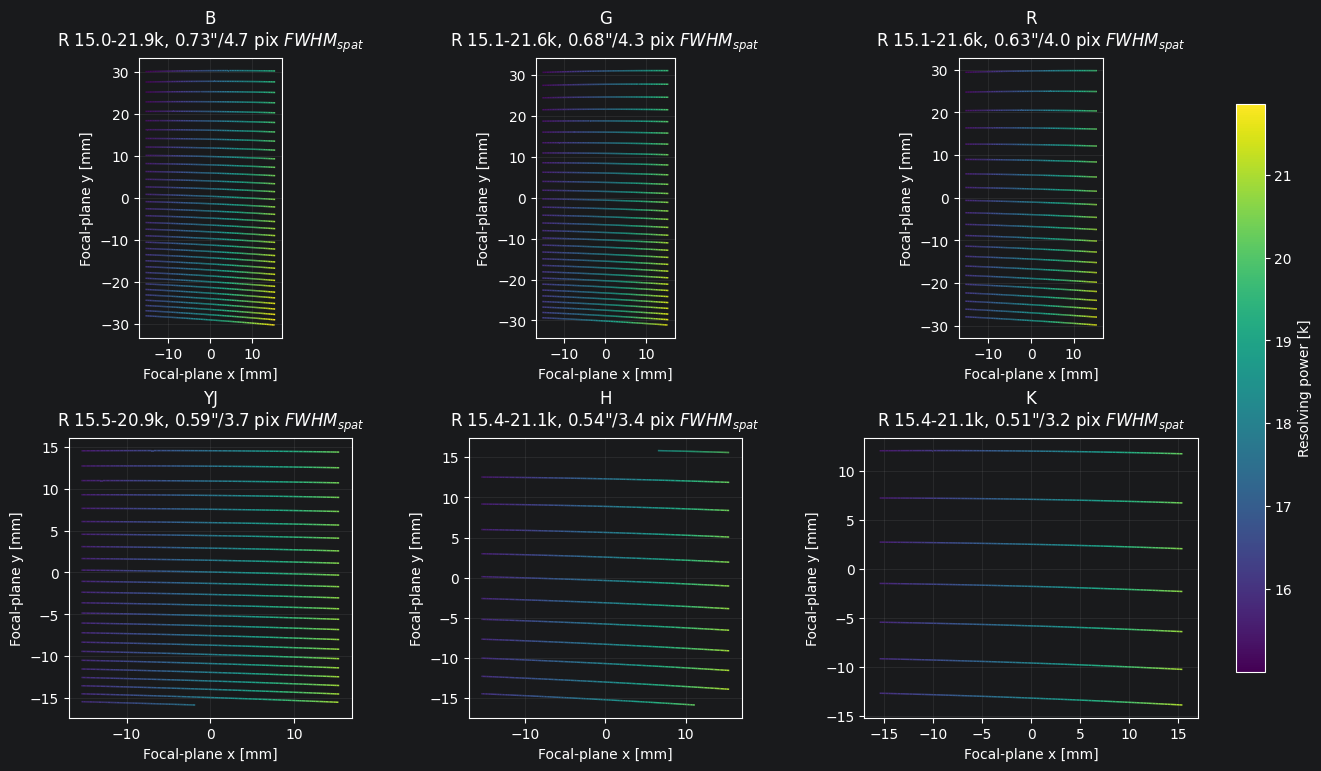

In [5]:
trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))

fig, axes = plot_resolving_power_echellogram(trace_resolution, max_display_samples_per_trace=128)
display(fig)
plt.close(fig)


## Model Inventory

This is the compact checklist of what is active in the simulator. A release validation notebook should make omissions as visible as included machinery. Total integrated scatter from bright sky lines is not yet a ScopeSim/IRDB effect; the relevant physics is shown later as a back-of-the-envelope scale and should become a follow-up ScopeSim effect.

In [6]:
inventory_rows = []
for effect in zs.optics_manager.all_effects:
    meta = getattr(effect, "meta", {}) or {}
    inventory_rows.append({
        "included": bool(getattr(effect, "include", True)),
        "effect": effect_name(effect),
        "class": effect.__class__.__name__,
        "selector": meta.get("selector_key", ""),
        "source file": meta.get("filename", ""),
    })
inventory = pd.DataFrame(inventory_rows)
display_frame(inventory[inventory["included"]])

known_omissions = pd.DataFrame([
    {"item": "Total integrated scatter (TIS)", "status": "not yet a ScopeSim effect", "consequence": "bright sky-line scatter/interline floor must be handled as a BoE note until implemented"},
    {"item": "Extracted-spectrum optimal aperture", "status": "not a detector readout product", "consequence": "readout/SNR images are per-pixel diagnostics, not a reduced spectrum"},
    {"item": "Science-specific observing sequence", "status": "user notebook layer", "consequence": "change DIT/NDIT/slit/source here before rerunning"},
])
display_frame(known_omissions)


included,effect,class,selector,source file
True,atmo_transmission,TERCurve,,TER_maunakea_tapas.dat
True,continuum_emission,SkyBackgroundTERCurve,,nan
True,airglow_and_interline_continuum,PalaceAirglowEmission,,nan
True,seeing_psf,AOEnhanceablePSF,,nan
True,adc_residuals,ADCShift,,adc_residuals.dat
True,telescope_reflection,SurfaceList,,LIST_keck_mirrors.dat
True,dichroic_tree,DichroicTree,,nan
True,slitwheel_selector,SelectorWheel,aperture_id,nan
True,channel_optics_selector,SelectorWheel,aperture_id,nan
True,trace_eff_analytical,EchelleSpectralEfficiency,,traces/echelle_trace_parameters.dat


item,status,consequence
Total integrated scatter (TIS),not yet a ScopeSim effect,bright sky-line scatter/interline floor must be handled as a BoE note until implemented
Extracted-spectrum optimal aperture,not a detector readout product,"readout/SNR images are per-pixel diagnostics, not a reduced spectrum"
Science-specific observing sequence,user notebook layer,change DIT/NDIT/slit/source here before rerunning


## Slit Loss, Seeing, AO Design Curves, And Atmospheric Dispersion

These plots are diagnostics for the optical geometry rather than extracted data products. The first plot uses color for seeing/AO, dash pattern for slit choice, opacity for airmass, and short tick marks on the line for ADC off. Line weight is reserved for the fully current observing combination. The slit legend uses `*` for the selected VIS slit and `^` for the selected NIR slit when a selected slit is one of the plotted extrema; when both arms use the same non-extremal selected slit, that shared style is labeled `Selected slit`. The second plot isolates PSF loss as a function of slit width. Legend labels pair VIS/NIR wavelengths by construction, for example `0.65" NS, 500/1250 nm`; if that pairing breaks, the plot should fail instead of silently changing meaning.


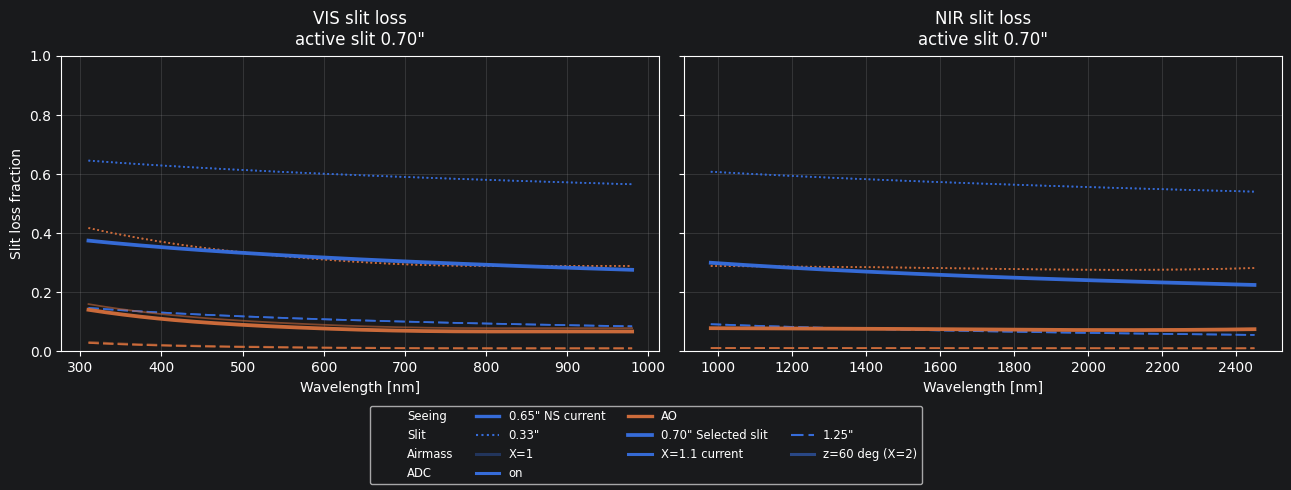

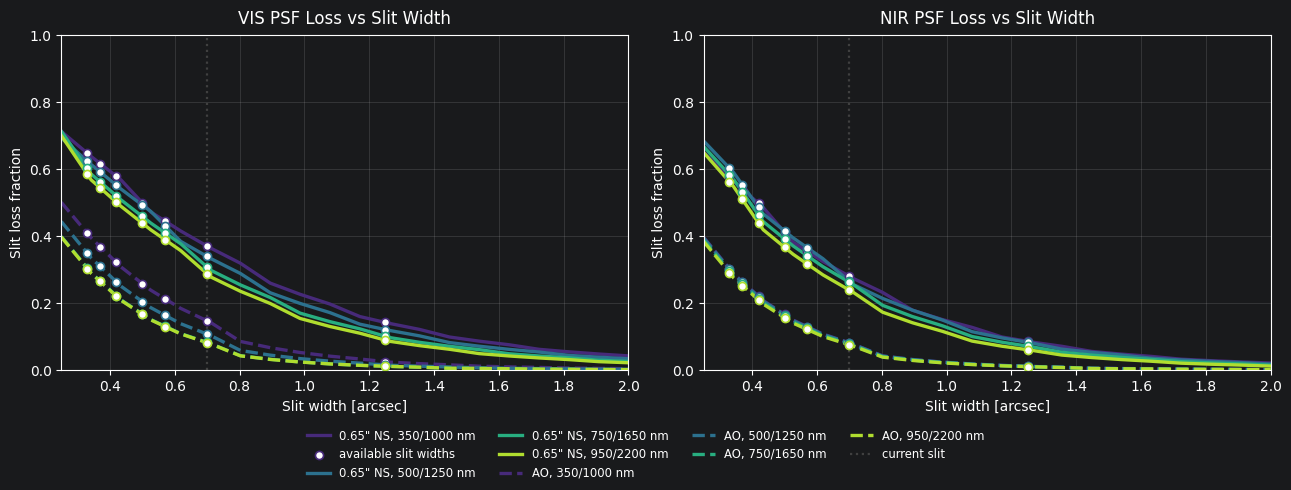

In [7]:
slit_loss_data = build_slit_loss_data(zs, n_wave=160, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_loss_by_arm(slit_loss_data, show_airmass_states=True, show_adc_states=False)

slit_width_loss_data = build_slit_width_loss_data(zs, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_width_loss(slit_width_loss_data)


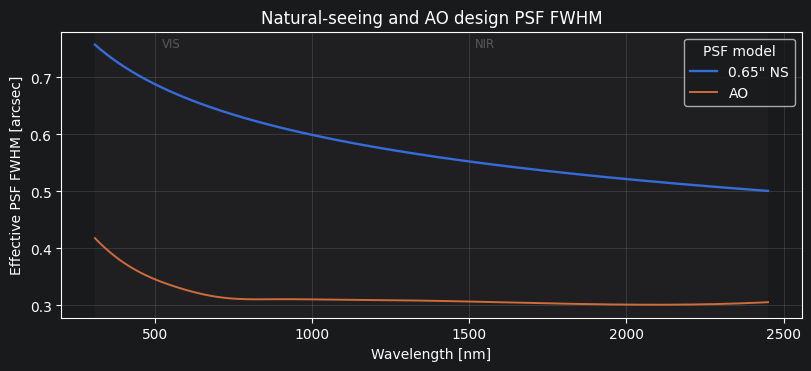

In [8]:
psf_wave_nm = np.linspace(
    min(arm["wave_nm"].to_value(u.nm).min() for arm in slit_loss_data["arms"].values()),
    max(arm["wave_nm"].to_value(u.nm).max() for arm in slit_loss_data["arms"].values()),
    700,
) * u.nm

psf_seeing = slit_loss_data["seeing_arcsec"]
psf_zenith = slit_loss_data["current_zenith_angle_deg"].to(u.deg)

fig, ax = plt.subplots(figsize=(8.0, 3.6), constrained_layout=True)
for mode_name, mode in slit_loss_data["psf_modes"].items():
    fwhm = mode["fwhm_func"](psf_wave_nm, psf_zenith, psf_seeing).to_value(u.arcsec)
    ax.plot(
        psf_wave_nm.to_value(u.nm),
        fwhm,
        label=mode["label"],
        linewidth=1.7 if mode.get("current", False) else 1.4,
    )

for arm_name, arm in slit_loss_data["arms"].items():
    wave = arm["wave_nm"].to_value(u.nm)
    ax.axvspan(wave.min(), wave.max(), color="0.5", alpha=0.06, lw=0)
    ax.text(
        np.sqrt(wave.min() * wave.max()),
        0.98,
        arm_name,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize="small",
        color="0.35",
    )

# ax.set_xscale("log")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Effective PSF FWHM [arcsec]")
ax.set_title("Natural-seeing and AO design PSF FWHM")
ax.grid(True, which="both", alpha=0.25)
ax.legend(title="PSF model")
display(fig)
plt.close(fig)

In [9]:
slit_width_rows = []
for arm_name, arm in slit_width_loss_data["arms"].items():
    slit_widths = arm["slit_widths_arcsec"].to_value(u.arcsec)
    current_slit = arm["current_slit_width_arcsec"].to_value(u.arcsec)
    for curve in arm["curves"].values():
        slit_width_rows.append({
            "arm": arm_name,
            "PSF / ADC case": curve["psf_mode"],
            "wavelength [nm]": curve["wavelength_nm"],
            "active slit [arcsec]": current_slit,
            "transmission at active slit": np.interp(current_slit, slit_widths, curve["throughput"]),
            "loss at active slit": np.interp(current_slit, slit_widths, curve["loss"]),
        })
display_frame(
    slit_width_rows,
    formats={
        "wavelength [nm]": "{:.0f}",
        "active slit [arcsec]": "{:.2f}",
        "transmission at active slit": "{:.3f}",
        "loss at active slit": "{:.3f}",
    },
)

display_frame(slit_adc_psf_status_table(zs))


arm,PSF / ADC case,wavelength [nm],active slit [arcsec],transmission at active slit,loss at active slit
VIS,no_ao,350,0.70,0.630,0.370
VIS,no_ao,500,0.70,0.661,0.339
VIS,no_ao,750,0.70,0.692,0.308
VIS,no_ao,950,0.70,0.713,0.287
VIS,ao,350,0.70,0.853,0.147
VIS,ao,500,0.70,0.892,0.108
VIS,ao,750,0.70,0.917,0.083
VIS,ao,950,0.70,0.918,0.082
NIR,no_ao,1000,0.70,0.720,0.280
NIR,no_ao,1250,0.70,0.735,0.265


category,scope,name,class,setting,note
slit,"aperture_id 0, 1, 2, 3, 4, 5",slitwheel_selector,SlitWheel,current_slit=0.7,filename_format=slits/slit_{:.2f}_as.dat
adc optics,"aperture_id 0, 1, 2",channel_optics_selector,SurfaceList,"VIS_ADC_12, VIS_ADC_34",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
adc optics,"aperture_id 3, 4, 5",channel_optics_selector,SurfaceList,"NIR_ADC_1, NIR_ADC_2, NIR_ADC_3, NIR_ADC_4",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
atmospheric dispersion,global,adc_residuals,ADCShift,filename=adc_residuals.dat,
psf,global,seeing_psf,AOEnhanceablePSF,"filename=None, fwhm={'seeing': 0.65, 'seeing_unit': 'arcsec', 'pivot_wave': 500, 'pivot_wave_unit': 'nm'}, alpha=4.765",


## Throughput Components And Total

This figure has two jobs. The six small panels preserve the diagnostic decomposition: telescope/static optics, selected instrument optics, dichroics, disperser/order efficiencies, trace-position detector QE, and the resulting instrument/order curves. The all-channel panel underneath is the presentation summary: thin background curves show telescope, dichroic, optics, active slit transmission, and trace-QE median; dashed curves are `instrument` and solid curves are `total` after telescope and active slit transmission.


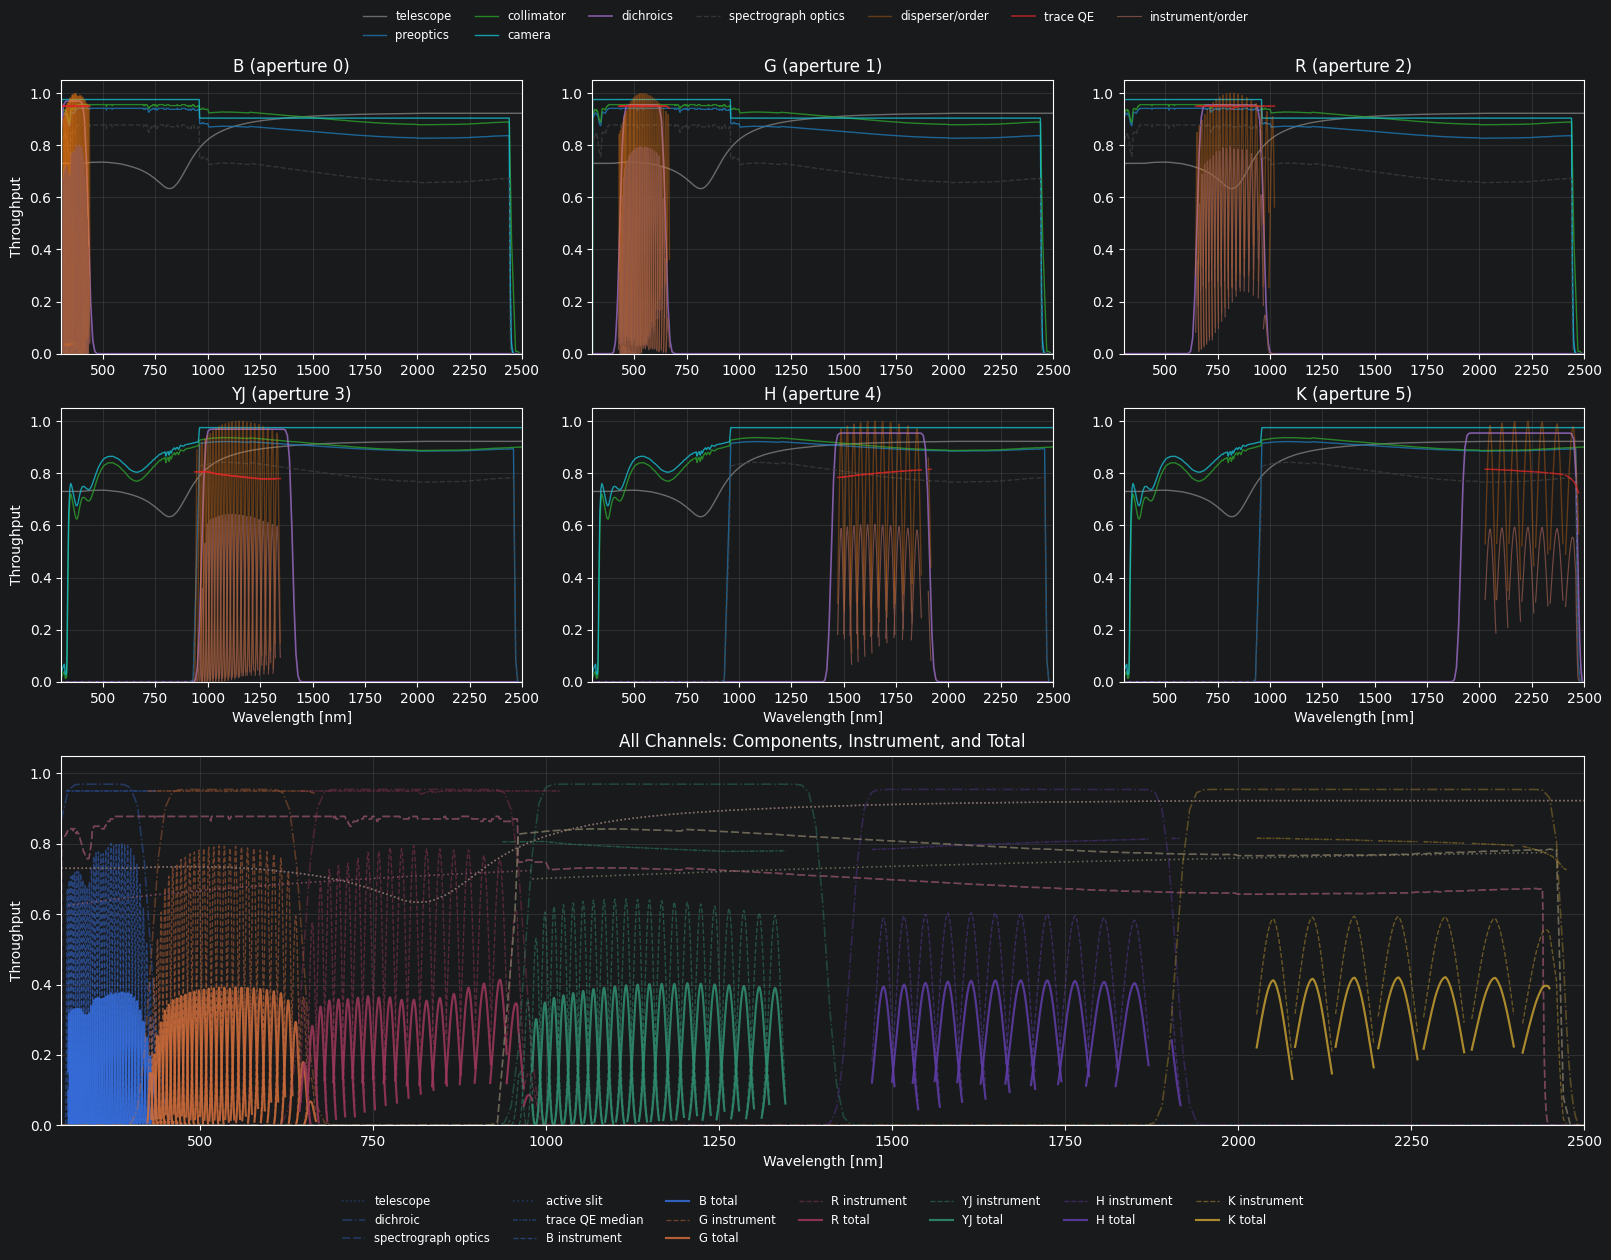

In [10]:
sim_wave_min_nm = u.Quantity(cmd_value("!SIM.spectral.wave_min"), u.um).to_value(u.nm)
sim_wave_max_nm = u.Quantity(cmd_value("!SIM.spectral.wave_max"), u.um).to_value(u.nm)
wave_nm = np.linspace(sim_wave_min_nm, sim_wave_max_nm, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_transmission_sanity_data(transmission_data)
fig, axes = plot_transmission_sanity(transmission_data, slit_loss_data=slit_loss_data, summary_component_alpha=0.38, summary_component_linewidth=1.15)


In [11]:
def active_slit_transmission_for_channel(channel_label):
    arm_name = "VIS" if channel_label in ("B", "G", "R") else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave_values, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

throughput_rows = []
wave_values = transmission_data["wave_nm"].to_value(u.nm)
for aperture_id, channel in transmission_data["channels"].items():
    active_slit = active_slit_transmission_for_channel(channel["label"])
    order_peaks = []
    for trace_id, order in channel["orders"].items():
        total = np.asarray(order["total_with_telescope_no_slit"], dtype=float) * active_slit
        finite = np.isfinite(total)
        if not np.any(finite):
            continue
        peak_index = np.nanargmax(total)
        order_peaks.append((trace_id, wave_values[peak_index], total[peak_index]))
    best_trace, best_wave, best_throughput = max(order_peaks, key=lambda item: item[2])
    throughput_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "best_order": best_trace,
        "best_wave_nm": best_wave,
        "peak_instrument_throughput": np.nanmax([np.nanmax(order["instrument"]) for order in channel["orders"].values()]),
        "peak_total_throughput": best_throughput,
        "peak_pre_disperser_instrument": np.nanmax(channel["pre_disperser_instrument_total"]),
        "peak_telescope_throughput": np.nanmax(channel["telescope_throughput"]),
        "order_qe_method": "; ".join(channel["order_detector_qe_methods"]),
    })
throughput_summary = Table(rows=throughput_rows)
display_frame(
    throughput_summary,
    columns=["channel", "best_order", "best_wave_nm", "peak_instrument_throughput", "peak_total_throughput", "peak_pre_disperser_instrument", "peak_telescope_throughput", "order_qe_method"],
    rename={
        "best_order": "best order",
        "best_wave_nm": "best wave [nm]",
        "peak_instrument_throughput": "peak instrument",
        "peak_total_throughput": "peak total with telescope+slit",
        "peak_pre_disperser_instrument": "peak pre-disperser instrument",
        "peak_telescope_throughput": "peak telescope",
        "order_qe_method": "detector QE used by orders",
    },
    formats={
        "best wave [nm]": "{:.0f}",
        "peak instrument": "{:.3f}",
        "peak total with telescope+slit": "{:.3f}",
        "peak pre-disperser instrument": "{:.3f}",
        "peak telescope": "{:.3f}",
    },
)


channel,best order,best wave [nm],peak instrument,peak total with telescope+slit,peak pre-disperser instrument,peak telescope,detector QE used by orders
B,b_94,388,0.802,0.377,0.851,0.923,slit-center trace detector pixels
G,g_66,552,0.794,0.392,0.838,0.923,slit-center trace detector pixels
R,r_39,934,0.795,0.414,0.838,0.923,slit-center trace detector pixels
YJ,yj_63,1204,0.643,0.404,0.817,0.923,slit-center trace detector pixels
H,h_45,1686,0.604,0.412,0.773,0.923,slit-center trace detector pixels
K,k_33,2300,0.594,0.421,0.747,0.923,slit-center trace detector pixels


In [12]:
wave_q = transmission_data["wave_nm"].to(u.nm)
wave = wave_q.to_value(u.nm)

def _a(x):
    return np.asarray(getattr(x, "value", x), dtype=float)

def _mean(x, mask=None):
    x = _a(x)
    ok = np.isfinite(x) if mask is None else (mask & np.isfinite(x))
    return float(np.nanmean(x[ok])) if np.any(ok) else np.nan

def _cat(arrs):
    vals = [_a(a)[np.isfinite(_a(a))] for a in arrs]
    vals = [v for v in vals if v.size]
    return np.concatenate(vals) if vals else np.array([], dtype=float)

try:
    _, atmosphere = fetch_effect_spectrum_or_transmission(zs, "atmo_transmission", wave=wave_q)
    atmosphere = _a(atmosphere)
except Exception:
    atmosphere = np.full(wave.size, np.nan)

try:
    _trace_eff = get_effect(zs, "trace_eff_analytical")
except Exception:
    _trace_eff = None

def _slit_curve(channel_label):
    arm = slit_loss_data["arms"]["VIS" if channel_label in ("B", "G", "R") else "NIR"]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

def _xdisp(trace_id):
    try:
        spec = _trace_eff._spectrographs[str(trace_id).partition("_")[0]]
        return _a(spec.xdisp_efficiency(wave_q.to(u.um)))
    except Exception:
        return np.full(wave.size, np.nan)

rows = []
for aperture_id, ch in transmission_data["channels"].items():
    order_masks = [np.isfinite(_a(o["disperser"])) for o in ch["orders"].values()]
    band_mask = np.logical_or.reduce(order_masks) if order_masks else np.zeros(wave.size, bool)

    optics_terms = [
        _a(v) for k, v in ch["instrument_optics_groups"].items()
        if k != "ir_blocking_filter"
    ]
    optics = np.prod(optics_terms, axis=0) if optics_terms else np.ones(wave.size)

    trace_arrays = [_a(o["disperser"]) for o in ch["orders"].values()]
    qe_arrays = [_a(o["detector_qe"]) for o in ch["orders"].values()]
    xdisp_arrays = []
    for trace_id, order in ch["orders"].items():
        xdisp = _a(order["xdisperser"]) if "xdisperser" in order else _xdisp(trace_id)
        xdisp_arrays.append(np.where(np.isfinite(_a(order["disperser"])), xdisp, np.nan))

    trace_vals = _cat(trace_arrays)
    qe_vals = _cat(qe_arrays)
    xdisp_vals = _cat(xdisp_arrays)
    trace_peaks = [np.nanmax(a) for a in trace_arrays if np.isfinite(a).any()]

    rows.append({
        "band": ch["label"],
        "telescope": _mean(ch["telescope_throughput"], band_mask),
        "atmosphere": _mean(atmosphere, band_mask),
        "slit": _mean(_slit_curve(ch["label"]), band_mask),
        "dichroic": _mean(ch["dichroic_total"], band_mask),
        "optics": _mean(optics, band_mask),
        "trace peak efficiency": float(np.nanmean(trace_peaks)) if trace_peaks else np.nan,
        "mean trace efficiency FSR": float(np.nanmean(trace_vals)) if trace_vals.size else np.nan,
        "mean xdisperser efficiency": float(np.nanmean(xdisp_vals)) if xdisp_vals.size else np.nan,
        "mean QE": float(np.nanmean(qe_vals)) if qe_vals.size else np.nan,
    })
    rows[-1]['total excl atm.']=np.prod([rows[-1][k] for k in ('telescope','slit','dichroic','optics','trace peak efficiency','mean xdisperser efficiency','mean QE')])

throughput_component_means = pd.DataFrame(rows).set_index("band")
display(throughput_component_means.style.format("{:.3f}", na_rep="--"))

,telescope,atmosphere,slit,dichroic,optics,trace peak efficiency,mean trace efficiency FSR,mean xdisperser efficiency,mean QE,total excl atm.
band,,,,,,,,,,
B,0.731,0.693,0.641,0.894,0.852,0.968,0.347,0.975,0.950,0.320
G,0.729,0.911,0.674,0.847,0.877,0.953,0.482,0.959,0.950,0.316
R,0.709,0.962,0.708,0.803,0.851,0.954,0.663,0.957,0.950,0.297
YJ,0.864,0.962,0.714,0.892,0.815,0.969,0.499,0.973,0.791,0.334
H,0.917,0.876,0.745,0.939,0.790,0.978,0.686,0.988,0.800,0.391
K,0.923,0.945,0.768,0.937,0.756,0.991,0.790,0.992,0.802,0.395


## Source Construction And Slit Coordinates

Use the slit-frame convention consistently: `x` is along the slit length and `y` is across the slit width. There are two source-construction paths here, and they are not interchangeable. `scopesim_templates.star` should receive scalar coordinates, for example `x=0`, `y=0`; one-element lists create `(1, 1)` table columns in this environment and can break ScopeSim FOV extraction. Low-level table-backed sources should use one-dimensional arrays, as `field_angle_demo_sources` does internally. The cells below keep those conventions visible next to the source calls.

In [13]:
source_brightness_m_am = 20

source_angle_on_slit = angle_from_cmds(cmd, "!OBS.pupil_angle")
slit_demo_sources = field_angle_demo_sources(along_separation=5.0*u.arcsec, across_separation=0.9*u.arcsec, angle_on_slit=source_angle_on_slit, along_mag=source_brightness_m_am, across_mag=source_brightness_m_am)
star_on_slit_center = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=0, y=0, library="pyckles")
star_on_slit_plus2 = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=2, y=0, library="pyckles")
constant_photon_flat = constant_photon_flux_flat(amplitude=0.001, extent=60)
calibration_lamp = lamp_flat(zshooter_dir=zshooter_dir, resolving_power=80000, wave_step=0.05*u.AA, extent=60)

from scopesim.source.source import Source
from scopesim.source.source_templates import ab_spectrum
flat_ab_point_table = Table(
    data=[
        [0.0],                       # x: along slit
        [0.0],                       # y: across slit
        [1.0],                       # weight
        [0],                         # ref -> spectra[0]
        ["flat_ab_point_center"],
    ],
    names=["x", "y", "weight", "ref", "label"],
    units=[u.arcsec, u.arcsec, None, None, None],
)

flat_ab_point_center = Source(
    table=flat_ab_point_table,
    spectra=[ab_spectrum(mag=source_brightness_m_am)],
)


slit_validation_sources = OrderedDict()
slit_validation_sources["star_center"] = star_on_slit_center
slit_validation_sources["star_plus2_along_slit"] = star_on_slit_plus2
slit_validation_sources["flat_ab_point_center"] = flat_ab_point_center
slit_validation_sources.update(slit_demo_sources)

source_to_observe = slit_validation_sources["flat_ab_point_center"]
for name, source in slit_validation_sources.items():
    print(name)
    display_frame(source_position_table(source))

star_center


x,y,ref,weight,spec_types
0.000000,0.000000,0,0.000000,A0V


star_plus2_along_slit


x,y,ref,weight,spec_types
2.000000,0.000000,0,0.000000,A0V


flat_ab_point_center


x,y,weight,ref,label
0.000000,0.000000,1.000000,0,flat_ab_point_center


along_slit_centered


x,y,weight,ref,label
-2.500000,0.000000,1.000000,0,source_0
2.500000,0.000000,1.000000,0,source_1


across_slit_one_off


x,y,weight,ref,label
0.000000,0.000000,1.000000,0,source_0
0.000000,0.900000,1.000000,0,source_1


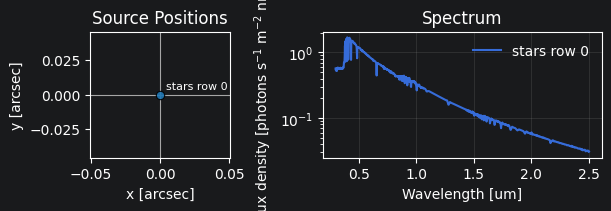

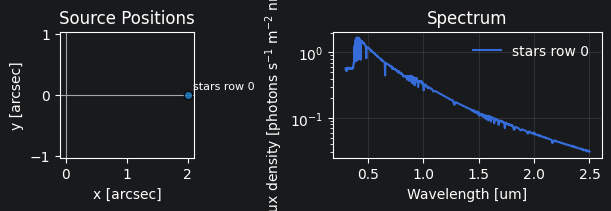

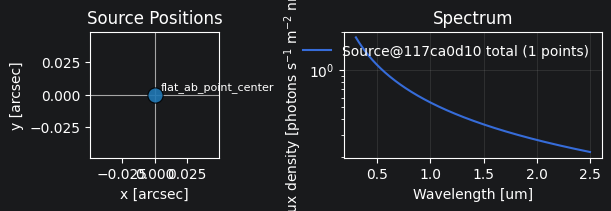

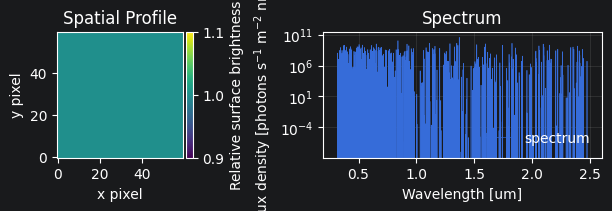

In [14]:
fig, axes = plot_source(star_on_slit_center, individual=True, spectrum_yscale="log")
fig, axes = plot_source(star_on_slit_plus2, individual=True, spectrum_yscale="log")
fig, axes = plot_source(flat_ab_point_center, spectrum_yscale="log")
lamp_plot_wave = np.linspace(0.3, 2.5, 12000) * u.um
fig, axes = plot_source(calibration_lamp, wave=lamp_plot_wave, spectrum_yscale="log", spectrum_linewidth=0.45)

## Multi-Star Slit/ADC/PSF Scene

This is the visual geometry check: it shows where table-backed sources land in the slit frame, then convolves the positions with the configured PSF and atmospheric-dispersion/ADC residual model. It is not a detector readout and should not be interpreted as extracted flux.

along_slit_centered


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,-2.500000,0.000000,True
1,source_1,2.500000,0.000000,True


across_slit_one_off


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,0.000000,0.000000,True
1,source_1,0.000000,0.900000,False


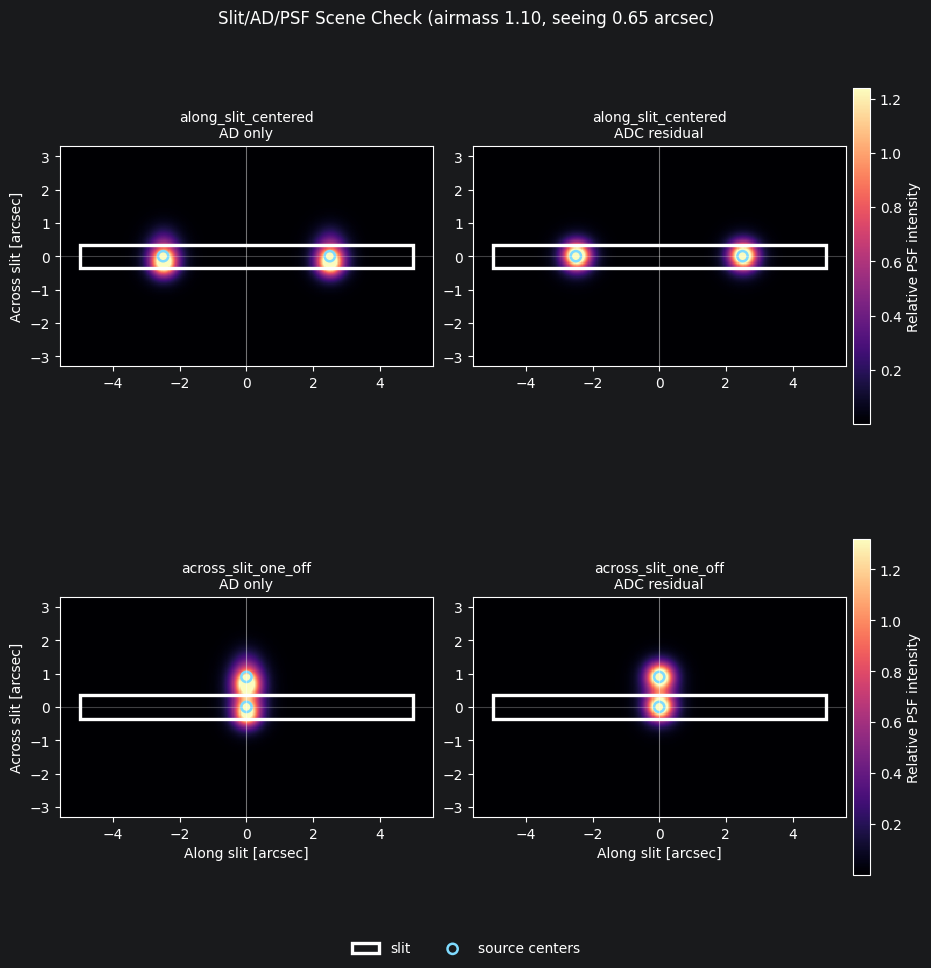

In [15]:
slit_scene_data = build_slit_adc_psf_scene_data(zs, slit_demo_sources, slit_width=cmd_value("!INST.vis_curr_slit")*u.arcsec, slit_length=10*u.arcsec, grid_step=0.035*u.arcsec)
fig, axes = plot_slit_adc_psf_scenes(slit_scene_data)
for name, scenario in slit_scene_data["scenarios"].items():
    print(name)
    display_frame(scenario["status"])

## Background Budget: Sky, Telescope, Instrument, Detector

The goal here is not just to list components but to make them comparable. The emissivity and post-disperser diffuse tables report photon/electron rates in detector-relevant units, while the detailed surface rows remain available for debugging. Telescope mirror emission must appear as a pre-disperser term; if it disappears, the optical accounting is incomplete.

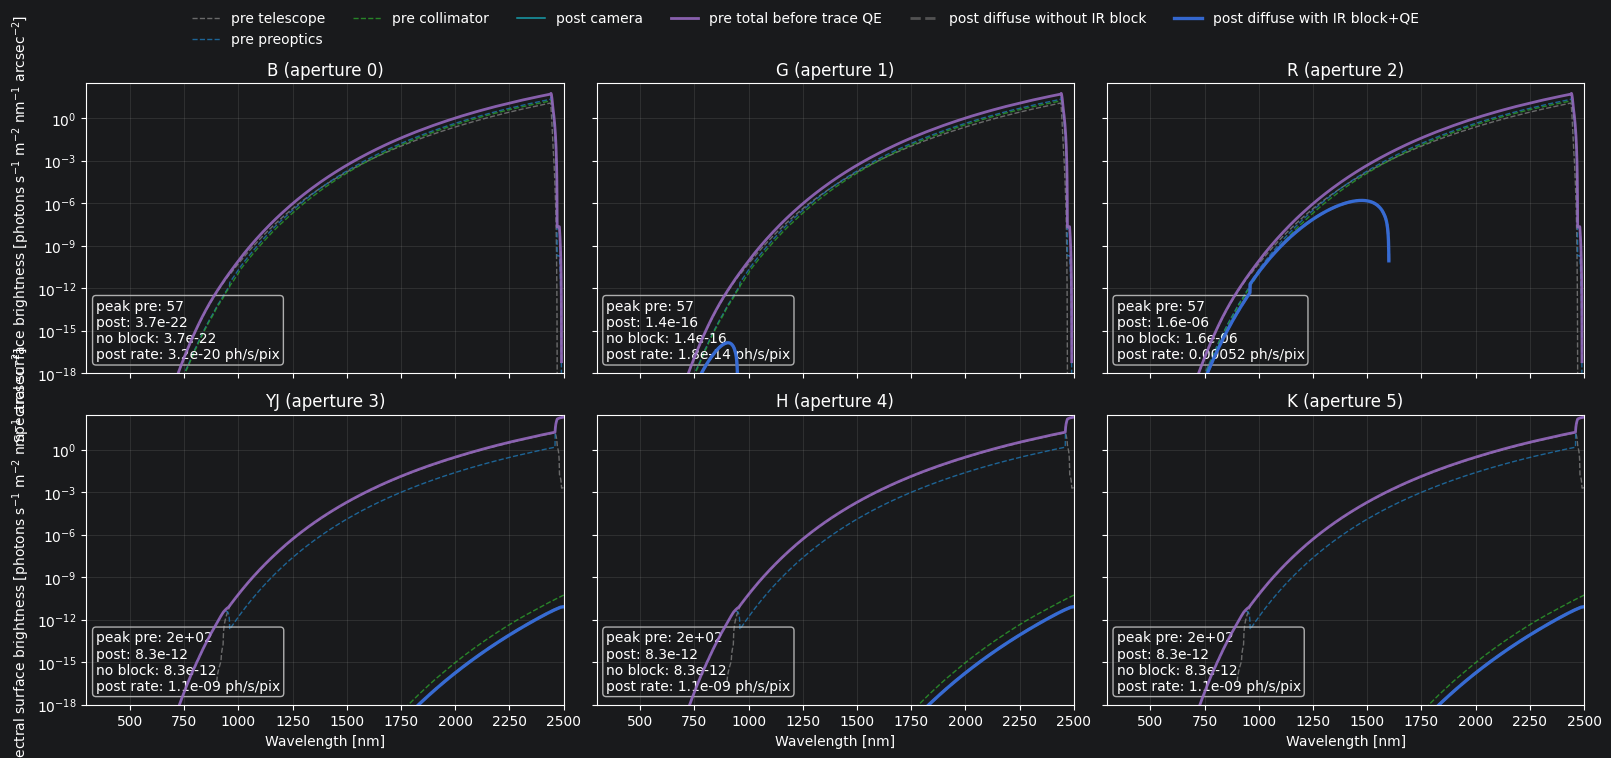

In [16]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)

In [17]:
emissivity_rows = []
for aperture_id, channel in emissivity_data["channels"].items():
    telescope = channel["pre_disperser_terms"].get("telescope", np.zeros_like(channel["pre_disperser_output_equiv"]))
    pre_no_telescope = channel["pre_disperser_output_equiv"] - telescope
    emissivity_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "peak_telescope_thermal_photlam_equiv": np.nanmax(telescope),
        "peak_other_pre_disperser_photlam_equiv": np.nanmax(pre_no_telescope),
        "peak_post_after_qe_photlam_equiv": np.nanmax(channel["post_disperser_after_qe"]),
        "post_diffuse_ph_s_pix": channel["post_disperser_rate_ph_s_pix"],
        "post_diffuse_without_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"],
        "removed_by_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"] - channel["post_disperser_rate_ph_s_pix"],
    })
emissivity_summary = Table(rows=emissivity_rows)
display_frame(
    emissivity_summary,
    columns=["channel", "peak_telescope_thermal_photlam_equiv", "peak_other_pre_disperser_photlam_equiv", "peak_post_after_qe_photlam_equiv", "post_diffuse_ph_s_pix", "post_diffuse_without_ir_block_ph_s_pix", "removed_by_ir_block_ph_s_pix"],
    rename={
        "peak_telescope_thermal_photlam_equiv": "peak telescope thermal [ph/s/cm2/A equiv]",
        "peak_other_pre_disperser_photlam_equiv": "peak other pre-disperser [ph/s/cm2/A equiv]",
        "peak_post_after_qe_photlam_equiv": "peak post-disperser after QE [ph/s/cm2/A equiv]",
        "post_diffuse_ph_s_pix": "post diffuse [ph/s/pix]",
        "post_diffuse_without_ir_block_ph_s_pix": "post diffuse no IR block [ph/s/pix]",
        "removed_by_ir_block_ph_s_pix": "removed by IR block [ph/s/pix]",
    },
    formats={
        "peak telescope thermal [ph/s/cm2/A equiv]": "{:.3e}",
        "peak other pre-disperser [ph/s/cm2/A equiv]": "{:.3e}",
        "peak post-disperser after QE [ph/s/cm2/A equiv]": "{:.3e}",
        "post diffuse [ph/s/pix]": "{:.3e}",
        "post diffuse no IR block [ph/s/pix]": "{:.3e}",
        "removed by IR block [ph/s/pix]": "{:.3e}",
    },
)

surface_debug_columns = ["channel", "component", "surface", "group", "emission_phase", "action", "temperature", "emissivity_source", "transmission_source", "peak_after_qe"]
display_frame(
    emissivity_data["details"],
    columns=surface_debug_columns,
    rename={
        "emission_phase": "emission phase",
        "temperature": "temperature [K]",
        "emissivity_source": "emissivity source",
        "transmission_source": "transmission source",
        "peak_after_qe": "peak after QE [ph/s/cm2/A equiv]",
    },
    formats={"temperature [K]": "{:.0f}", "peak after QE [ph/s/cm2/A equiv]": "{:.3e}"},
)


channel,peak telescope thermal [ph/s/cm2/A equiv],peak other pre-disperser [ph/s/cm2/A equiv],peak post-disperser after QE [ph/s/cm2/A equiv],post diffuse [ph/s/pix],post diffuse no IR block [ph/s/pix],removed by IR block [ph/s/pix]
B,1.190e-04,5.135e-04,3.689e-27,3.160e-20,3.160e-20,0.000e+00
G,1.190e-04,5.135e-04,1.403e-21,1.780e-14,1.780e-14,0.000e+00
R,1.190e-04,5.135e-04,1.570e-11,5.164e-04,5.164e-04,0.000e+00
YJ,1.598e-04,2.027e-03,8.311e-17,1.063e-09,1.063e-09,0.000e+00
H,1.598e-04,2.027e-03,8.311e-17,1.063e-09,1.063e-09,0.000e+00
K,1.598e-04,2.027e-03,8.311e-17,1.063e-09,1.063e-09,0.000e+00


channel,component,surface,group,emission phase,action,temperature [K],emissivity source,transmission source,peak after QE [ph/s/cm2/A equiv]
B,telescope_reflection,M1,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.861e-05
B,telescope_reflection,M2,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.966e-05
B,telescope_reflection,M3,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,4.074e-05
B,channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,2.761e-05
B,channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,5.515e-05
B,channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,6.207e-05
B,channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,7.043e-05
B,channel_optics_selector,VIS_Derotator_Refl_1,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.005e-05
B,channel_optics_selector,VIS_Derotator_Refl_2,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.079e-05
B,channel_optics_selector,VIS_Derotator_Refl_3,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.154e-05


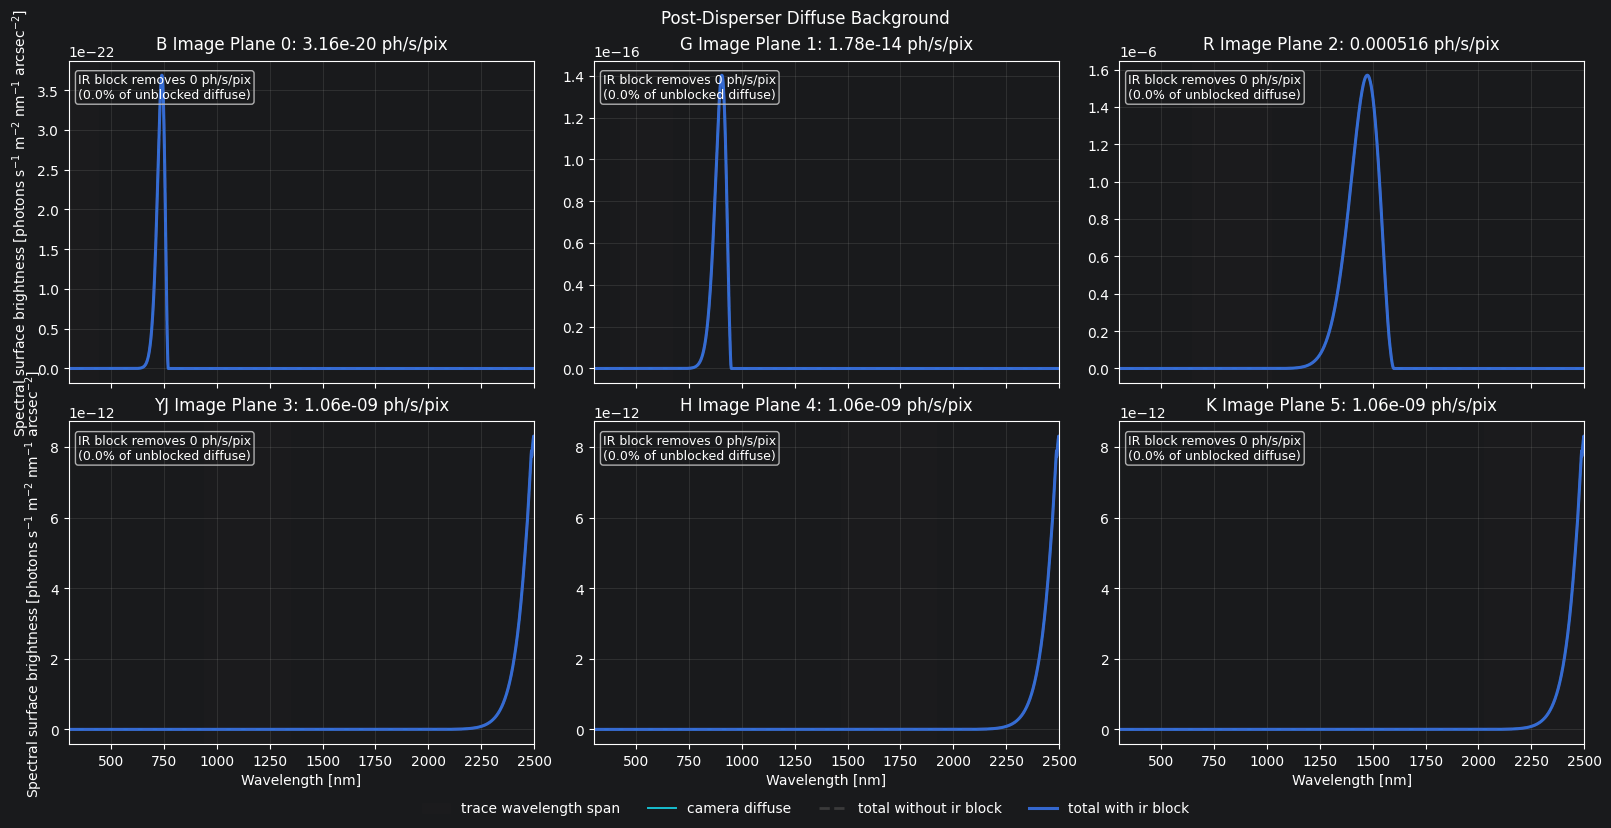

In [18]:
post_diffuse_data = build_post_disperser_diffuse_background_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_post_disperser_diffuse_background_data(post_diffuse_data)
fig, axes = plot_post_disperser_diffuse_background(post_diffuse_data)

if cmd["!INST.include_diffuse_emmisivity"]:
    post_diffuse_consistency = post_disperser_diffuse_effect_consistency_table(zs, post_diffuse_data, qe_selector_name=None, component_metadata=component_metadata)
    validate_post_disperser_diffuse_effect_consistency(post_diffuse_consistency)
    display_frame(post_diffuse_consistency)

In [19]:
qe_accounting = detector_qe_accounting_table(transmission_data, emissivity_data, post_diffuse_data)
display_frame(qe_accounting)

detector_geometry = detector_geometry_table(zs)
display_frame(detector_geometry)
display_frame(detector_selector_matrix(zs))


path,aperture_id,channel,qe_model,trace_mapped_qe,transmission_plot_qe,diffuse_qe,diffuse_position_samples,order_qe_methods,position_axis,position_min,position_max
transmission_trace_mapped,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,4,H,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,5,K,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
emissivity_sanity,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,,nan,None,None


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
0,0,B,CCD_B,2048,4096,0.015000,1.000000
1,1,G,CCD_G,2048,4096,0.015000,1.000000
2,2,R,CCD_R,2048,4096,0.015000,1.000000
3,3,YJ,APD_YJ,2048,2048,0.015000,1.000000
4,4,H,APD_H,2048,2048,0.015000,1.000000
5,5,K,APD_K,2048,2048,0.015000,1.000000


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,"filename=None, current_slit=0.7"
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TaperedQuantumEfficiency,filename=None
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=1800, ndit=2"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=1800, ndit=2, value=0.000166"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=2, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,"filename=None, current_slit=0.7"
1,G,CCD_G,channel_optics_selector,aperture_id,1,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat


detector_id,image_plane_id,channel,detector,dit_s,ndit,exposure_time_s,post_diffuse_rate_ph_s_pix,post_diffuse_e_pix,dark_current_e_s_pix,dark_current_e_pix,additive_signal_e_pix,bias_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,read_noise_e_rms,diffuse_shot_noise_e_rms,dark_shot_noise_e_rms,total_noise_e_rms
0,0,B,CCD_B,1800.000000,2.000000,3600.000000,0.000000,0.000000,0.000166,0.597600,0.597600,1040.000000,64000.000000,0.000009,ok,0.141421,0.000000,0.773046,0.785875
1,1,G,CCD_G,1800.000000,2.000000,3600.000000,0.000000,0.000000,0.000166,0.597600,0.597600,1040.000000,64000.000000,0.000009,ok,0.141421,0.000008,0.773046,0.785875
2,2,R,CCD_R,1800.000000,2.000000,3600.000000,0.000516,1.859167,0.000000,0.000799,1.859966,1040.000000,64000.000000,0.000029,ok,0.141421,1.363513,0.028270,1.371118
3,3,YJ,APD_YJ,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000100,0.360000,0.360004,0.000000,64000.000000,0.000006,ok,0.707107,0.001956,0.600000,0.927364
4,4,H,APD_H,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000100,0.360000,0.360004,0.000000,64000.000000,0.000006,ok,0.707107,0.001956,0.600000,0.927364
5,5,K,APD_K,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000100,0.360000,0.360004,0.000000,64000.000000,0.000006,ok,0.707107,0.001956,0.600000,0.927364


detector_id,image_plane_id,channel,detector,current_slit_arcsec,wavelength_mid_nm,spectral_resolution_R,resolution_element_nm,pixel_area_arcsec2,post_diffuse_ph_s_pix,post_diffuse_ph_s_arcsec2,extraction_pixels,post_diffuse_ph_s_extraction,post_diffuse_e_extraction,additive_signal_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,note
0,0,B,CCD_B,0.700000,371.580034,40000.000000,0.009290,0.024666,0.000000,0.000000,4.000000,0.000000,0.000000,0.597600,64000.000000,0.000009,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
1,1,G,CCD_G,0.700000,546.289303,40000.000000,0.013657,0.024666,0.000000,0.000000,4.000000,0.000000,0.000000,0.597600,64000.000000,0.000009,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
2,2,R,CCD_R,0.700000,832.536444,40000.000000,0.020813,0.024666,0.000516,0.020937,4.000000,0.002066,7.436667,1.859966,64000.000000,0.000029,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
3,3,YJ,APD_YJ,0.700000,1141.588625,40000.000000,0.028540,0.024666,0.000000,0.000000,4.000000,0.000000,0.000015,0.360004,64000.000000,0.000006,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
4,4,H,APD_H,0.700000,1693.905760,40000.000000,0.042348,0.024666,0.000000,0.000000,4.000000,0.000000,0.000015,0.360004,64000.000000,0.000006,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
5,5,K,APD_K,0.700000,2250.713059,40000.000000,0.056268,0.024666,0.000000,0.000000,4.000000,0.000000,0.000015,0.360004,64000.000000,0.000006,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."


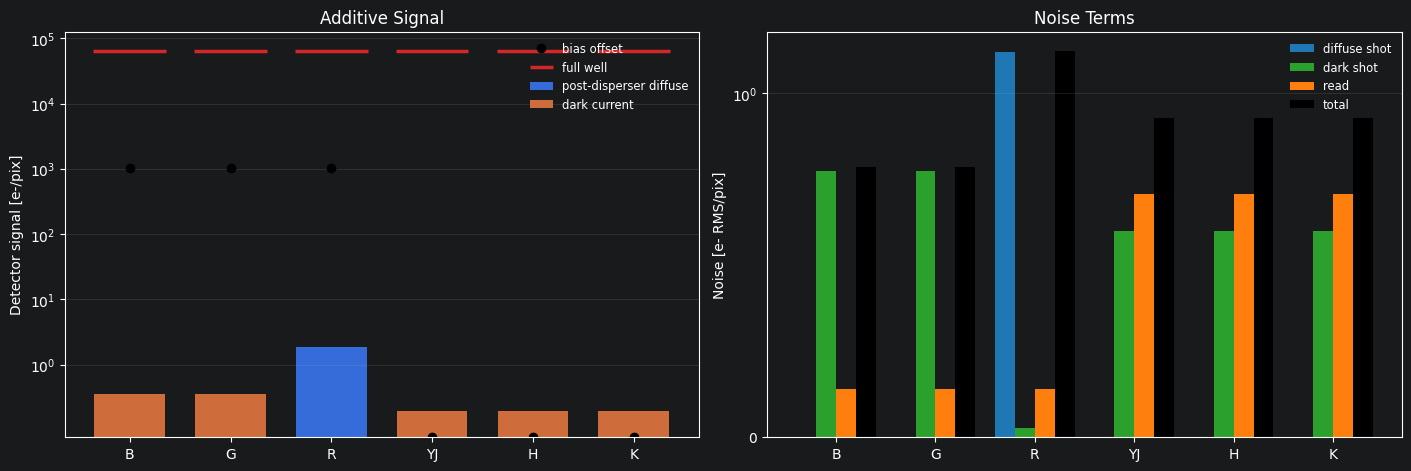

In [20]:
detector_budget = detector_background_budget_table(zs, post_diffuse_data=post_diffuse_data, post_diffuse_consistency=post_diffuse_consistency if  cmd["!INST.include_diffuse_emmisivity"] else None)
fig, axes = plot_detector_background_budget(detector_budget)
display_frame(detector_budget)

science_truth_checks = science_truth_crosscheck_table(zs, post_diffuse_data=post_diffuse_data, detector_budget=detector_budget, extraction_pixels=4.0)
display_frame(science_truth_checks)


## Sky Spectrum Components

This plots the active sky/background spectra in the same run configuration. `atmo_transmission` is multiplicative; with no source and sky emission disabled, it multiplies zero and has no impact on a background-only readout. Its thermal `emission` term is still an additive sky-background component. ScopeSim/Synphot emission spectra are PHOTLAM-like and are treated by ScopeSim's diffuse-background integrator as per square arcsecond, so this section converts them to photons s^-1 m^-2 nm^-1 arcsec^-2. The second plot shows the cumulative additive sky floor; airglow-line peak density is shown on the model evaluation grid, so detector-rate comparisons should integrate or rebin to the relevant trace/slit resolving power.

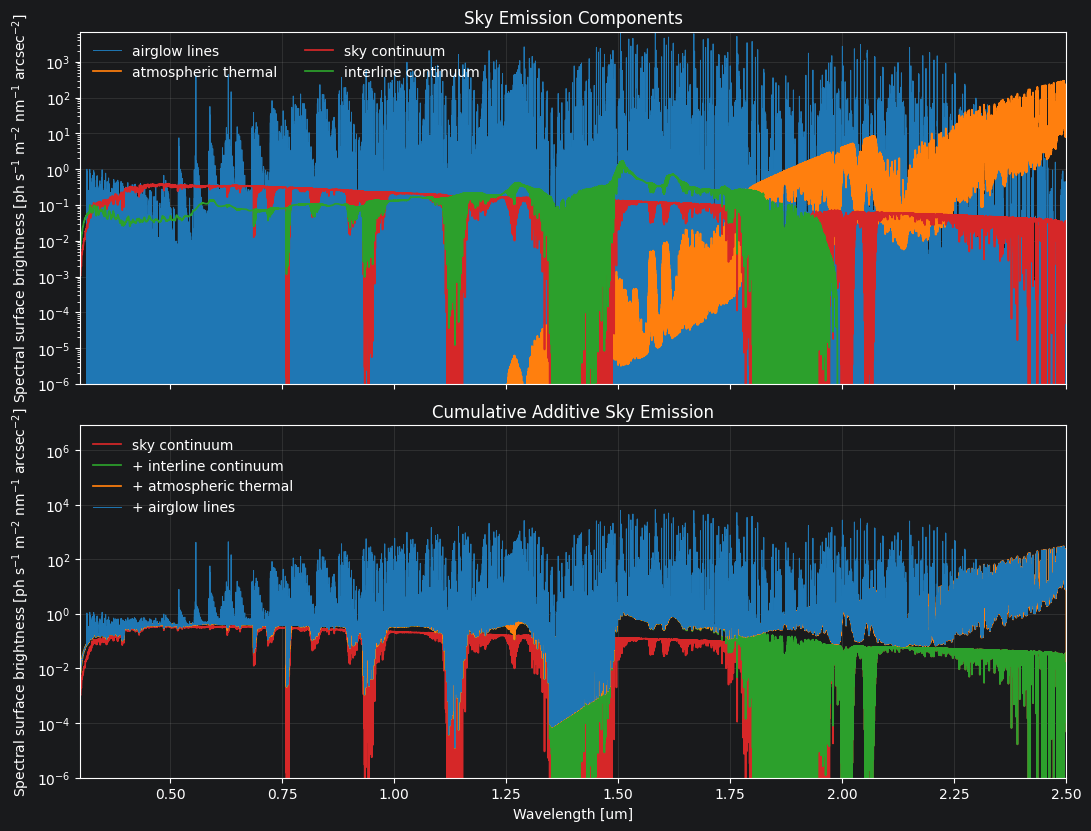

In [21]:
from synphot.units import PHOTLAM

PHOTLAM_TO_PH_S_M2_NM_ARCSEC2 = 1e5
SKY_WAVE_MIN_UM = 0.3
SKY_WAVE_MAX_UM = 2.5
SKY_SURFACE_BRIGHTNESS_LABEL = (
    r"Spectral surface brightness "
    r"[ph s$^{-1}$ m$^{-2}$ nm$^{-1}$ arcsec$^{-2}$]"
)

sky_effects = OrderedDict([
    ("airglow lines", ("airglow_and_interline_continuum", "line_TER.emission")),
    ("atmospheric thermal", ("atmo_transmission", "emission")),
    ("sky continuum", ("continuum_emission", "emission")),
    ("interline continuum", ("airglow_and_interline_continuum", "continuum_TER.emission")),

])
sky_colors = OrderedDict([
    ("sky continuum", "tab:red"),
    ("interline continuum", "tab:green"),
    ("atmospheric thermal", "tab:orange"),
    ("airglow lines", "tab:blue"),
])

def _sky_surface_brightness(values):
    return (
        u.Quantity(values).to_value(PHOTLAM)
        * PHOTLAM_TO_PH_S_M2_NM_ARCSEC2
    )

def _positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)

sky_components = OrderedDict()
for label, (effect_name_text, attribute) in sky_effects.items():
    wave_um, values = fetch_effect_spectrum_or_transmission(zs, effect_name_text, attribute)
    mask = (wave_um >= SKY_WAVE_MIN_UM * u.um) & (wave_um <= SKY_WAVE_MAX_UM * u.um)
    sky_components[label] = {
        "wave_um": wave_um[mask].to_value(u.um),
        "surface_brightness": _sky_surface_brightness(u.Quantity(values)[mask]),
    }

fig, axes = plt.subplots(2, 1, figsize=(10.8, 8.2), sharex=True, constrained_layout=True)

ax = axes[0]
for label, component in sky_components.items():
    ax.plot(
        component["wave_um"],
        _positive_for_log(component["surface_brightness"]),
        lw=0.7 if label == "airglow lines" else 1.25,
        color=sky_colors[label],
        label=label,
    )
ax.set_ylim(10**-6, None)
ax.set_title("Sky Emission Components")
ax.set_ylabel(SKY_SURFACE_BRIGHTNESS_LABEL)
ax.set_yscale("log")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)

cumulative_wave_um = sky_components["airglow lines"]["wave_um"]
running = np.zeros_like(cumulative_wave_um, dtype=float)

ax = axes[1]
for label in ("sky continuum", "interline continuum", "atmospheric thermal", "airglow lines"):
    component = sky_components[label]
    values = np.nan_to_num(component["surface_brightness"], nan=0.0, posinf=0.0, neginf=0.0)
    running += np.interp(
        cumulative_wave_um,
        component["wave_um"],
        values,
        left=0.0,
        right=0.0,
    )
    ax.plot(
        cumulative_wave_um,
        _positive_for_log(running),
        lw=0.7 if label == "airglow lines" else 1.25,
        color=sky_colors[label],
        label=(
            "sky continuum"
            if label == "sky continuum"
            else f"+ {label}"
        ),
    )

ax.set_title("Cumulative Additive Sky Emission")
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel(SKY_SURFACE_BRIGHTNESS_LABEL)
ax.set_yscale("log")
ax.set_ylim(10**-6, None)
ax.set_xlim(SKY_WAVE_MIN_UM, SKY_WAVE_MAX_UM)
ax.grid(alpha=0.2)
ax.legend(frameon=False)


## TIS Back-Of-The-Envelope Anchor

Total integrated scatter from bright sky lines is still a follow-up ScopeSim/IRDB effect. The CDR notebook uses the same physical shape shown here: `TIS = (4 pi sigma / lambda)^2`, then the camera accepts roughly `TIS * Omega_camera / (2 pi)` for a reflective grating scatter hemisphere. This is not added to the readout below; it is the scale that should be promoted into an instrument effect in a separate atomic ScopeSim/IRDB change.

term,expression,status
TIS,(4*pi*sigma/lambda)^2,BoE only here
camera acceptance,TIS * Omega_camera / (2*pi),needs ScopeSim effect
detector distribution,"requires line source, scatter kernel, and detector geometry",follow-up atomic ScopeSim/IRDB change


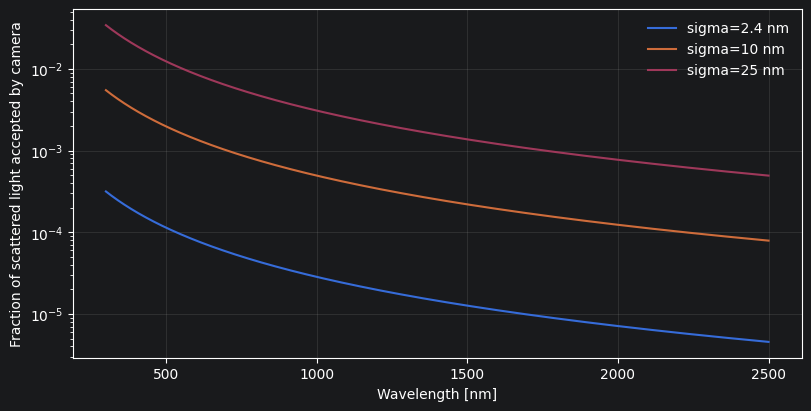

In [22]:
def tis_fraction_into_camera(wave_nm, surface_roughness_rms_nm=2.4, camera_fnum=2.0):
    wave_nm = np.asarray(wave_nm, dtype=float)
    tis = (4*np.pi*surface_roughness_rms_nm/wave_nm)**2
    camera_solid_angle = np.pi/(4*camera_fnum**2)
    return tis * camera_solid_angle/(2*np.pi)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for sigma_nm in (2.4, 10.0, 25.0):
    ax.plot(wave_nm.to_value(u.nm), tis_fraction_into_camera(wave_nm.to_value(u.nm), sigma_nm), label=f"sigma={sigma_nm:g} nm")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Fraction of scattered light accepted by camera")
ax.set_yscale("log")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

tis_notes = Table(rows=[
    {"term": "TIS", "expression": "(4*pi*sigma/lambda)^2", "status": "BoE only here"},
    {"term": "camera acceptance", "expression": "TIS * Omega_camera / (2*pi)", "status": "needs ScopeSim effect"},
    {"term": "detector distribution", "expression": "requires line source, scatter kernel, and detector geometry", "status": "follow-up atomic ScopeSim/IRDB change"},
])
display_frame(tis_notes)

## Source Photon Scale

This is explicit back-of-the-envelope math in the notebook. It does not call ScopeSim source internals. The source term uses the AB definition over one `lambda/R` element, telescope collecting area, representative order throughput, and the active point-source slit throughput. The sky term is a continuum sanity scale per arcsec2 and uses an explicit extraction solid angle; sky lines and diffuse backgrounds are checked by the readout scenarios below.


In [23]:
BOE_H_J_S = 6.62607015e-34
BOE_AB_ZERO_W_M2_HZ = 3631e-26
boe_source_abmag = source_brightness_m_am
boe_resolution = 18000.0
boe_telescope_diameter_m = 10.0
boe_geometric_10m_area_m2 = np.pi * (0.5 * boe_telescope_diameter_m)**2
boe_slit_curve_name = "no_ao_current_adc_residual"
boe_sky_ab_arcsec2 = OrderedDict([
    ("B", 21.18),
    ("G", 20.75),
    ("R", 20.40),
    ("YJ", 20.10),
    ("H", 20.10),
    ("K", 20.10),
])

def boe_ph_s_resel_at_telescope(abmag, resolving_power, area_m2, solid_angle_arcsec2=1.0):
    fnu = BOE_AB_ZERO_W_M2_HZ * 10**(-0.4 * float(abmag))
    return fnu / (BOE_H_J_S * float(resolving_power)) * float(area_m2) * float(solid_angle_arcsec2)

def boe_collecting_area_from_train(train):
    area = u.Quantity(from_currsys("!TEL.area", train.cmds))
    if area.unit == u.dimensionless_unscaled:
        area = area.value * u.m**2
    area_m2 = area.to_value(u.m**2)
    if not np.isfinite(area_m2) or area_m2 <= 0:
        raise ValueError("Built optical train has no positive !TEL.area; check the telescope SurfaceList / mirror list.")
    return float(area_m2)

boe_collecting_area_m2 = boe_collecting_area_from_train(zs)

def boe_channel_midpoint_and_throughput(channel, wave_grid_nm):
    finite_ranges = []
    throughput_values = []
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite):
            finite_ranges.append((np.nanmin(wave_grid_nm[finite]), np.nanmax(wave_grid_nm[finite])))
    wave_mid_nm = 0.5 * (min(lo for lo, _hi in finite_ranges) + max(hi for _lo, hi in finite_ranges))
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite) and np.nanmin(wave_grid_nm[finite]) <= wave_mid_nm <= np.nanmax(wave_grid_nm[finite]):
            throughput_values.append(float(np.interp(wave_mid_nm, wave_grid_nm[finite], total[finite])))
    return wave_mid_nm, float(np.nanmax(throughput_values))

def boe_slit_transmission(channel_label, wave_mid_nm, curve_name=boe_slit_curve_name):
    arm_name = "VIS" if channel_label in {"B", "G", "R"} else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"][curve_name]
    arm_wave_nm = u.Quantity(arm["wave_nm"]).to_value(u.nm)
    return float(np.interp(wave_mid_nm, arm_wave_nm, np.asarray(curve["throughput"], dtype=float)))

def boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel):
    label = str(channel["label"])
    wave_grid_nm = u.Quantity(transmission_data["wave_nm"]).to_value(u.nm)
    wave_mid_nm, throughput_no_slit = boe_channel_midpoint_and_throughput(channel, wave_grid_nm)
    slit_throughput = boe_slit_transmission(label, wave_mid_nm)
    total_source_throughput = throughput_no_slit * slit_throughput
    exposure_time_s = float(budget_by_channel[label]["exposure_time_s"])
    detector_noise_e = float(budget_by_channel[label]["total_noise_e_rms"])
    trace_row = trace_summary_by_channel[label]
    active_slit = cmd_value("!INST.vis_curr_slit") if label in {"B", "G", "R"} else cmd_value("!INST.nir_curr_slit")
    spatial_height_arcsec = float(trace_row["seeing_fwhm_median_arcsec"])
    sky_area_arcsec2 = float(active_slit) * spatial_height_arcsec
    resel_pixels = float(trace_row["resel_footprint_median_pix"])
    source_tel = boe_ph_s_resel_at_telescope(boe_source_abmag, boe_resolution, boe_collecting_area_m2)
    sky_tel = boe_ph_s_resel_at_telescope(boe_sky_ab_arcsec2[label], boe_resolution, boe_collecting_area_m2, sky_area_arcsec2)
    source_e = source_tel * total_source_throughput * exposure_time_s
    sky_e = sky_tel * throughput_no_slit * exposure_time_s
    detector_var = detector_noise_e**2 * resel_pixels
    noise_e = np.sqrt(source_e + sky_e + detector_var)
    return {
        "aperture_id": int(aperture_id),
        "channel": label,
        "wave_mid_nm": wave_mid_nm,
        "R_used": boe_resolution,
        "collecting_area_m2": boe_collecting_area_m2,
        "geometric_10m_area_m2": boe_geometric_10m_area_m2,
        "source_AB": boe_source_abmag,
        "sky_AB_arcsec2": boe_sky_ab_arcsec2[label],
        "sky_seeing_area_as2": sky_area_arcsec2,
        "throughput_no_slit": throughput_no_slit,
        "source_slit_throughput": slit_throughput,
        "source_total_throughput": total_source_throughput,
        "exposure_time_s": exposure_time_s,
        "source_e_resel": source_e,
        "sky_e_resel_continuum": sky_e,
        "detector_noise_e_pix": detector_noise_e,
        "detector_var_resel": detector_var,
        "source_shot_snr": np.sqrt(source_e),
        "boe_snr_with_sky_detector": source_e / noise_e if noise_e > 0 else np.nan,
    }

trace_summary_by_channel = {str(row["channel"]): row for row in trace_resolution_summary}
budget_by_channel = {str(row["channel"]): row for row in detector_budget}
boe_source_sky_counts = Table(rows=[boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel)
                                    for aperture_id, channel in transmission_data["channels"].items()])
display_frame(
    boe_source_sky_counts,
    formats={
        "wave_mid_nm": "{:.0f}",
        "R_used": "{:.0f}",
        "collecting_area_m2": "{:.1f}",
        "geometric_10m_area_m2": "{:.1f}",
        "source_AB": "{:.1f}",
        "sky_AB_arcsec2": "{:.2f}",
        "sky_seeing_area_as2": "{:.3f}",
        "throughput_no_slit": "{:.3f}",
        "source_slit_throughput": "{:.3f}",
        "source_total_throughput": "{:.3f}",
        "exposure_time_s": "{:.0f}",
        "source_e_resel": "{:.2e}",
        "sky_e_resel_continuum": "{:.2e}",
        "detector_noise_e_pix": "{:.1f}",
        "detector_var_resel": "{:.1f}",
        "source_shot_snr": "{:.1f}",
        "boe_snr_with_sky_detector": "{:.1f}",
    },
)


aperture_id,channel,wave_mid_nm,R_used,collecting_area_m2,geometric_10m_area_m2,source_AB,sky_AB_arcsec2,sky_seeing_area_as2,throughput_no_slit,source_slit_throughput,source_total_throughput,exposure_time_s,source_e_resel,sky_e_resel_continuum,detector_noise_e_pix,detector_var_resel,source_shot_snr,boe_snr_with_sky_detector
0,B,372,18000,76.5,78.5,20.0,21.18,0.514,0.574,0.641,0.368,3600,3.09e+03,8.35e+02,0.8,12.9,55.5,49.2
1,G,546,18000,76.5,78.5,20.0,20.75,0.478,0.393,0.674,0.265,3600,2.22e+03,7.89e+02,0.8,12.0,47.1,40.4
2,R,833,18000,76.5,78.5,20.0,20.40,0.439,0.383,0.710,0.272,3600,2.28e+03,9.78e+02,1.4,33.5,47.8,39.8
3,YJ,1142,18000,76.5,78.5,20.0,20.10,0.411,0.267,0.713,0.190,3600,1.60e+03,8.39e+02,0.9,14.3,40.0,32.3
4,H,1694,18000,76.5,78.5,20.0,20.10,0.379,0.459,0.746,0.342,3600,2.87e+03,1.33e+03,0.9,13.2,53.6,44.2
5,K,2251,18000,76.5,78.5,20.0,20.10,0.357,0.374,0.768,0.287,3600,2.41e+03,1.02e+03,0.9,12.5,49.1,41.1


## Readout Scenarios And Background Toggles

These toggles change active effect `include` flags in the already-built optical train, so they do not rebuild the train. That is the useful notebook pattern for asking: source only, sky-line impact, sky-continuum impact, diffuse-emissivity impact. Use `None` for no disabled background. Allowed strings are `sky`, `sky_continuum`, `sky_lines`, and `diffuse_emissivity`.

In [24]:
_BACKGROUND_EFFECT_NAMES = {
    "sky_continuum": ("continuum_emission",),
    "sky_lines": ("airglow_and_interline_continuum",),
    "sky": ("continuum_emission", "airglow_and_interline_continuum"),
    "diffuse_emissivity": ("post_echelle_diffuse_background_selector",),
}
READOUT_RANDOM_NOISE_EFFECTS = ("shot_noise", "readout_noise_selector")


def _effect_names_from_background_selector(name_or_names):
    if name_or_names is None:
        return []
    requested = [name_or_names] if isinstance(name_or_names, str) else list(name_or_names)
    effect_names = []
    for name in requested:
        if name not in _BACKGROUND_EFFECT_NAMES:
            raise ValueError(f"Unknown background selector {name!r}; choose from {sorted(_BACKGROUND_EFFECT_NAMES)}")
        effect_names.extend(_BACKGROUND_EFFECT_NAMES[name])
    return list(dict.fromkeys(effect_names))


@contextmanager
def temporarily_disable_effects(train, effect_names):
    if not effect_names:
        yield
        return
    effects = []
    for effect_name_text in dict.fromkeys(effect_names):
        effect = get_effect(train, effect_name_text, active_only=False)
        effects.append((effect, getattr(effect, "include", True)))
    try:
        for effect, _include in effects:
            effect.include = False
        yield
    finally:
        for effect, include in effects:
            effect.include = include


@contextmanager
def disable_background(name_or_names, *, train=None):
    train = zs if train is None else train
    with temporarily_disable_effects(train, _effect_names_from_background_selector(name_or_names)):
        yield


def observe_readout(source=None, disabled_background=None, *, train=None, disabled_effects=READOUT_RANDOM_NOISE_EFFECTS):
    train = zs if train is None else train
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    effect_names = list(disabled_effects or [])
    with disable_background(disabled_background, train=train), temporarily_disable_effects(train, effect_names), disable_scopesim_progress_bars(hide_scopesim_progress):
        if source is None:
            train.observe()
        else:
            train.observe(source)
        hdul = train.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    return hdul


In [25]:
readout_titles = ["B", "G", "R", "YJ", "H", "K"]
readout_scale_groups = [["B", "G", "R"], ["YJ", "H", "K"]]

READOUT_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="viridis",
    colorbar="Counts",
    zero_floor=False,
)
BRIGHT_READOUT_VIEW = dict(READOUT_VIEW, clip=None, vmax=1120)
BACKGROUND_VIEW = dict(READOUT_VIEW)
DELTA_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="magma",
    colorbar="Delta",
    zero_floor=True,
    shared_scale=readout_scale_groups,
)
SNR_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="viridis",
    colorbar="S/N",
    zero_floor=True,
)

readouts = OrderedDict()


In [26]:
readouts["source_full_background"] = observe_readout(source_to_observe, None)

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()



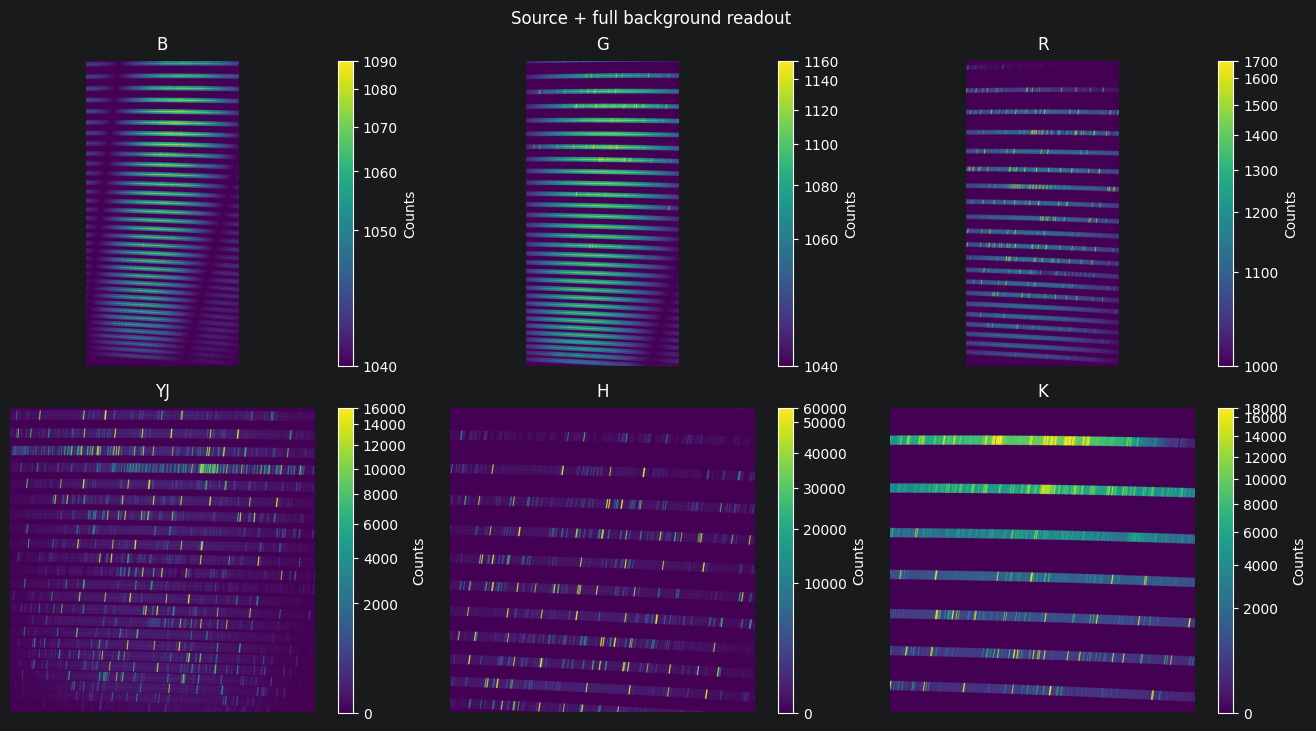

In [27]:
source_readout_products = show_and_save_hdul(
    readouts["source_full_background"],
    label="source_full_background",
    titles=readout_titles,
    output_dir=output_dir,
    save=True,
    figure_title="Source + full background readout",
    hdul_view=READOUT_VIEW,
)


In [28]:
source_readout_products["directory"]

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/science_validation_outputs/readouts/source_full_background')

In [29]:
readouts["full_background"] = observe_readout(None, None)
# readouts["source_no_sky"] = observe_readout(source_to_observe, ["sky"])
readouts["source_no_sky_lines"] = observe_readout(source_to_observe, ["sky_lines"])
readouts["background_no_sky_lines"] = observe_readout(None, ["sky_lines"])
# readouts["background_no_sky_continuum"] = observe_readout(None, ["sky_continuum"])
if cmd["!INST.include_diffuse_emmisivity"]:
    readouts["source_no_diffuse_emissivity"] = observe_readout(source_to_observe, ["diffuse_emissivity"])


py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,6838178.596563,6838178.596563,0.000000,74.954708,0.000000,74.954708,3987222
1,G,4096x2048,14690644.412059,14690644.412059,0.000000,113.092518,0.000000,113.092518,2754269
2,R,4096x2048,14704294.975672,14704294.975672,0.000000,148.125884,0.000000,148.125884,1976802
3,YJ,2048x2048,14637096.307983,14637096.307983,0.000000,163.034528,0.000000,163.034528,1906837
4,H,2048x2048,9451662.755517,9451662.755517,0.000000,179.244782,0.000000,179.244782,856464
5,K,2048x2048,7408633.749059,7408633.749059,0.000000,193.917460,0.000000,193.917460,502366


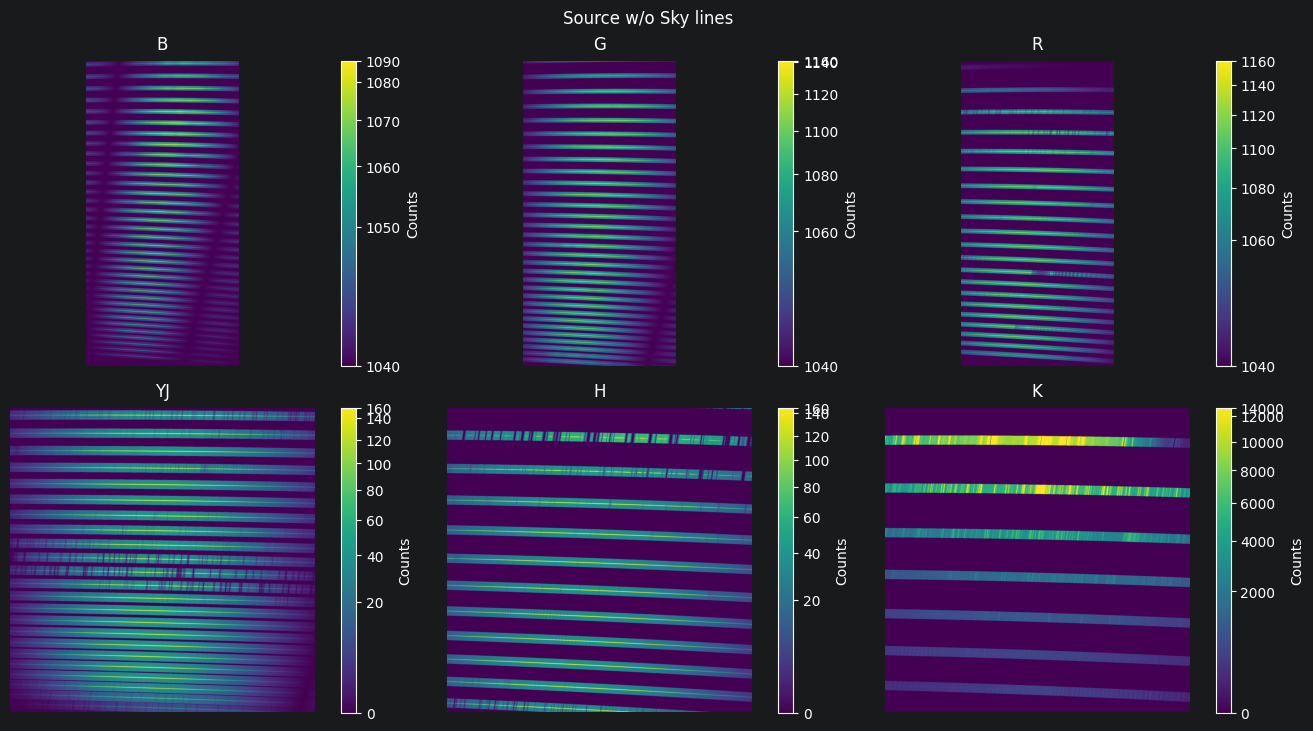

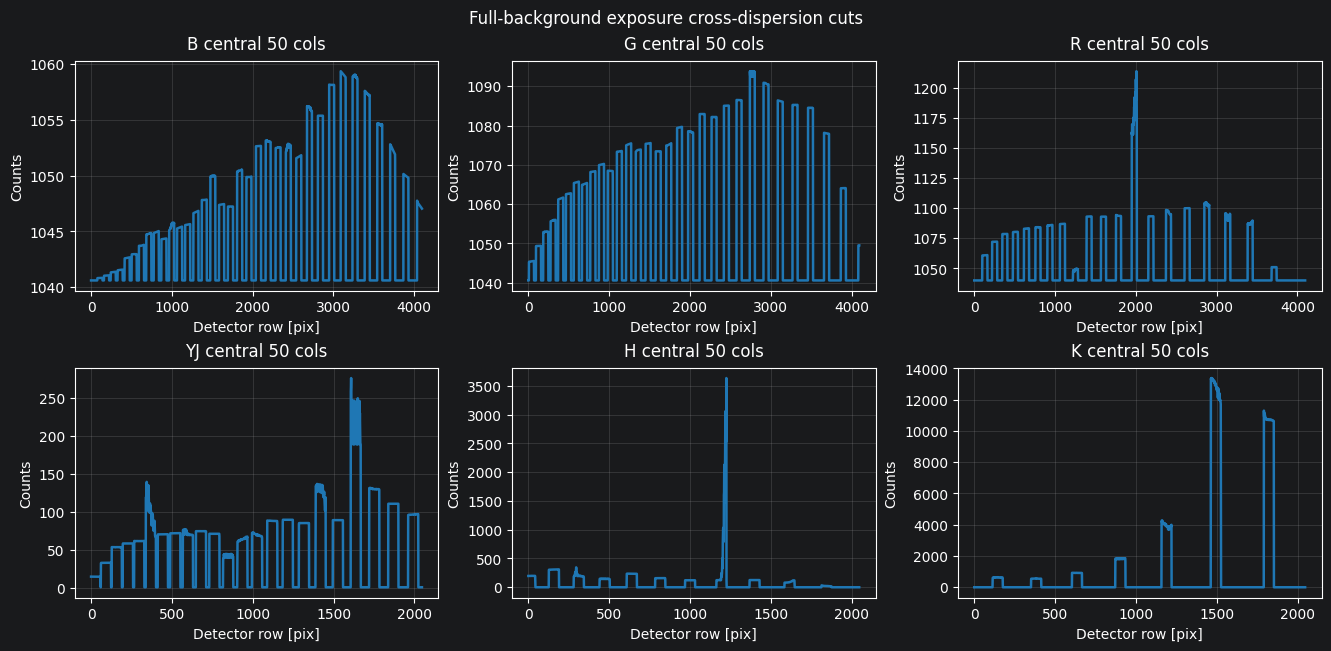

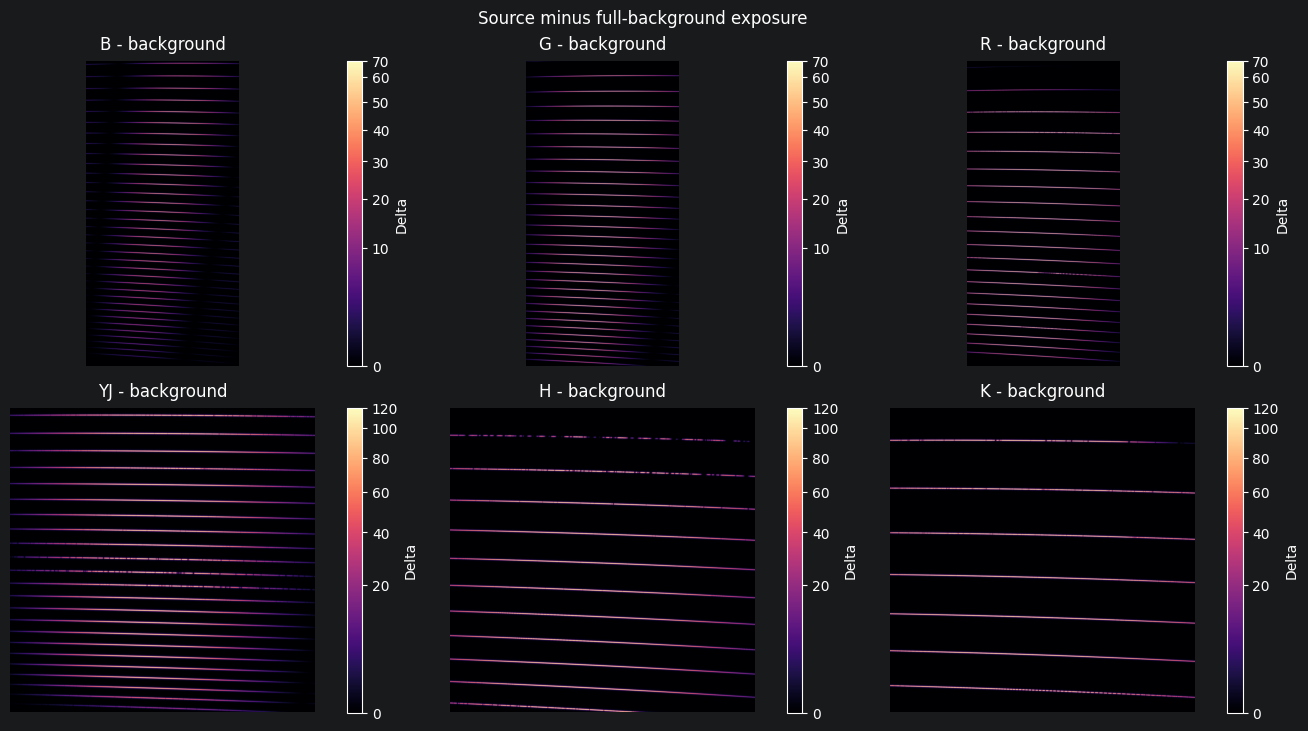

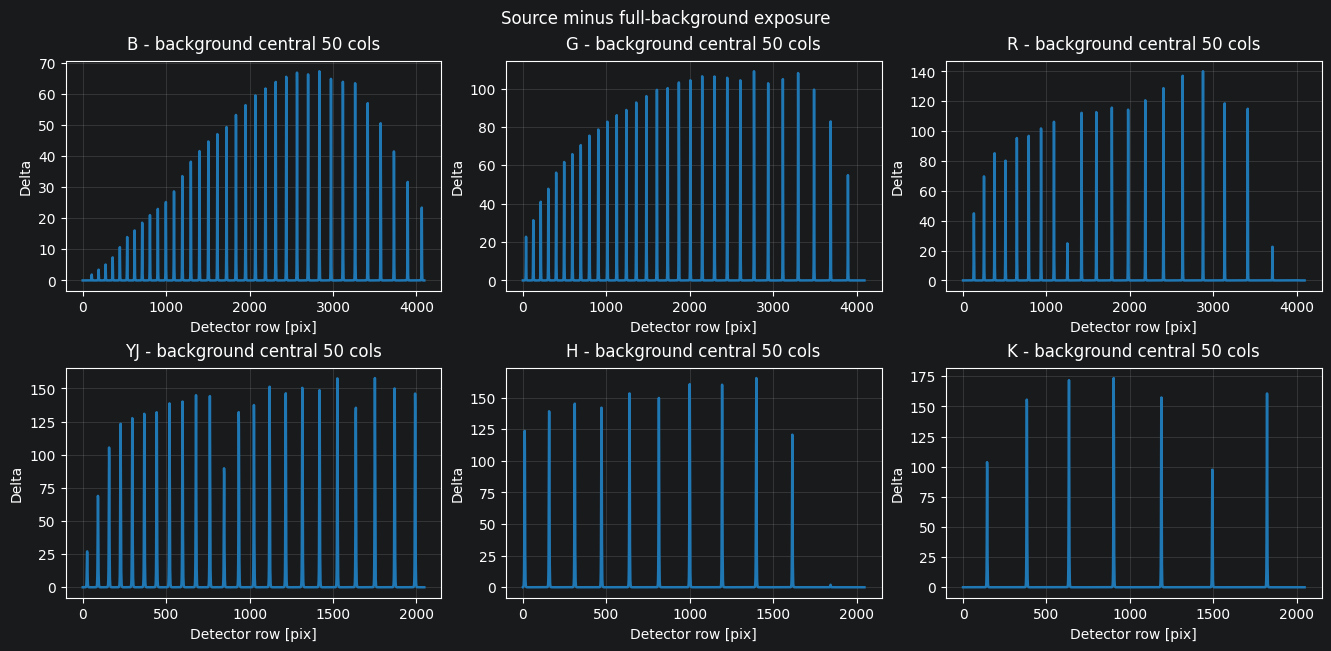

In [30]:
source_no_sky_products = show_and_save_hdul(
    readouts["source_no_sky_lines"],
    label="source_no_sky_lines",
    titles=readout_titles,
    show_hdul=True,
    show_cross_dispersion=False,
    save=False,
    figure_title="Source w/o Sky lines",
    hdul_view=READOUT_VIEW,
)

background_cut_products = show_and_save_hdul(
    readouts["full_background"],
    label="full_background",
    titles=readout_titles,
    show_hdul=False,
    show_cross_dispersion=True,
    save=False,
    figure_title="Full-background exposure cross-dispersion cuts",
    hdul_view=BACKGROUND_VIEW,
    cross_dispersion_ylabel="Counts",
)

source_minus_background = readout_delta_summary_table(readouts["source_full_background"], readouts["full_background"], titles=readout_titles)
display_frame(source_minus_background)
source_minus_background_products = show_and_save_hdul(
    readouts["source_full_background"],
    label="source_minus_background",
    titles=readout_titles,
    reference_hdul=readouts["full_background"],
    output_dir=output_dir,
    show_hdul=False,
    show_delta=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="Source minus full-background exposure",
    delta_view=DELTA_VIEW,
    delta_title_suffix=" - background",
    cross_dispersion_ylabel="Delta",
)


sky-line contribution


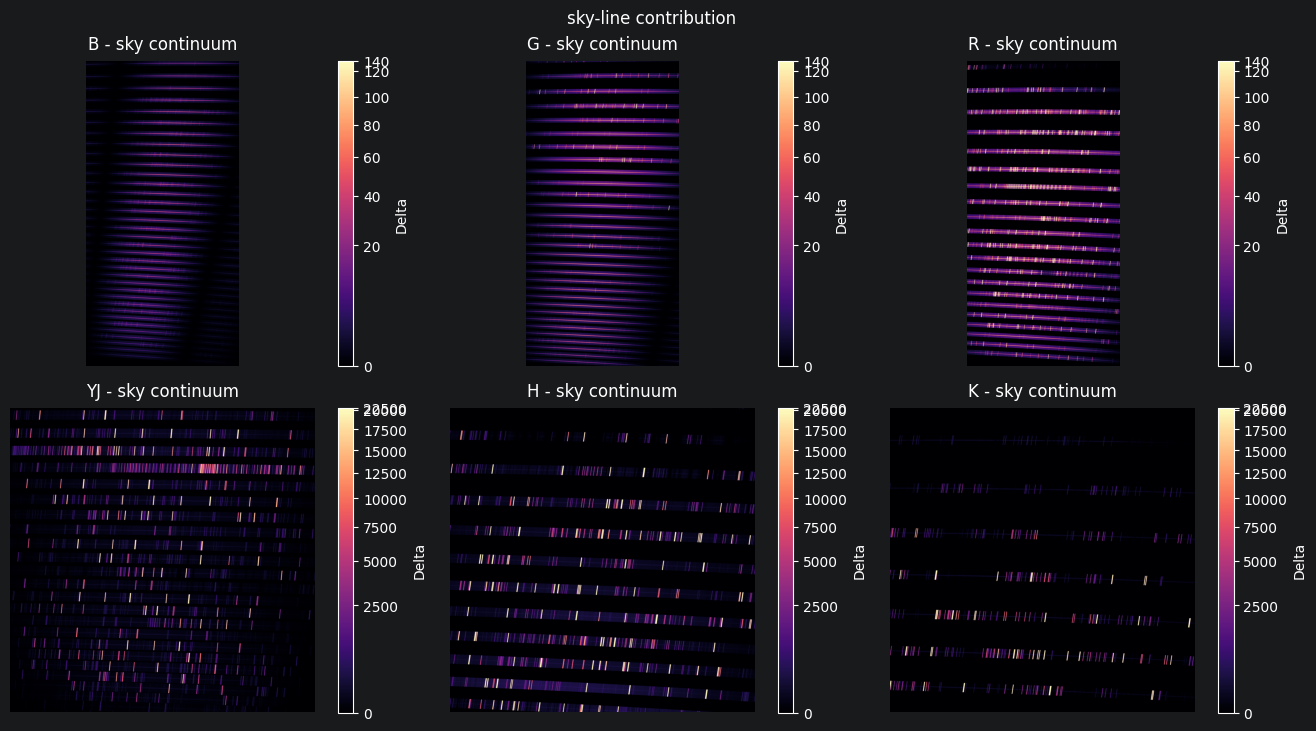

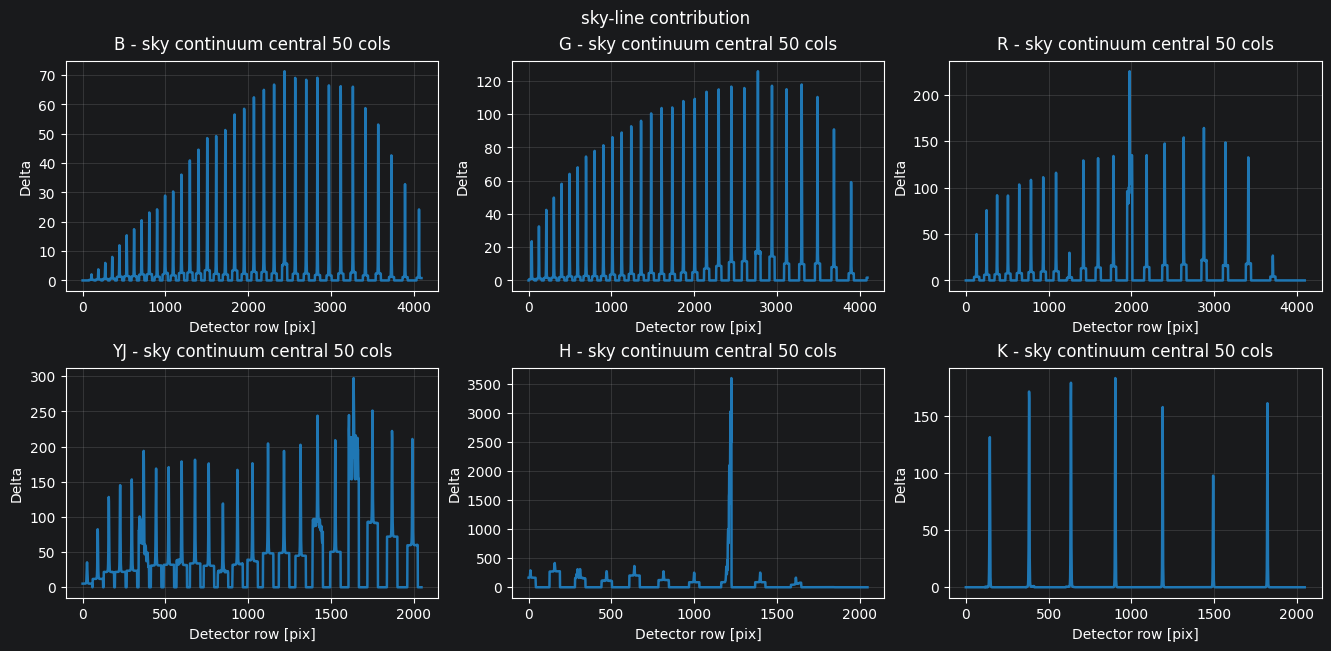

In [31]:
scenario_deltas = OrderedDict([
    ("sky-line contribution", (readouts["source_full_background"], readouts["background_no_sky_lines"], " - sky continuum")),
    # ("sky continuum contribution", (readouts["source_full_background"], readouts["background_no_sky_continuum"], " - sky lines")),
])
if cmd["!INST.include_diffuse_emmisivity"]:
    scenario_deltas["diffuse emissivity contribution"] = (readouts["source_full_background"], readouts["source_no_diffuse_emissivity"], " - no diffuse")
for label, (signal, reference, suffix) in scenario_deltas.items():
    print(label)
    show_and_save_hdul(
        signal,
        reference_hdul=reference,
        label=label.replace(" ", "_"),
        titles=readout_titles,
        show_hdul=False,
        show_delta=True,
        show_cross_dispersion=True,
        save=False,
        figure_title=label,
        delta_view=DELTA_VIEW,
        delta_title_suffix=suffix,
        cross_dispersion_ylabel="Delta",
    )


## Per-Pixel And Resolution-Element S/N Diagnostics

The S/N images use `source_no_sky_lines - background_no_sky_lines` for the source signal. These readouts are generated with stochastic shot/read-noise draws disabled; the variance is then computed analytically from source counts, the simulated background exposure, dark current, diffuse detector/background counts, and read noise. Subtracting a background exposure removes its mean level, not its variance, so the matched-background convention adds the background and detector variance from both exposures.


In [32]:
def readout_image(channel_hdul):
    if isinstance(channel_hdul, np.ndarray):
        return np.asarray(channel_hdul, dtype=float)
    if hasattr(channel_hdul, "data") and channel_hdul.data is not None:
        return np.asarray(channel_hdul.data, dtype=float)
    image_hdu = channel_hdul[1]
    return np.asarray(image_hdu.data, dtype=float)


def detector_terms_from_row(row):
    bias = float(row["bias_e_pix"])
    dark = float(row["dark_current_e_pix"])
    diffuse = float(row["post_diffuse_e_pix"])
    read_rms = float(row["read_noise_e_rms"])
    detector_variance = dark + diffuse + read_rms**2
    return {
        "bias_e_pix": bias,
        "dark_current_e_pix": dark,
        "post_diffuse_e_pix": diffuse,
        "read_noise_e_rms": read_rms,
        "detector_variance_e2_pix": detector_variance,
        "mean_detector_signal_e_pix": dark + diffuse,
    }


def detector_term_table(budget_table, *, rtol=1e-6):
    rows = []
    for row in budget_table:
        terms = detector_terms_from_row(row)
        total_rms = float(row["total_noise_e_rms"]) if "total_noise_e_rms" in budget_table.colnames else np.nan
        total_variance = total_rms**2 if np.isfinite(total_rms) else np.nan
        component_variance = terms["detector_variance_e2_pix"]
        if np.isfinite(total_variance) and not np.isclose(component_variance, total_variance, rtol=rtol, atol=rtol):
            print(
                f"Warning: detector variance components for {row['channel']} give "
                f"{component_variance:.6g} e^2/pix, but total_noise_e_rms^2 is "
                f"{total_variance:.6g} e^2/pix. Using explicit components."
            )
        rows.append({
            "channel": str(row["channel"]),
            **terms,
            "total_noise_e_rms": total_rms,
            "total_noise_variance_e2_pix": total_variance,
        })
    return Table(rows=rows)


def snr_images_from_readouts(source_hdul, background_hdul, detector_table, titles):
    terms_by_channel = {str(row["channel"]): detector_terms_from_row(row) for row in detector_table}
    signal_images = []
    background_images = []
    snr_images = []
    for title, source_hdu, background_hdu in zip(titles, source_hdul, background_hdul, strict=True):
        terms = terms_by_channel[str(title)]
        source_image = readout_image(source_hdu)
        background_image = readout_image(background_hdu)
        signal = source_image - background_image
        signal_pos = np.clip(signal, 0, None)
        background = np.clip(
            background_image - terms["bias_e_pix"] - terms["mean_detector_signal_e_pix"],
            0,
            None,
        )
        one_exposure_fixed_variance = background + terms["detector_variance_e2_pix"]
        variance = signal_pos + 2.0 * one_exposure_fixed_variance
        snr = np.divide(signal_pos, np.sqrt(variance), out=np.zeros_like(signal_pos), where=variance > 0)
        signal_images.append(signal)
        background_images.append(background)
        snr_images.append(snr)
    return signal_images, background_images, snr_images

def resolution_footprint_from_summary(summary_table):
    rows = []
    display_rows = []
    for row in summary_table:
        channel = str(row["channel"])
        spectral_fwhm = float(row["spectral_fwhm_pix"])
        spatial_min = float(row["spatial_fwhm_min_pix"])
        spatial_median = float(row["spatial_fwhm_median_pix"])
        spatial_max = float(row["spatial_fwhm_max_pix"])
        resel_min = float(row["resel_footprint_min_pix"])
        resel_median = float(row["resel_footprint_median_pix"])
        resel_max = float(row["resel_footprint_max_pix"])
        rows.append({
            "channel": channel,
            "current_slit_arcsec": float(row["active_slit_width_arcsec"]),
            "trace_R_median": float(row["trace_R_median"]),
            "dispersion_median_nm_pix": float(row["dispersion_median_nm_pix"]),
            "spectral_fwhm_pix": spectral_fwhm,
            "psf_fwhm_median_arcsec": float(row["seeing_fwhm_median_arcsec"]),
            "pixel_scale_arcsec_pix": float(row["pixel_scale_arcsec_pix"]),
            "spatial_fwhm_pix": spatial_median,
            "spatial_fwhm_min_pix": spatial_min,
            "spatial_fwhm_max_pix": spatial_max,
            "resel_pixels_fwhm": resel_median,
            "resel_pixels_min_fwhm": resel_min,
            "resel_pixels_max_fwhm": resel_max,
        })
        display_rows.append({
            "channel": channel,
            "slit [arcsec]": float(row["active_slit_width_arcsec"]),
            "R": float(row["trace_R_median"]),
            "disp [nm/pix]": float(row["dispersion_median_nm_pix"]),
            "spec pix": spectral_fwhm,
            "seeing [arcsec]": float(row["seeing_fwhm_median_arcsec"]),
            "spat pix": compact_range(spatial_min, spatial_max, 1),
            "resel pix": compact_range(resel_min, resel_max, 1),
            "sqrt pix": float(np.sqrt(resel_median)),
        })
    return Table(rows=rows), display_rows

def gaussian_spatial_effective_pixels(spatial_fwhm_pix):
    sigma = float(spatial_fwhm_pix) / 2.354820045
    box_width = float(spatial_fwhm_pix)
    if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(box_width) or box_width <= 0:
        return np.nan
    gaussian_area_in_box = np.sqrt(2*np.pi) * sigma * erf(box_width / (2*np.sqrt(2)*sigma))
    return gaussian_area_in_box**2 / box_width

def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]

def finite_median(values):
    values = finite_values(values)
    return float(np.nanmedian(values)) if values.size else np.nan

def finite_percentile(values, percentile):
    values = finite_values(values)
    return float(np.nanpercentile(values, percentile)) if values.size else np.nan

def finite_min(values):
    values = finite_values(values)
    return float(np.nanmin(values)) if values.size else np.nan

def finite_max(values):
    values = finite_values(values)
    return float(np.nanmax(values)) if values.size else np.nan

def finite_range_text(values, digits=1):
    values = finite_values(values)
    if not values.size:
        return "--"
    return compact_range(float(np.nanmin(values)), float(np.nanmax(values)), digits)

def trace_peak_resel_snr_by_order(train, trace_samples, snr_images, titles, local_radius=1):
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    trace_values = np.asarray(trace_samples["trace_id"], dtype=str)
    rows = []
    for channel in titles:
        channel_mask = channel_values == channel
        for trace_id in sorted(set(trace_values[channel_mask]), key=lambda x: int(x.partition('_')[2])):
            samples = trace_samples[channel_mask & (trace_values == trace_id)]
            coordinates = train.trace_detector_coordinates(wavelengths={trace_id: np.asarray(samples["wave_nm"], dtype=float) * u.nm})
            image = snr_images[int(coordinates["readout_index"][0])]
            center_values = []
            local_peak_values = []
            for coordinate in coordinates:
                x = int(np.rint(coordinate["detector_x"].to_value(u.pixel)))
                y = int(np.rint(coordinate["detector_y"].to_value(u.pixel)))
                if y < 0 or y >= image.shape[0] or x < 0 or x >= image.shape[1]:
                    continue
                center_values.append(float(image[y, x]))
                y0 = max(0, y - local_radius)
                y1 = min(image.shape[0], y + local_radius + 1)
                x0 = max(0, x - local_radius)
                x1 = min(image.shape[1], x + local_radius + 1)
                local_peak_values.append(float(np.nanmax(image[y0:y1, x0:x1])))
            spectral_pix = finite_median(samples["spectral_fwhm_pix"])
            spatial_pix = finite_median(samples["spatial_fwhm_pix"])
            spatial_eff = gaussian_spatial_effective_pixels(spatial_pix)
            eff_pixels = spectral_pix * spatial_eff
            peak_median = finite_median(local_peak_values)
            rows.append({
                "channel": channel,
                "trace_id": trace_id,
                "samples": len(local_peak_values),
                "wave_min_nm": finite_percentile(samples["wave_nm"], 0),
                "wave_max_nm": finite_percentile(samples["wave_nm"], 100),
                "wave_mid_nm": finite_median(samples["wave_nm"]),
                "center_pixel_snr_median": finite_median(center_values),
                "peak_pixel_snr_median": peak_median,
                "peak_pixel_snr_p90": finite_percentile(local_peak_values, 90),
                "spectral_width_pix": spectral_pix,
                "spatial_fwhm_pix": spatial_pix,
                "spatial_eff_pix": spatial_eff,
                "eff_pixels": eff_pixels,
                "resel_snr_median": peak_median * np.sqrt(eff_pixels),
            })
    return Table(rows=rows)

def trace_peak_resel_snr_summary(order_table, titles=None):
    rows = []
    display_rows = []
    if len(order_table) == 0:
        return Table(rows=rows), display_rows
    channels = list(titles) if titles is not None else sorted(set(np.asarray(order_table["channel"], dtype=str)))
    order_channels = np.asarray(order_table["channel"], dtype=str)
    for channel in channels:
        orders = order_table[order_channels == channel]
        if len(orders) == 0:
            continue
        wave_min = finite_min(orders["wave_min_nm"])
        wave_max = finite_max(orders["wave_max_nm"])
        eff_values = finite_values(orders["eff_pixels"])
        row = {
            "channel": channel,
            "orders": len(orders),
            "wave_min_nm": wave_min,
            "wave_max_nm": wave_max,
            "pixel_snr_min": finite_min(orders["peak_pixel_snr_median"]),
            "pixel_snr_max": finite_max(orders["peak_pixel_snr_median"]),
            "resel_snr_min": finite_min(orders["resel_snr_median"]),
            "resel_snr_max": finite_max(orders["resel_snr_median"]),
            "p90_pixel_snr_min": finite_min(orders["peak_pixel_snr_p90"]),
            "p90_pixel_snr_max": finite_max(orders["peak_pixel_snr_p90"]),
            "spectral_width_min_pix": finite_min(orders["spectral_width_pix"]),
            "spectral_width_max_pix": finite_max(orders["spectral_width_pix"]),
            "spatial_fwhm_min_pix": finite_min(orders["spatial_fwhm_pix"]),
            "spatial_fwhm_max_pix": finite_max(orders["spatial_fwhm_pix"]),
            "eff_pixels_median": float(np.nanmedian(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_min": float(np.nanmin(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_max": float(np.nanmax(eff_values)) if eff_values.size else np.nan,
        }
        rows.append(row)
        display_rows.append({
            "channel": channel,
            "orders": len(orders),
            "wave [nm]": compact_range(wave_min, wave_max, 0),
            "pix S/N": compact_range(row["pixel_snr_min"], row["pixel_snr_max"], 1),
            "S/N": compact_range(row["resel_snr_min"], row["resel_snr_max"], 1),
            "p90 pix S/N": compact_range(row["p90_pixel_snr_min"], row["p90_pixel_snr_max"], 1),
            "spec pix": compact_range(row["spectral_width_min_pix"], row["spectral_width_max_pix"], 1),
            "spat pix": compact_range(row["spatial_fwhm_min_pix"], row["spatial_fwhm_max_pix"], 1),
            "eff pix": compact_range(row["eff_pixels_min"], row["eff_pixels_max"], 1),
        })
    return Table(rows=rows), display_rows

def image_norm_for_view(data, view):
    from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm
    finite = finite_values(data)
    if not finite.size:
        return Normalize(vmin=0, vmax=1)
    clip = view.get("clip", 0.995)
    zero_floor = bool(view.get("zero_floor", False))
    vmin = view.get("vmin")
    vmax = view.get("vmax")
    if vmin is None:
        vmin = 0.0 if zero_floor else float(np.nanmin(finite))
    if vmax is None:
        if clip is None:
            vmax = float(np.nanmax(finite))
        elif float(clip) <= 1:
            vmax = float(np.nanquantile(finite, float(clip)))
        else:
            vmax = float(clip)
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = vmin + 1.0
    stretch = view.get("stretch", "linear")
    if stretch == "sqrt":
        return PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax, clip=True)
    if stretch == "log":
        positive = finite[finite > 0]
        floor = float(np.nanmin(positive)) if positive.size else 1e-6
        return LogNorm(vmin=max(vmin, floor), vmax=max(vmax, floor * 10))
    if stretch == "symlog":
        linthresh = max((vmax - vmin) * 1e-3, 1e-3)
        return SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    return Normalize(vmin=vmin, vmax=vmax)

def detector_image_widget(images, titles, view, *, value_label="", title=""):
    try:
        import ipywidgets as widgets
        from IPython.display import clear_output
    except ImportError:
        print("ipywidgets is not available in this kernel.")
        return None
    arrays = [np.asarray(image, dtype=float) for image in images]
    channel = widgets.Dropdown(options=list(titles), value=list(titles)[0], description="channel")
    x_range = widgets.IntRangeSlider(description="x", continuous_update=False, layout=widgets.Layout(width="95%"))
    y_range = widgets.IntRangeSlider(description="y", continuous_update=False, layout=widgets.Layout(width="95%"))
    full_frame = widgets.Button(description="Full frame")
    out = widgets.Output()

    def set_ranges(index):
        ny, nx = arrays[index].shape
        x_range.min = 0
        x_range.max = nx
        x_range.value = (0, nx)
        y_range.min = 0
        y_range.max = ny
        y_range.value = (0, ny)

    def selected_index():
        return list(titles).index(channel.value)

    def redraw(*_):
        index = selected_index()
        data = arrays[index]
        x0, x1 = x_range.value
        y0, y1 = y_range.value
        if x1 <= x0 or y1 <= y0:
            return
        crop = data[y0:y1, x0:x1]
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(7.5, 5.8), constrained_layout=True)
            im = ax.imshow(
                crop,
                origin="lower",
                cmap=view.get("cmap", "viridis"),
                norm=image_norm_for_view(crop, view),
                interpolation=view.get("interpolation", "hanning"),
                resample=True,
                extent=(x0, x1, y0, y1),
                aspect="auto",
            )
            ax.set_title(f"{title} {channel.value}".strip())
            ax.set_xlabel("x [pix]")
            ax.set_ylabel("y [pix]")
            cbar = fig.colorbar(im, ax=ax)
            if value_label:
                cbar.set_label(value_label)
            display(fig)
            plt.close(fig)

    def reset_full_frame(_=None):
        set_ranges(selected_index())
        redraw()

    def channel_changed(change):
        set_ranges(selected_index())
        redraw()

    channel.observe(channel_changed, names="value")
    x_range.observe(redraw, names="value")
    y_range.observe(redraw, names="value")
    full_frame.on_click(reset_full_frame)
    set_ranges(0)
    controls = widgets.VBox([widgets.HBox([channel, full_frame]), x_range, y_range])
    display(widgets.VBox([controls, out]))
    redraw()
    return dict(channel=channel, x_range=x_range, y_range=y_range, output=out)


In [33]:
detector_terms = detector_term_table(detector_budget)
signal_images, background_images, snr_images = snr_images_from_readouts(
    readouts["source_no_sky_lines"],
    readouts["background_no_sky_lines"],
    detector_budget,
    readout_titles,
)

resolution_footprint, resolution_display_rows = resolution_footprint_from_summary(trace_resolution_summary)
display_frame(
    resolution_display_rows,
    formats={
        "slit [arcsec]": "{:.2f}",
        "R": "{:.0f}",
        "disp [nm/pix]": "{:.4f}",
        "seeing [arcsec]": "{:.2f}",
        "sqrt pix": "{:.2f}",
    },
)

trace_peak_snr_by_order = trace_peak_resel_snr_by_order(zs, trace_resolution, snr_images, readout_titles)
trace_peak_snr_summary, trace_peak_snr_display = trace_peak_resel_snr_summary(trace_peak_snr_by_order, readout_titles)
print("Trace-peak S/N per resolution element")
display_frame(trace_peak_snr_display)


channel,slit [arcsec],R,disp [nm/pix],spec pix,seeing [arcsec],spat pix,resel pix,sqrt pix
B,0.70,17906,0.0045,4.460000,0.73,4.5-4.8,20.1-21.6,4.57
G,0.70,17906,0.0065,4.460000,0.68,4.1-4.5,18.4-20.2,4.40
R,0.70,17905,0.0099,4.460000,0.63,3.8-4.2,16.9-18.6,4.22
YJ,0.70,17714,0.0139,4.460000,0.59,3.6-3.9,16.0-17.2,4.08
H,0.70,18046,0.0210,4.460000,0.54,3.3-3.5,14.9-15.8,3.92
K,0.70,17825,0.0281,4.460000,0.51,3.2-3.3,14.2-14.8,3.81


Trace-peak S/N per resolution element


channel,orders,wave [nm],pix S/N,S/N,p90 pix S/N,spec pix,spat pix,eff pix
B,35,306-437,0.0,0.0,0.0-0.4,4.5,4.5-4.8,13.2-14.1
G,31,424-668,0.0,0.0,0.0-0.6,4.5,4.1-4.5,12.1-13.2
R,21,644-1021,0.0,0.0,0.0-0.3,4.5,3.8-4.2,11.1-12.2
YJ,24,937-1346,0.0,0.0,0.1-1.7,4.5,3.6-3.9,10.5-11.3
H,12,1471-1917,0.0,0.0,0.0-0.3,4.5,3.4-3.5,9.8-10.3
K,7,2027-2475,0.0,0.0,0.0,4.5,3.2-3.3,9.3-9.7


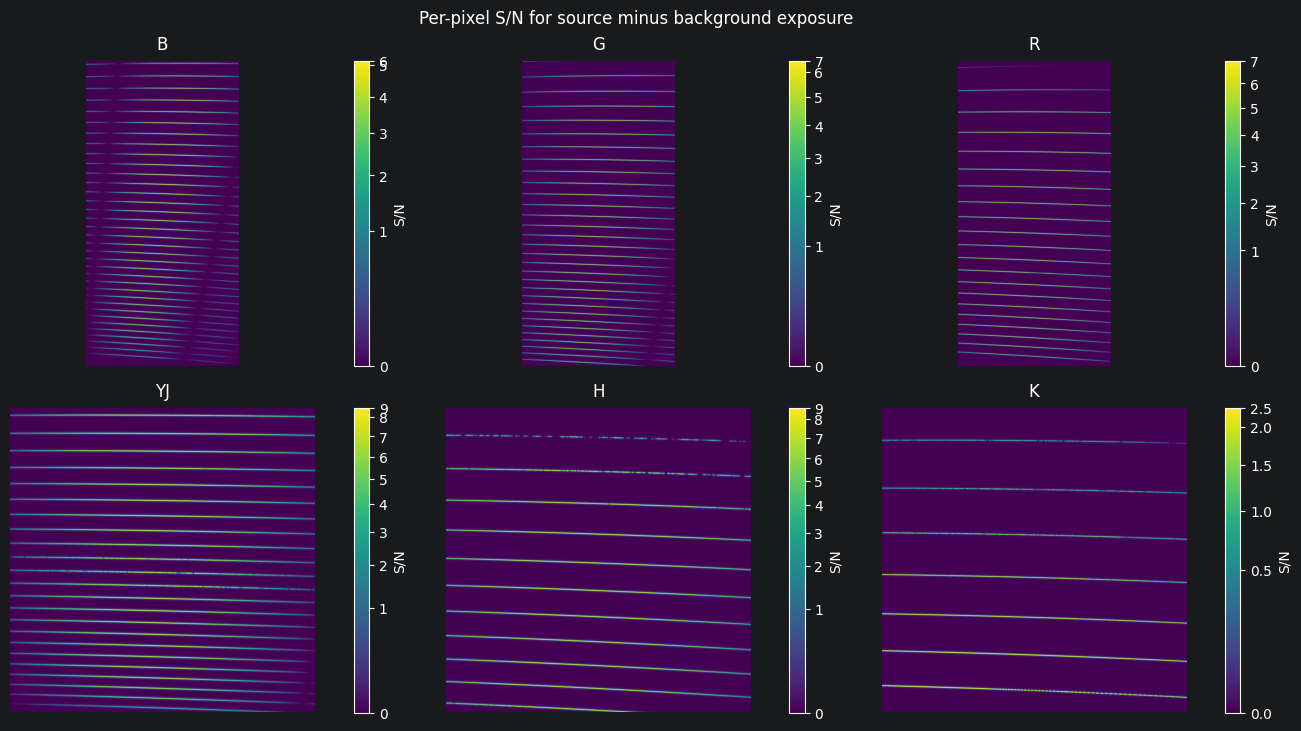

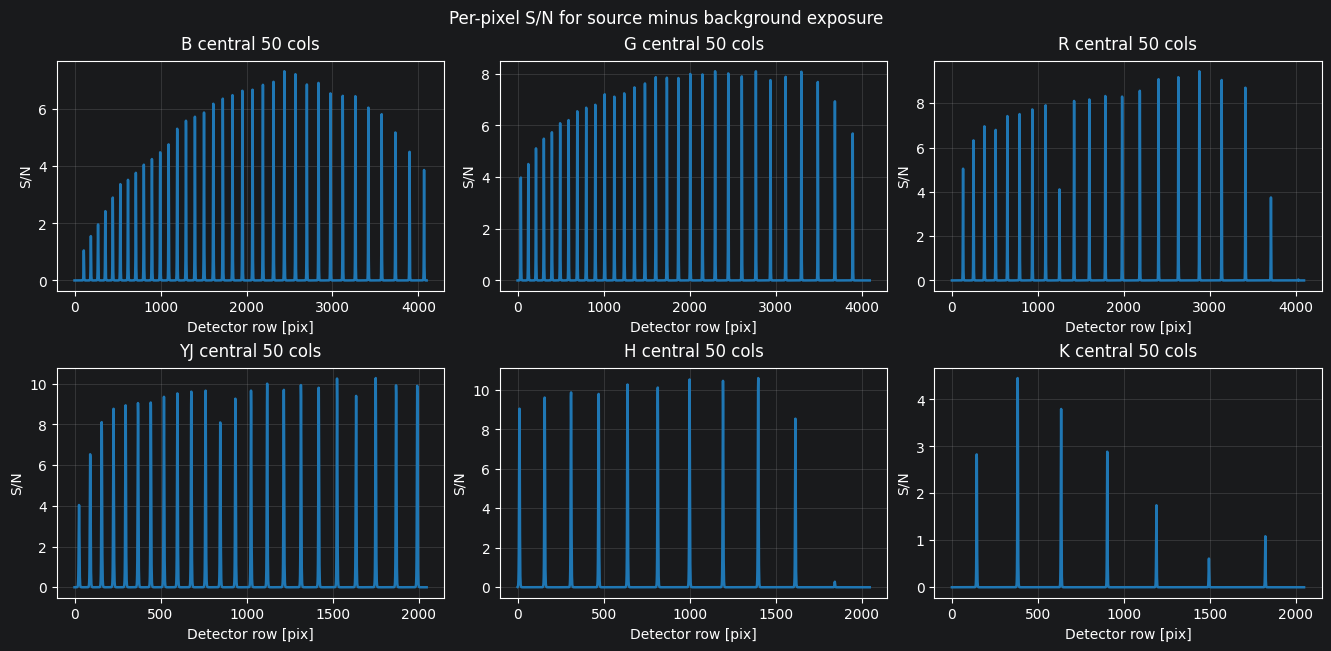

In [34]:
snr_products = show_and_save_hdul(
    snr_images,
    label="source_minus_background_snr_pixel",
    titles=readout_titles,
    output_dir=output_dir,
    show_hdul=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="Per-pixel S/N for source minus background exposure",
    hdul_view=SNR_VIEW,
    cross_dispersion_ylabel="S/N",
)


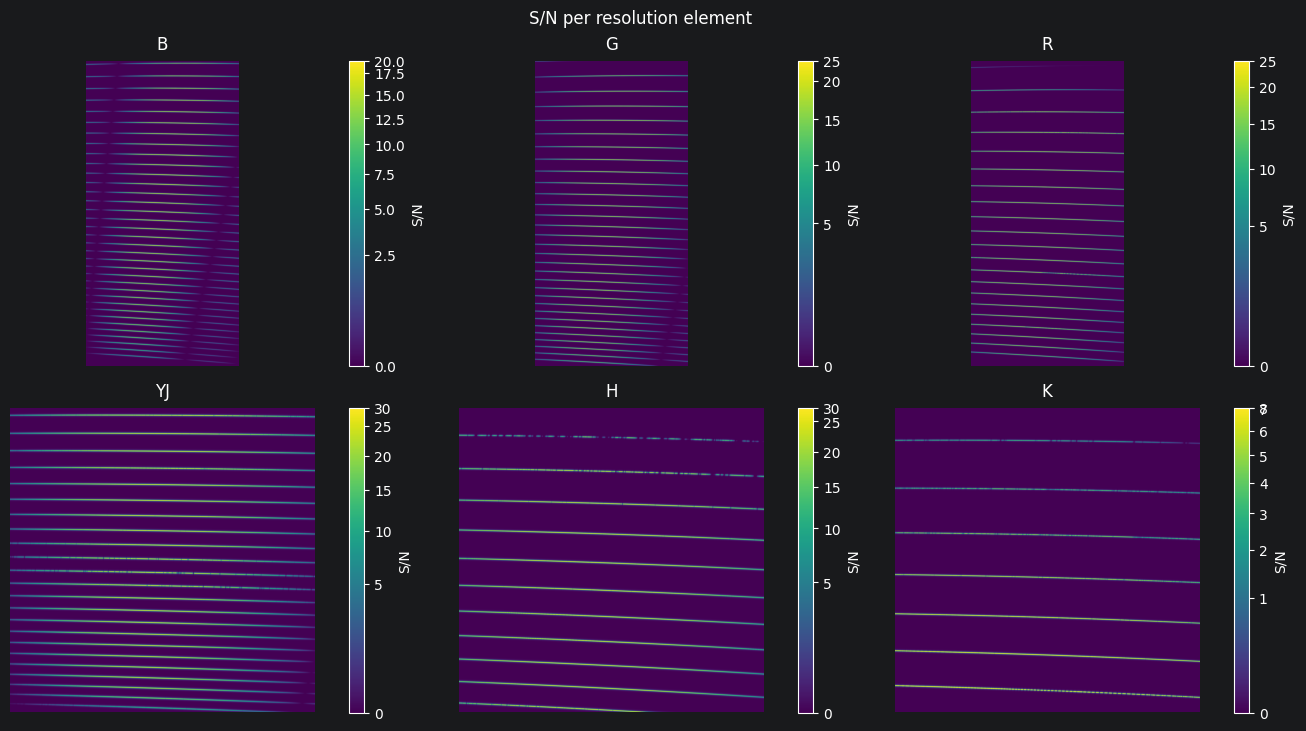

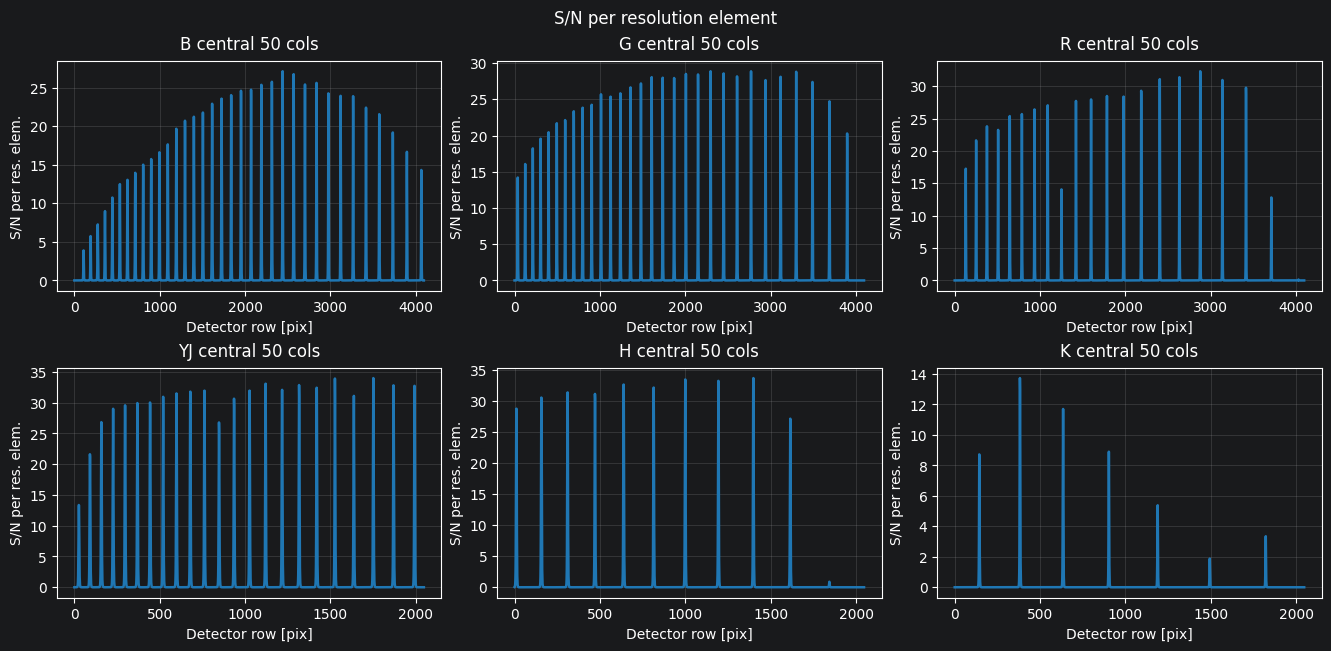

In [35]:
snr_scale_by_channel = {str(row["channel"]): np.sqrt(float(row["eff_pixels_median"])) for row in trace_peak_snr_summary}
resel_snr_images = [snr * snr_scale_by_channel[title] for title, snr in zip(readout_titles, snr_images, strict=True)]

resel_snr_products = show_and_save_hdul(
    resel_snr_images,
    label="source_minus_background_snr_resel",
    titles=readout_titles,
    output_dir=output_dir,
    show_hdul=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="S/N per resolution element",
    hdul_view=SNR_VIEW,
    cross_dispersion_ylabel="S/N per res. elem.",
)

In [36]:
#snr_widget = detector_image_widget(snr_images, readout_titles, SNR_VIEW, value_label="S/N", title="Pixel S/N")

## Trace-Following Zero Point Estimation

This section estimates the one-hour AB magnitude that gives `S/N = 5` after subtracting a matched background exposure. The extraction is a deliberately simple trace-following aperture extraction, not a pipeline optimal extraction. It first calibrates one source center and one spatial aperture width per trace/order from `source_no_sky_lines - background_no_sky_lines`, then applies that fixed aperture to every wavelength sample in the trace.

The aperture is rectangular in trace coordinates, not detector coordinates: it is bounded in wavelength and in the spatial trace coordinate `xi`. Detector pixels remain ordinary rectangular pixels; fractional weights come from subpixel sampling of each detector pixel through the ScopeSim trace transforms. The center estimator uses only wavelength samples with enough source signal, so strongly absorbed or background-dominated chunks do not set the aperture center. The center scatter is reported as a guardrail against the constant-offset assumption failing along an order.

The spatial width is chosen from candidate widths for each trace. The lower bound is `max(spatial FWHM, two local detector pixels projected into xi)`. The upper bound is `min(4 * spatial FWHM, 2 * distance to the nearest slit end from the measured center)`. The selected width is the smallest candidate within a small tolerance of the best median limiting magnitude, so it does not chase faint wings or noise in individual wavelength samples.

The variance follows the observing pair. The science exposure contains source, background, dark current, diffuse detector/background signal, and read noise. The background exposure has the same non-source terms. Background subtraction removes the mean background level but not its variance. For fractional pixel weights, variance terms use `w**2`:

`Var(f) = f * sum(w**2 * source_counts) + fixed_variance`,

where `fixed_variance` is the weighted variance from the background and detector terms in both exposures. Bias is a mean electronic offset and is not a variance term here. The detector terms come from the active ScopeSim detector effects because the current ZShooter readout headers do not carry nominal bias, dark-current, or read-noise cards.

The spectral aperture modes are sorted by resolving power. `native` uses the current trace/slit resolving power, `current_slit_R` rebins another case to the current-slit resolving power, and `R1000` uses `lambda / 1000`. The plotted curves are smoothed only for display; best-per-order markers are selected from the unsmoothed samples.


In [106]:
ZERO_POINT_TARGET_SNR = 5.0
ZERO_POINT_R1000 = 1000.0
ZERO_POINT_SPATIAL_FWHM_SCALE = 1.0
ZERO_POINT_SUBPIXELS = 5
ZERO_POINT_SMOOTH_RESELS = 10
ZERO_POINT_MODE_LABELS = {
    "native": "native R",
    "current_slit_R": "current-slit R",
    "R1000": "R=1000",
}


def trace_id_sort_key(trace_id):
    text = str(trace_id)
    prefix, separator, suffix = text.partition("_")
    try:
        number = int(suffix if separator else text)
    except ValueError:
        number = -1
    return prefix, number, text


def channel_slit_label(vis_slit, nir_slit):
    vis = float(vis_slit)
    nir = float(nir_slit)
    if np.isclose(vis, nir):
        return f'{vis:.2f}" slit'
    return f'{vis:.2f}/{nir:.2f}" slit'


def image_hdu_by_channel(hdul_list, titles):
    return {str(title): (hdu if hasattr(hdu, "data") else hdu[1]) for title, hdu in zip(titles, hdul_list, strict=True)}


def trace_lookup_by_id(train, trace_list_name="trace_list_analytical"):
    trace_list = get_effect(train, trace_list_name)
    return {str(trace_id): trace for trace_id, trace in trace_list.spectral_traces.items()}


def trace_efficiency_spectrographs(train, trace_eff_name="trace_eff_analytical"):
    trace_eff = get_effect(train, trace_eff_name)
    return getattr(trace_eff, "_spectrographs", {}) or {}


def order_effective_wave_bounds_um(trace, spectrographs):
    prefix, _sep, order_text = str(trace.trace_id).partition("_")
    low = float(trace.wave_min)
    high = float(trace.wave_max)
    try:
        order = int(order_text)
        spec = spectrographs[prefix]
        # Use the echelle effect's own free-spectral-range mask. The central-wave/FSR
        # arithmetic below is only a fallback for older or alternate spectrograph objects.
        if hasattr(spec, "order_mask") and hasattr(spec, "orders"):
            grid = np.linspace(low, high, 4096) * u.um
            order_mask = np.asarray(spec.order_mask(grid, fsr_edge=True), dtype=bool)
            order_indices = np.where(np.asarray(spec.orders, dtype=int) == order)[0]
            if order_indices.size:
                mask = order_mask[int(order_indices[0])]
                if np.any(mask):
                    fsr_grid = grid.to_value(u.um)[mask]
                    return max(low, float(np.nanmin(fsr_grid))), min(high, float(np.nanmax(fsr_grid)))
        center = spec.central_wave(order).to_value(u.um)
        fsr = spec.fsr(order).to_value(u.um)
        low = max(low, center - 0.5 * fsr)
        high = min(high, center + 0.5 * fsr)
    except Exception:
        pass
    return low, high


def build_reference_resolution_lookup(trace_samples):
    lookup = {}
    if trace_samples is None or len(trace_samples) == 0:
        return lookup
    channels = np.asarray(trace_samples["channel"], dtype=str)
    traces = np.asarray(trace_samples["trace_id"], dtype=str)
    for channel in sorted(set(channels)):
        channel_mask = channels == channel
        for trace_id in sorted(set(traces[channel_mask]), key=trace_id_sort_key):
            rows = trace_samples[channel_mask & (traces == trace_id)]
            order = np.argsort(np.asarray(rows["wave_nm"], dtype=float))
            lookup[(channel, trace_id)] = (
                np.asarray(rows["wave_nm"], dtype=float)[order],
                np.asarray(rows["resolving_power_R"], dtype=float)[order],
            )
    return lookup


def resolving_power_from_reference(sample, reference_lookup):
    channel = str(sample["channel"])
    trace_id = str(sample["trace_id"])
    wave = float(sample["wave_nm"])
    if (channel, trace_id) in reference_lookup:
        waves, values = reference_lookup[(channel, trace_id)]
    else:
        candidates = [item for (candidate_channel, _trace_id), item in reference_lookup.items() if candidate_channel == channel]
        if not candidates:
            return np.nan
        waves = np.concatenate([item[0] for item in candidates])
        values = np.concatenate([item[1] for item in candidates])
        order = np.argsort(waves)
        waves = waves[order]
        values = values[order]
    finite = np.isfinite(waves) & np.isfinite(values)
    if np.count_nonzero(finite) < 2:
        return np.nan
    return float(np.interp(wave, waves[finite], values[finite], left=np.nan, right=np.nan))


def resolution_width_for_mode(sample, mode, *, target_R=ZERO_POINT_R1000, reference_lookup=None):
    wave_nm = float(sample["wave_nm"])
    if mode == "native":
        resolution_width_nm = float(sample["spectral_fwhm_pix"] * sample["dispersion_nm_pix"])
        extraction_R = wave_nm / resolution_width_nm
    elif mode == "current_slit_R":
        extraction_R = resolving_power_from_reference(sample, reference_lookup or {})
    elif mode == "R1000":
        extraction_R = float(target_R)
    else:
        raise ValueError(f"Unknown zero-point extraction mode {mode!r}.")
    if mode != "native":
        resolution_width_nm = wave_nm / extraction_R if np.isfinite(extraction_R) and extraction_R > 0 else np.nan
    return float(resolution_width_nm), float(extraction_R)


TRACE_APERTURE_CENTER_SNR_MIN = 4.0
TRACE_APERTURE_WIDTH_SNR_MIN = 3.0
TRACE_APERTURE_MIN_GOOD_SAMPLES = 3
TRACE_APERTURE_MAX_CALIBRATION_SAMPLES = 9
TRACE_APERTURE_CENTER_GRID_MAX = 81
TRACE_APERTURE_WIDTH_GRID_SAMPLES = 25
TRACE_APERTURE_WIDTH_TOL_MAG = 0.03
TRACE_APERTURE_CENTER_SEARCH_HALF_WIDTH_ARCSEC = 1.5
TRACE_APERTURE_CENTER_WIDTH_FWHM = 2.0
TRACE_APERTURE_MAX_WIDTH_FWHM = 4.0
TRACE_APERTURE_MIN_WIDTH_PIXELS = 2.0
TRACE_APERTURE_PRACTICAL_MAX_ARCSEC = np.inf


def trace_sample_coordinate_cutout(
    trace,
    image_hdu,
    sample,
    *,
    resolution_width_nm,
    wave_bounds_um,
    xi_bounds_arcsec=None,
    xi_center_arcsec=0.0,
    spatial_width_arcsec=None,
    subpixels=ZERO_POINT_SUBPIXELS,
):
    from astropy.wcs import WCS

    if not np.isfinite(resolution_width_nm) or resolution_width_nm <= 0:
        return None
    wave_center_um = float(sample["wave_nm"]) / 1000.0
    half_wave_um = 0.5 * float(resolution_width_nm) / 1000.0
    wave_low = max(float(wave_bounds_um[0]), wave_center_um - half_wave_um)
    wave_high = min(float(wave_bounds_um[1]), wave_center_um + half_wave_um)
    if not np.isfinite(wave_low) or not np.isfinite(wave_high) or wave_high <= wave_low:
        return None

    if xi_bounds_arcsec is None:
        if spatial_width_arcsec is None or not np.isfinite(spatial_width_arcsec) or spatial_width_arcsec <= 0:
            return None
        half_spatial = 0.5 * float(spatial_width_arcsec)
        xi_low = float(xi_center_arcsec) - half_spatial
        xi_high = float(xi_center_arcsec) + half_spatial
    else:
        xi_low, xi_high = [float(value) for value in xi_bounds_arcsec]
    if not np.isfinite(xi_low) or not np.isfinite(xi_high) or xi_high <= xi_low:
        return None

    xi_edges = np.array([xi_low, 0.5 * (xi_low + xi_high), xi_high], dtype=float)
    wave_edges = np.array([wave_low, wave_center_um, wave_high], dtype=float)
    xi_grid, wave_grid = np.meshgrid(xi_edges, wave_edges, indexing="ij")
    x_mm = np.asarray(trace.xilam2x(xi_grid, wave_grid), dtype=float)
    y_mm = np.asarray(trace.xilam2y(xi_grid, wave_grid), dtype=float)
    wcs_d = WCS(image_hdu.header, key="D")
    x_pix, y_pix = wcs_d.all_world2pix(x_mm.ravel(), y_mm.ravel(), 0)
    finite = np.isfinite(x_pix) & np.isfinite(y_pix)
    if not np.any(finite):
        return None

    height, width = image_hdu.data.shape
    pad = max(3, int(np.ceil(float(subpixels) / 2)) + 1)
    x0 = max(0, int(np.floor(np.nanmin(x_pix[finite]))) - pad)
    x1 = min(width, int(np.ceil(np.nanmax(x_pix[finite]))) + pad + 1)
    y0 = max(0, int(np.floor(np.nanmin(y_pix[finite]))) - pad)
    y1 = min(height, int(np.ceil(np.nanmax(y_pix[finite]))) + pad + 1)
    if x1 <= x0 or y1 <= y0:
        return None

    y_indices, x_indices = np.mgrid[y0:y1, x0:x1]
    offsets = (np.arange(int(subpixels), dtype=float) + 0.5) / float(subpixels) - 0.5
    dx, dy = np.meshgrid(offsets, offsets, indexing="xy")
    x_sub = x_indices[..., None] + dx.ravel()
    y_sub = y_indices[..., None] + dy.ravel()
    x_mm_sub, y_mm_sub = wcs_d.all_pix2world(x_sub.ravel(), y_sub.ravel(), 0)
    lam = np.asarray(trace.xy2lam(x_mm_sub, y_mm_sub), dtype=float).reshape(x_sub.shape)
    xi = np.asarray(trace.xy2xi(x_mm_sub, y_mm_sub), dtype=float).reshape(x_sub.shape)
    valid = np.isfinite(lam) & np.isfinite(xi) & (lam >= wave_low) & (lam <= wave_high)
    return {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "lam_um": lam,
        "xi_arcsec": xi,
        "valid_subpixels": valid,
        "wave_low_um": wave_low,
        "wave_high_um": wave_high,
        "xi_low_arcsec": xi_low,
        "xi_high_arcsec": xi_high,
    }


def trace_coordinate_weights(cutout, xi_center_arcsec, spatial_width_arcsec):
    centers = np.asarray(xi_center_arcsec, dtype=float)
    widths = np.asarray(spatial_width_arcsec, dtype=float)
    scalar = centers.ndim == 0 and widths.ndim == 0
    centers, widths = np.broadcast_arrays(centers, widths)
    lower = (centers - 0.5 * widths).ravel()
    upper = (centers + 0.5 * widths).ravel()
    xi = cutout["xi_arcsec"]
    valid = cutout["valid_subpixels"]
    inside = (
        valid[..., None]
        & (xi[..., None] >= lower[None, None, None, :])
        & (xi[..., None] <= upper[None, None, None, :])
    )
    weights = inside.mean(axis=2).astype(float)
    if scalar:
        return weights[..., 0]
    return weights.reshape((*weights.shape[:2], *centers.shape))


def trace_sample_weight_cutout(
    trace,
    image_hdu,
    sample,
    *,
    resolution_width_nm,
    spatial_width_arcsec,
    wave_bounds_um,
    xi_center_arcsec=0.0,
    subpixels=ZERO_POINT_SUBPIXELS,
):
    cutout = trace_sample_coordinate_cutout(
        trace,
        image_hdu,
        sample,
        resolution_width_nm=resolution_width_nm,
        spatial_width_arcsec=spatial_width_arcsec,
        xi_center_arcsec=xi_center_arcsec,
        wave_bounds_um=wave_bounds_um,
        subpixels=subpixels,
    )
    if cutout is None:
        return None
    weights = trace_coordinate_weights(cutout, xi_center_arcsec, spatial_width_arcsec)
    if not np.any(weights > 0):
        return None
    return {
        "x0": cutout["x0"],
        "x1": cutout["x1"],
        "y0": cutout["y0"],
        "y1": cutout["y1"],
        "weights": weights,
        "wave_low_um": cutout["wave_low_um"],
        "wave_high_um": cutout["wave_high_um"],
        "xi_center_arcsec": float(xi_center_arcsec),
        "spatial_width_arcsec": float(spatial_width_arcsec),
    }


def readout_signal_background_products(source_hdul, background_hdul, detector_table, titles):
    terms_by_channel = {str(row["channel"]): detector_terms_from_row(row) for row in detector_table}
    products = {}
    for title, source_hdu, background_hdu in zip(titles, source_hdul, background_hdul, strict=True):
        title = str(title)
        terms = terms_by_channel[title]
        source_image = readout_image(source_hdu)
        background_image = readout_image(background_hdu)
        signal = np.asarray(source_image - background_image, dtype=float)
        background = np.clip(
            np.asarray(background_image - terms["bias_e_pix"] - terms["mean_detector_signal_e_pix"], dtype=float),
            0,
            None,
        )
        products[title] = {
            "signal": signal,
            "source_variance_unit": np.clip(signal, 0, None),
            "background": background,
            "one_exposure_fixed_variance": background + terms["detector_variance_e2_pix"],
            "detector_variance_e2_pix": terms["detector_variance_e2_pix"],
        }
    return products


def _sum_weighted_pixels(values, weights):
    return np.tensordot(
        np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0),
        np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0),
        axes=([0, 1], [0, 1]),
    )


def _scalar_or_array(values):
    values = np.asarray(values)
    return float(values) if values.ndim == 0 else values


def extract_products_from_weights(products, cutout, weights):
    y0, y1 = cutout["y0"], cutout["y1"]
    x0, x1 = cutout["x0"], cutout["x1"]
    weights = np.asarray(weights, dtype=float)
    weights2 = weights**2
    signal_cut = products["signal"][y0:y1, x0:x1]
    source_var_cut = products["source_variance_unit"][y0:y1, x0:x1]
    background_cut = products["background"][y0:y1, x0:x1]
    fixed_one_cut = products["one_exposure_fixed_variance"][y0:y1, x0:x1]
    signal_e = _sum_weighted_pixels(signal_cut, weights)
    source_var_e = _sum_weighted_pixels(source_var_cut, weights2)
    background_e = _sum_weighted_pixels(background_cut, weights)
    background_var_e = 2.0 * _sum_weighted_pixels(background_cut, weights2)
    variance_pixels = np.sum(weights2 > 0, axis=(0, 1)) * 0.0 + np.sum(weights2, axis=(0, 1))
    weighted_pixels = np.sum(weights, axis=(0, 1))
    n_pix = np.count_nonzero(weights > 0, axis=(0, 1))
    detector_var_e = 2.0 * variance_pixels * float(products["detector_variance_e2_pix"])
    fixed_variance_e = 2.0 * _sum_weighted_pixels(fixed_one_cut, weights2)
    variance_at_input = np.clip(source_var_e, 0, None) + np.clip(fixed_variance_e, 0, None)
    snr_at_input = np.divide(
        signal_e,
        np.sqrt(variance_at_input),
        out=np.full_like(np.asarray(signal_e, dtype=float), np.nan, dtype=float),
        where=variance_at_input > 0,
    )
    return {
        "n_pix": _scalar_or_array(n_pix),
        "weighted_pixels": _scalar_or_array(weighted_pixels),
        "variance_pixels": _scalar_or_array(variance_pixels),
        "signal_e": _scalar_or_array(signal_e),
        "source_var_e": _scalar_or_array(source_var_e),
        "background_e": _scalar_or_array(background_e),
        "background_var_e": _scalar_or_array(background_var_e),
        "detector_var_e": _scalar_or_array(detector_var_e),
        "fixed_variance_e": _scalar_or_array(fixed_variance_e),
        "snr_at_input": _scalar_or_array(snr_at_input),
    }


def extract_weighted_trace_aperture(products, cutout):
    return extract_products_from_weights(products, cutout, cutout["weights"])


def extract_image_from_weights(image, cutout, weights):
    y0, y1 = cutout["y0"], cutout["y1"]
    x0, x1 = cutout["x0"], cutout["x1"]
    image_cut = np.asarray(image[y0:y1, x0:x1], dtype=float)
    weights = np.asarray(weights, dtype=float)
    flux = _sum_weighted_pixels(image_cut, weights)
    return {
        "flux": _scalar_or_array(flux),
        "weighted_pixels": _scalar_or_array(np.sum(weights, axis=(0, 1))),
        "variance_pixels": _scalar_or_array(np.sum(weights**2, axis=(0, 1))),
        "n_pix": _scalar_or_array(np.count_nonzero(weights > 0, axis=(0, 1))),
    }


def flux_scale_for_target_snr(source_signal_e, source_variance_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    source_signal_e = float(source_signal_e)
    source_variance_e = max(float(source_variance_e), 0.0)
    fixed_variance_e = max(float(fixed_variance_e), 0.0)
    target_snr = float(target_snr)
    if not np.isfinite(source_signal_e) or source_signal_e <= 0 or not np.isfinite(fixed_variance_e):
        return np.nan
    q2 = target_snr**2
    discriminant = (q2 * source_variance_e)**2 + 4.0 * source_signal_e**2 * q2 * fixed_variance_e
    return float((q2 * source_variance_e + np.sqrt(discriminant)) / (2.0 * source_signal_e**2))


def limiting_abmag_for_target_snr(input_abmag, source_signal_e, source_variance_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    scale = flux_scale_for_target_snr(source_signal_e, source_variance_e, fixed_variance_e, target_snr=target_snr)
    if not np.isfinite(scale) or scale <= 0:
        return np.nan
    return float(input_abmag - 2.5 * np.log10(scale))


def robust_mad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    med = np.nanmedian(values)
    return float(1.4826 * np.nanmedian(np.abs(values - med)))


def trace_slit_bounds_arcsec(order_samples):
    if {"footprint_slit_min_arcsec", "footprint_slit_max_arcsec"}.issubset(order_samples.colnames):
        low = np.asarray(order_samples["footprint_slit_min_arcsec"], dtype=float)
        high = np.asarray(order_samples["footprint_slit_max_arcsec"], dtype=float)
        finite = np.isfinite(low) & np.isfinite(high)
        if np.any(finite):
            return float(np.nanmin(low[finite])), float(np.nanmax(high[finite]))
    return -5.0, 5.0


def local_xi_pixel_scale_arcsec(trace, image_hdu, sample):
    return float(sample["pixel_scale_arcsec_pix"])


def select_trace_calibration_samples(order_samples, wave_bounds_um, *, max_samples=TRACE_APERTURE_MAX_CALIBRATION_SAMPLES):
    if len(order_samples) == 0:
        return order_samples
    waves_um = np.asarray(order_samples["wave_nm"], dtype=float) / 1000.0
    order = np.argsort(waves_um)
    waves_um = waves_um[order]
    low, high = [float(value) for value in wave_bounds_um]
    in_bounds = np.isfinite(waves_um) & (waves_um >= low) & (waves_um <= high)
    if np.count_nonzero(in_bounds) >= max(4, min(max_samples, len(order_samples) // 3)):
        span = high - low
        interior = in_bounds & (waves_um >= low + 0.06 * span) & (waves_um <= high - 0.06 * span)
        if np.count_nonzero(interior) >= min(4, np.count_nonzero(in_bounds)):
            in_bounds = interior
    indices = order[np.flatnonzero(in_bounds)]
    if indices.size == 0:
        indices = order
    if indices.size > max_samples:
        pick = np.unique(np.round(np.linspace(0, indices.size - 1, max_samples)).astype(int))
        indices = indices[pick]
    return order_samples[indices]


def aperture_width_limits(center_arcsec, fwhm_arcsec, xi_pixel_arcsec, xi_min_arcsec, xi_max_arcsec, *, practical_cap=TRACE_APERTURE_PRACTICAL_MAX_ARCSEC):
    min_width = max(float(fwhm_arcsec), TRACE_APERTURE_MIN_WIDTH_PIXELS * float(xi_pixel_arcsec))
    edge_distance = min(float(center_arcsec) - float(xi_min_arcsec), float(xi_max_arcsec) - float(center_arcsec))
    edge_width = 2.0 * edge_distance
    max_width = min(TRACE_APERTURE_MAX_WIDTH_FWHM * float(fwhm_arcsec), edge_width, float(practical_cap))
    status = "ok"
    if not np.isfinite(edge_width) or edge_width <= 0:
        status = "center_outside_slit_bounds"
        max_width = min_width
    elif max_width < min_width:
        status = "slit_edge_limited_below_min_width"
        max_width = max(edge_width, np.finfo(float).eps)
    return float(min_width), float(max_width), float(edge_width), status


def center_grid_for_trace(xi_min, xi_max, fwhm, xi_pixel, *, expected_center=0.0, center_width=None):
    center_width = max(TRACE_APERTURE_CENTER_WIDTH_FWHM * fwhm, 4.0 * xi_pixel) if center_width is None else center_width
    half_search = max(TRACE_APERTURE_CENTER_SEARCH_HALF_WIDTH_ARCSEC, 4.0 * fwhm)
    low = max(xi_min + 0.5 * center_width, expected_center - half_search)
    high = min(xi_max - 0.5 * center_width, expected_center + half_search)
    if not np.isfinite(low) or not np.isfinite(high) or high <= low:
        return np.array([expected_center], dtype=float), center_width
    step = max(0.25 * fwhm, xi_pixel)
    n_grid = int(np.ceil((high - low) / step)) + 1 if np.isfinite(step) and step > 0 else 21
    n_grid = max(9, min(TRACE_APERTURE_CENTER_GRID_MAX, n_grid))
    return np.linspace(low, high, n_grid), center_width


def estimate_trace_center(
    products,
    trace,
    image_hdu,
    order_samples,
    *,
    wave_bounds_um,
    xi_bounds_arcsec,
    reference_lookup,
    expected_center_arcsec=0.0,
    subpixels=ZERO_POINT_SUBPIXELS,
):
    cal_samples = select_trace_calibration_samples(order_samples, wave_bounds_um)
    if len(cal_samples) == 0:
        return {"xi_center_arcsec": float(expected_center_arcsec), "center_status": "fallback_no_samples", "center_good_samples": 0}

    fwhm_values = np.asarray(cal_samples["seeing_fwhm_arcsec"], dtype=float)
    fwhm_med = float(np.nanmedian(fwhm_values[np.isfinite(fwhm_values)]))
    xi_pix_values = np.array([local_xi_pixel_scale_arcsec(trace, image_hdu, sample) for sample in cal_samples], dtype=float)
    xi_pix_med = float(np.nanmedian(xi_pix_values[np.isfinite(xi_pix_values)]))
    if not np.isfinite(xi_pix_med) or xi_pix_med <= 0:
        xi_pix_med = max(fwhm_med / 4.0, 0.01)
    xi_min, xi_max = xi_bounds_arcsec
    centers, center_width = center_grid_for_trace(
        xi_min,
        xi_max,
        fwhm_med,
        xi_pix_med,
        expected_center=expected_center_arcsec,
    )

    rows = []
    for sample in cal_samples:
        resolution_width_nm, _extraction_R = resolution_width_for_mode(sample, "native", reference_lookup=reference_lookup)
        xi_low = float(np.nanmin(centers)) - 0.5 * center_width
        xi_high = float(np.nanmax(centers)) + 0.5 * center_width
        cutout = trace_sample_coordinate_cutout(
            trace,
            image_hdu,
            sample,
            resolution_width_nm=resolution_width_nm,
            wave_bounds_um=wave_bounds_um,
            xi_bounds_arcsec=(xi_low, xi_high),
            subpixels=subpixels,
        )
        if cutout is None:
            continue
        weights = trace_coordinate_weights(cutout, centers, center_width)
        extraction = extract_products_from_weights(products, cutout, weights)
        signal = np.asarray(extraction["signal_e"], dtype=float)
        snr = np.asarray(extraction["snr_at_input"], dtype=float)
        valid = np.isfinite(signal) & np.isfinite(snr) & (signal > 0)
        if not np.any(valid):
            continue
        valid_scores = np.where(valid, snr, -np.inf)
        best_index = int(np.nanargmax(valid_scores))
        rows.append({
            "sample_index": int(sample["sample_index"]),
            "wave_nm": float(sample["wave_nm"]),
            "center_arcsec": float(centers[best_index]),
            "snr": float(snr[best_index]),
            "signal_e": float(signal[best_index]),
        })

    if not rows:
        return {
            "xi_center_arcsec": float(expected_center_arcsec),
            "center_status": "fallback_no_finite_center_samples",
            "center_good_samples": 0,
            "spatial_fwhm_arcsec": fwhm_med,
            "xi_pixel_arcsec": xi_pix_med,
            "center_scatter_arcsec": np.nan,
        }

    frame = pd.DataFrame(rows).sort_values("wave_nm")
    good = frame["snr"].to_numpy(dtype=float) >= TRACE_APERTURE_CENTER_SNR_MIN
    status = "ok"
    if np.count_nonzero(good) < TRACE_APERTURE_MIN_GOOD_SAMPLES:
        status = "low_snr_center_estimate"
        finite = np.isfinite(frame["snr"].to_numpy(dtype=float)) & (frame["signal_e"].to_numpy(dtype=float) > 0)
        order = np.argsort(frame.loc[finite, "snr"].to_numpy(dtype=float))[::-1] if np.any(finite) else []
        finite_indices = np.flatnonzero(finite)
        good = np.zeros(len(frame), dtype=bool)
        if len(finite_indices):
            good[finite_indices[order[:max(TRACE_APERTURE_MIN_GOOD_SAMPLES, min(len(finite_indices), len(frame)))]]] = True
    centers_good = frame.loc[good, "center_arcsec"].to_numpy(dtype=float)
    xi_center = float(np.nanmedian(centers_good)) if centers_good.size else float(expected_center_arcsec)

    chunk_centers = []
    if np.count_nonzero(good) >= 4:
        good_frame = frame.loc[good].sort_values("wave_nm").reset_index(drop=True)
        for chunk_index in np.array_split(np.arange(len(good_frame)), min(4, len(good_frame))):
            if len(chunk_index):
                chunk_centers.append(float(np.nanmedian(good_frame.iloc[chunk_index]["center_arcsec"].to_numpy(dtype=float))))
    scatter = robust_mad(chunk_centers if chunk_centers else centers_good)
    allowed_scatter = max(0.25 * fwhm_med, 2.0 * xi_pix_med)
    if np.isfinite(scatter) and scatter > allowed_scatter:
        status = f"{status}; variable_center_warning" if status != "ok" else "variable_center_warning"

    return {
        "xi_center_arcsec": xi_center,
        "center_status": status,
        "center_good_samples": int(np.count_nonzero(good)),
        "center_total_samples": int(len(frame)),
        "center_scatter_arcsec": float(scatter) if np.isfinite(scatter) else np.nan,
        "center_allowed_scatter_arcsec": float(allowed_scatter),
        "spatial_fwhm_arcsec": fwhm_med,
        "xi_pixel_arcsec": xi_pix_med,
        "center_sample_indices": tuple(int(value) for value in frame.loc[good, "sample_index"].to_numpy(dtype=int)),
        "center_width_arcsec": float(center_width),
    }


def choose_trace_aperture_width(
    products,
    trace,
    image_hdu,
    order_samples,
    *,
    wave_bounds_um,
    xi_bounds_arcsec,
    reference_lookup,
    center_info,
    input_abmag,
    target_snr=ZERO_POINT_TARGET_SNR,
    subpixels=ZERO_POINT_SUBPIXELS,
):
    xi_center = float(center_info["xi_center_arcsec"])
    fwhm = float(center_info.get("spatial_fwhm_arcsec", np.nan))
    xi_pixel = float(center_info.get("xi_pixel_arcsec", np.nan))
    if not np.isfinite(fwhm) or fwhm <= 0:
        fwhm = float(np.nanmedian(np.asarray(order_samples["seeing_fwhm_arcsec"], dtype=float)))
    if not np.isfinite(xi_pixel) or xi_pixel <= 0:
        xi_pixel = max(fwhm / 4.0, 0.01)
    xi_min, xi_max = xi_bounds_arcsec
    min_width, max_width, edge_width, limit_status = aperture_width_limits(xi_center, fwhm, xi_pixel, xi_min, xi_max)
    if not np.isfinite(max_width) or max_width <= 0:
        max_width = min_width
    if max_width <= min_width:
        widths = np.array([max_width], dtype=float)
    else:
        widths = np.linspace(min_width, max_width, TRACE_APERTURE_WIDTH_GRID_SAMPLES)

    cal_samples = select_trace_calibration_samples(order_samples, wave_bounds_um)
    good_indices = set(center_info.get("center_sample_indices", ()))
    if good_indices:
        keep = np.array([int(sample["sample_index"]) in good_indices for sample in cal_samples], dtype=bool)
        if np.count_nonzero(keep) >= TRACE_APERTURE_MIN_GOOD_SAMPLES:
            cal_samples = cal_samples[keep]

    m5_rows = []
    for sample in cal_samples:
        resolution_width_nm, _extraction_R = resolution_width_for_mode(sample, "native", reference_lookup=reference_lookup)
        cutout = trace_sample_coordinate_cutout(
            trace,
            image_hdu,
            sample,
            resolution_width_nm=resolution_width_nm,
            wave_bounds_um=wave_bounds_um,
            xi_bounds_arcsec=(xi_center - 0.5 * max_width, xi_center + 0.5 * max_width),
            subpixels=subpixels,
        )
        if cutout is None:
            continue
        weights = trace_coordinate_weights(cutout, xi_center, widths)
        extraction = extract_products_from_weights(products, cutout, weights)
        signal = np.asarray(extraction["signal_e"], dtype=float)
        source_var = np.asarray(extraction["source_var_e"], dtype=float)
        fixed_var = np.asarray(extraction["fixed_variance_e"], dtype=float)
        snr = np.asarray(extraction["snr_at_input"], dtype=float)
        quality = np.isfinite(signal[-1]) and signal[-1] > 0 and np.isfinite(snr[-1]) and snr[-1] >= TRACE_APERTURE_WIDTH_SNR_MIN
        if not quality:
            continue
        m5_rows.append([
            limiting_abmag_for_target_snr(input_abmag, s, sv, fv, target_snr=target_snr)
            for s, sv, fv in zip(signal, source_var, fixed_var, strict=True)
        ])

    status = limit_status
    if not m5_rows:
        width = float(max(min_width, min(max_width, TRACE_APERTURE_CENTER_WIDTH_FWHM * fwhm)))
        status = f"{status}; fallback_no_width_samples" if status != "ok" else "fallback_no_width_samples"
        return {
            "spatial_width_arcsec": width,
            "width_status": status,
            "width_good_samples": 0,
            "width_min_arcsec": float(min_width),
            "width_max_arcsec": float(max_width),
            "width_edge_limit_arcsec": float(edge_width),
            "width_best_m5_ab": np.nan,
            "width_selected_m5_ab": np.nan,
            "width_m5_penalty_mag": np.nan,
        }

    m5_grid = np.asarray(m5_rows, dtype=float)
    median_m5 = np.nanmedian(m5_grid, axis=0)
    if not np.any(np.isfinite(median_m5)):
        best_idx = selected_idx = 0
    else:
        best_idx = int(np.nanargmax(median_m5))
        best_m5 = float(median_m5[best_idx])
        candidate = np.flatnonzero(median_m5 >= best_m5 - TRACE_APERTURE_WIDTH_TOL_MAG)
        selected_idx = int(candidate[0]) if candidate.size else best_idx
    return {
        "spatial_width_arcsec": float(widths[selected_idx]),
        "width_status": status,
        "width_good_samples": int(len(m5_rows)),
        "width_min_arcsec": float(min_width),
        "width_max_arcsec": float(max_width),
        "width_edge_limit_arcsec": float(edge_width),
        "width_best_m5_ab": float(median_m5[best_idx]) if np.isfinite(median_m5[best_idx]) else np.nan,
        "width_selected_m5_ab": float(median_m5[selected_idx]) if np.isfinite(median_m5[selected_idx]) else np.nan,
        "width_m5_penalty_mag": float(median_m5[best_idx] - median_m5[selected_idx]) if np.isfinite(median_m5[best_idx]) and np.isfinite(median_m5[selected_idx]) else np.nan,
    }


def trace_aperture_lookup(aperture_calibration):
    if aperture_calibration is None:
        return {}
    if isinstance(aperture_calibration, dict):
        return aperture_calibration
    lookup = {}
    colnames = getattr(aperture_calibration, "colnames", [])
    for row in aperture_calibration:
        lookup[(str(row["channel"]), str(row["trace_id"]))] = {name: row[name] for name in colnames}
    return lookup


def calibrate_trace_apertures(
    train,
    source_hdul,
    background_hdul,
    detector_table,
    trace_samples,
    titles,
    *,
    input_abmag,
    target_snr=ZERO_POINT_TARGET_SNR,
    subpixels=ZERO_POINT_SUBPIXELS,
    reference_trace_samples=None,
):
    products_by_channel = readout_signal_background_products(source_hdul, background_hdul, detector_table, titles)
    image_hdus = image_hdu_by_channel(background_hdul, titles)
    traces = trace_lookup_by_id(train)
    spectrographs = trace_efficiency_spectrographs(train)
    reference_lookup = build_reference_resolution_lookup(reference_trace_samples)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    apertures = {}
    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            trace_id = str(trace_id)
            trace = traces[trace_id]
            order_samples = channel_samples[trace_values == trace_id]
            order_samples = order_samples[np.argsort(np.asarray(order_samples["wave_nm"], dtype=float))]
            wave_bounds_um = order_effective_wave_bounds_um(trace, spectrographs)
            xi_bounds = trace_slit_bounds_arcsec(order_samples)
            center_info = estimate_trace_center(
                products_by_channel[channel],
                trace,
                image_hdus[channel],
                order_samples,
                wave_bounds_um=wave_bounds_um,
                xi_bounds_arcsec=xi_bounds,
                reference_lookup=reference_lookup,
                subpixels=subpixels,
            )
            width_info = choose_trace_aperture_width(
                products_by_channel[channel],
                trace,
                image_hdus[channel],
                order_samples,
                wave_bounds_um=wave_bounds_um,
                xi_bounds_arcsec=xi_bounds,
                reference_lookup=reference_lookup,
                center_info=center_info,
                input_abmag=input_abmag,
                target_snr=target_snr,
                subpixels=subpixels,
            )
            apertures[(channel, trace_id)] = {
                "channel": channel,
                "trace_id": trace_id,
                "wave_low_nm": float(wave_bounds_um[0] * 1000.0),
                "wave_high_nm": float(wave_bounds_um[1] * 1000.0),
                "xi_min_arcsec": float(xi_bounds[0]),
                "xi_max_arcsec": float(xi_bounds[1]),
                **center_info,
                **width_info,
            }
    return apertures


def trace_aperture_calibration_table(apertures):
    rows = list(trace_aperture_lookup(apertures).values())
    if not rows:
        return Table(rows=[])
    table = Table(rows=rows)
    order = np.lexsort((
        np.asarray(table["wave_low_nm"], dtype=float),
        np.asarray(table["trace_id"], dtype=str),
        np.asarray(table["channel"], dtype=str),
    ))
    return table[order]


def trace_aperture_quality_summary(apertures, titles=None):
    table = trace_aperture_calibration_table(apertures)
    if len(table) == 0:
        return []
    frame = table.to_pandas()
    channels = list(titles) if titles is not None else list(dict.fromkeys(frame["channel"]))
    rows = []
    for channel in channels:
        group = frame[frame["channel"] == channel]
        if len(group) == 0:
            continue
        statuses = (group["center_status"].astype(str) + "; " + group["width_status"].astype(str)).to_numpy()
        warnings = [status for status in statuses if status.replace("ok", "").replace(";", "").strip()]
        rows.append({
            "ch": channel,
            "traces": len(group),
            "xi_center": compact_range(float(np.nanmin(group["xi_center_arcsec"])), float(np.nanmax(group["xi_center_arcsec"])), 3),
            "width": compact_range(float(np.nanmin(group["spatial_width_arcsec"])), float(np.nanmax(group["spatial_width_arcsec"])), 3),
            "center_scatter_max": float(np.nanmax(group["center_scatter_arcsec"])),
            "width_penalty_max": float(np.nanmax(group["width_m5_penalty_mag"])),
            "warnings": len(warnings),
        })
    return rows


def centered_integer_pixel_bounds(center_pix, width_pix):
    lower = int(np.floor(float(center_pix) - 0.5 * (int(width_pix) - 1) + 0.5))
    return lower, lower + int(width_pix)


def native_detector_rectangle(sample, coordinate, image_shape, spatial_width_arcsec):
    x0, x1 = int(sample["detector_x0_pix"]), int(sample["detector_x1_pix"])
    spatial_width_pix = max(1, int(np.rint(spatial_width_arcsec / float(sample["pixel_scale_arcsec_pix"]))))
    y0, y1 = centered_integer_pixel_bounds(coordinate["detector_y_pix"], spatial_width_pix)
    if x0 < 0 or x1 > image_shape[1] or y0 < 0 or y1 > image_shape[0]:
        return None
    return {"x0": x0, "x1": x1, "y0": y0, "y1": y1,
            "weights": np.ones((y1 - y0, x1 - x0)),
            "spectral_width_pix": x1 - x0, "spatial_width_pix": y1 - y0}


def native_mode_bin_factor(native, mode, target_R, reference_lookup):
    native_R = np.median(native["resolving_power_R"])
    if mode == "native":
        return 1
    if mode == "R1000":
        mode_R = target_R
    elif mode == "current_slit_R":
        reference_R = np.array([resolving_power_from_reference(row, reference_lookup) for row in native])
        reference_R = reference_R[np.isfinite(reference_R)]
        if not reference_R.size:
            raise ValueError(f"Trace {native['trace_id'][0]!r} does not overlap the reference grid.")
        mode_R = np.median(reference_R)
    else:
        raise ValueError(f"Unknown zero-point extraction mode {mode!r}.")
    return max(1, int(np.rint(native_R / mode_R)))


def aggregate_native_zero_point_ledger(native_table, modes, target_R, reference_lookup):
    sum_columns = ("n_pix", "weighted_pixels", "variance_pixels", "signal_e", "source_var_e",
                   "background_e", "background_var_e", "detector_var_e", "fixed_variance_e")
    rows = []
    channels = np.asarray(native_table["channel"], dtype=str)
    traces = np.asarray(native_table["trace_id"], dtype=str)
    for channel in sorted(set(channels)):
        for trace_id in sorted(set(traces[channels == channel]), key=trace_id_sort_key):
            native = native_table[(channels == channel) & (traces == trace_id)]
            native = native[np.argsort(native["sample_index"])]
            assert np.array_equal(native["sample_index"], np.arange(len(native)))
            assert np.array_equal(native["x1"][:-1], native["x0"][1:])
            for mode in modes:
                bin_factor = native_mode_bin_factor(native, mode, target_R, reference_lookup)
                starts = np.arange(0, len(native), bin_factor)
                stops = np.minimum(starts + bin_factor, len(native))
                summed = {}
                for name in sum_columns:
                    cumulative = np.r_[0.0, np.cumsum(np.asarray(native[name], dtype=float))]
                    summed[name] = cumulative[stops] - cumulative[starts]
                wave_low_nm = np.asarray(native["wave_low_nm"], dtype=float)[starts]
                wave_high_nm = np.asarray(native["wave_high_nm"], dtype=float)[stops - 1]
                wave_nm = 0.5 * (wave_low_nm + wave_high_nm)
                if bin_factor == 1:
                    wave_nm = np.asarray(native["wave_nm"], dtype=float)[starts]
                resolution_width = np.r_[0.0, np.cumsum(native["resolution_width_nm"])]
                resolution_width = resolution_width[stops] - resolution_width[starts]
                spectral_fwhm = np.r_[0.0, np.cumsum(native["spectral_fwhm_pix"])]
                spectral_fwhm = spectral_fwhm[stops] - spectral_fwhm[starts]
                dispersion = resolution_width / spectral_fwhm
                resolving_power = wave_nm / resolution_width
                detector_x = np.r_[0.0, np.cumsum(native["detector_x_pix"])]
                detector_y = np.r_[0.0, np.cumsum(native["detector_y_pix"])]
                detector_x = (detector_x[stops] - detector_x[starts]) / (stops - starts)
                detector_y = (detector_y[stops] - detector_y[starts]) / (stops - starts)
                spatial_fwhm = np.r_[0.0, np.cumsum(native["spatial_fwhm_arcsec"])]
                spatial_fwhm = (spatial_fwhm[stops] - spatial_fwhm[starts]) / (stops - starts)
                valid = (summed["signal_e"] > 0) & (summed["source_var_e"] >= 0) & (summed["fixed_variance_e"] >= 0)
                q2 = float(native["target_snr"][0])**2
                discriminant = (q2 * summed["source_var_e"][valid])**2 + 4 * summed["signal_e"][valid]**2 * q2 * summed["fixed_variance_e"][valid]
                scale = np.full(len(starts), np.nan)
                scale[valid] = (q2 * summed["source_var_e"][valid] + np.sqrt(discriminant)) / (2 * summed["signal_e"][valid]**2)
                m5_ab = float(native["input_abmag"][0]) - 2.5 * np.log10(scale)

                for bin_index, (start, stop) in enumerate(zip(starts, stops, strict=True)):
                    rows.append({
                        "case": str(native["case"][0]), "channel": channel,
                        "mode": str(mode), "mode_label": ZERO_POINT_MODE_LABELS.get(str(mode), str(mode)),
                        "trace_id": trace_id, "sample_index": start, "bin_index": bin_index,
                        "native_start_index": start, "native_stop_index": stop,
                        "native_count": int(stop - start), "bin_factor": bin_factor,
                        "wave_nm": wave_nm[bin_index], "wave_low_nm": wave_low_nm[bin_index],
                        "wave_high_nm": wave_high_nm[bin_index],
                        "detector_x_pix": detector_x[bin_index], "detector_y_pix": detector_y[bin_index],
                        "x0": int(native["x0"][start]), "x1": int(native["x1"][stop - 1]),
                        "y0": int(np.min(native["y0"][start:stop])), "y1": int(np.max(native["y1"][start:stop])),
                        "dispersion_nm_pix": dispersion[bin_index],
                        "resolution_width_nm": resolution_width[bin_index],
                        "resolving_power_R": resolving_power[bin_index],
                        "extraction_R": resolving_power[bin_index],
                        "spectral_fwhm_pix": spectral_fwhm[bin_index],
                        "spectral_width_pix": int(native["x1"][stop - 1] - native["x0"][start]),
                        "spatial_fwhm_arcsec": spatial_fwhm[bin_index],
                        "xi_center_arcsec": float(native["xi_center_arcsec"][start]),
                        "spatial_width_arcsec": float(native["spatial_width_arcsec"][start]),
                        "spatial_width_pix": int(native["spatial_width_pix"][start]),
                        "aperture_center_status": str(native["aperture_center_status"][start]),
                        "aperture_width_status": str(native["aperture_width_status"][start]),
                        "aperture_center_scatter_arcsec": float(native["aperture_center_scatter_arcsec"][start]),
                        "aperture_width_penalty_mag": float(native["aperture_width_penalty_mag"][start]),
                        **{name: values[bin_index] for name, values in summed.items()},
                        "snr_at_input": summed["signal_e"][bin_index] / np.sqrt(summed["source_var_e"][bin_index] + summed["fixed_variance_e"][bin_index]),
                        "m5_ab": m5_ab[bin_index], "input_abmag": float(native["input_abmag"][0]),
                        "target_snr": float(native["target_snr"][0]),
                    })
    return Table(rows=rows)


def trace_zero_point_samples_table(
    train, source_hdul, background_hdul, detector_table, trace_samples, titles, *,
    input_abmag, case_label, modes=("native", "R1000"), target_snr=ZERO_POINT_TARGET_SNR,
    target_R=ZERO_POINT_R1000, subpixels=ZERO_POINT_SUBPIXELS, reference_trace_samples=None,
    aperture_calibration=None, return_apertures=False,
):
    products_by_channel = readout_signal_background_products(source_hdul, background_hdul, detector_table, titles)
    reference_lookup = build_reference_resolution_lookup(reference_trace_samples)
    if aperture_calibration is None:
        aperture_calibration = calibrate_trace_apertures(
            train, source_hdul, background_hdul, detector_table, trace_samples, titles,
            input_abmag=input_abmag, target_snr=target_snr, subpixels=subpixels,
            reference_trace_samples=reference_trace_samples,
        )
    apertures = trace_aperture_lookup(aperture_calibration)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    native_rows = []
    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            trace_id = str(trace_id)
            aperture = apertures[(channel, trace_id)]
            order_samples = channel_samples[trace_values == trace_id]
            order_samples = order_samples[np.argsort(order_samples["sample_index"])]
            mapped = train.trace_detector_coordinates(
                xi=float(aperture["xi_center_arcsec"]) * u.arcsec,
                wavelengths={trace_id: np.asarray(order_samples["wave_nm"], dtype=float) * u.nm},
            )
            mapped_order = np.argsort(mapped["wavelength"].to_value(u.nm))
            assert len(mapped) == len(order_samples)
            assert np.all(np.asarray(mapped["trace_id"], dtype=str)[mapped_order] == trace_id)
            assert np.allclose(mapped["wavelength"][mapped_order].to_value(u.nm), order_samples["wave_nm"], rtol=1e-12, atol=0)
            coordinates = [{"wave_nm": mapped["wavelength"][index].to_value(u.nm),
                            "detector_x_pix": mapped["detector_x"][index].to_value(u.pixel),
                            "detector_y_pix": mapped["detector_y"][index].to_value(u.pixel),
                            "readout_index": int(mapped["readout_index"][index])}
                           for index in mapped_order]
            rectangles = []
            for sample, coordinate in zip(order_samples, coordinates, strict=True):
                x0, x1 = int(sample["detector_x0_pix"]), int(sample["detector_x1_pix"])
                assert x0 - 0.5 <= coordinate["detector_x_pix"] <= x1 - 0.5
                image_shape = readout_image(background_hdul[coordinate["readout_index"]]).shape
                rectangles.append(native_detector_rectangle(
                    sample, coordinate, image_shape, float(aperture["spatial_width_arcsec"]),
                ))
            complete = np.array([rectangle is not None for rectangle in rectangles])
            if not np.any(complete):
                continue
            first, last = np.flatnonzero(complete)[[0, -1]]
            if not np.all(complete[first:last + 1]):
                raise RuntimeError(f"Trace {trace_id} has an incomplete interior native rectangle.")
            order_samples = order_samples[first:last + 1]
            coordinates = coordinates[first:last + 1]
            rectangles = rectangles[first:last + 1]
            for sample_index, (sample, coordinate, rectangle) in enumerate(zip(order_samples, coordinates, rectangles, strict=True)):
                extraction = extract_weighted_trace_aperture(products_by_channel[channel], rectangle)
                native_rows.append({
                    "case": str(case_label), "channel": channel, "trace_id": trace_id,
                    "sample_index": sample_index, "wave_nm": float(coordinate["wave_nm"]),
                    "wave_low_nm": float(sample["wave_low_nm"]), "wave_high_nm": float(sample["wave_high_nm"]),
                    "detector_x_pix": coordinate["detector_x_pix"], "detector_y_pix": coordinate["detector_y_pix"],
                    "x0": rectangle["x0"], "x1": rectangle["x1"],
                    "y0": rectangle["y0"], "y1": rectangle["y1"],
                    "dispersion_nm_pix": float(sample["dispersion_nm_pix"]),
                    "resolution_width_nm": float(sample["spectral_fwhm_pix"] * sample["dispersion_nm_pix"]),
                    "resolving_power_R": float(sample["resolving_power_R"]),
                    "spectral_fwhm_pix": float(sample["spectral_fwhm_pix"]),
                    "spectral_width_pix": rectangle["spectral_width_pix"],
                    "spatial_fwhm_arcsec": float(sample["seeing_fwhm_arcsec"]),
                    "xi_center_arcsec": float(aperture["xi_center_arcsec"]),
                    "spatial_width_arcsec": float(aperture["spatial_width_arcsec"]),
                    "spatial_width_pix": rectangle["spatial_width_pix"],
                    "aperture_center_status": str(aperture["center_status"]),
                    "aperture_width_status": str(aperture["width_status"]),
                    "aperture_center_scatter_arcsec": float(aperture["center_scatter_arcsec"]),
                    "aperture_width_penalty_mag": float(aperture["width_m5_penalty_mag"]),
                    **extraction, "input_abmag": float(input_abmag), "target_snr": float(target_snr),
                })
    table = aggregate_native_zero_point_ledger(Table(rows=native_rows), modes, target_R, reference_lookup)
    order = np.lexsort((table["sample_index"], np.asarray(table["trace_id"], dtype=str),
                        np.asarray(table["mode"], dtype=str), np.asarray(table["channel"], dtype=str)))
    table = table[order]
    return (table, aperture_calibration) if return_apertures else table


def trace_extraction_weight_maps(samples_table, titles, readout_hdul, *, mode="native"):
    selected = samples_table[np.asarray(samples_table["mode"], dtype=str) == mode]
    channel_values = np.asarray(selected["channel"], dtype=str)
    channel_maps = {str(title): np.zeros_like(readout_image(hdu), dtype=float) for title, hdu in zip(titles, readout_hdul, strict=True)}
    order_maps = {}
    for channel in titles:
        channel = str(channel)
        channel_samples = selected[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            trace_id = str(trace_id)
            order_map = np.zeros_like(channel_maps[channel], dtype=float)
            order_samples = channel_samples[trace_values == trace_id]
            for sample in order_samples[np.argsort(order_samples["sample_index"])]:
                x0, x1 = int(sample["x0"]), int(sample["x1"])
                y0, y1 = int(sample["y0"]), int(sample["y1"])
                order_map[y0:y1, x0:x1] = 1.0
            order_maps[(channel, trace_id)] = order_map
            channel_maps[channel] = np.maximum(channel_maps[channel], order_map)
    return channel_maps, order_maps


def extract_readout_trace_aperture_table(
    train,
    readout_hdul,
    trace_samples,
    titles,
    aperture_calibration,
    *,
    mode="native",
    target_R=ZERO_POINT_R1000,
    subpixels=ZERO_POINT_SUBPIXELS,
    reference_trace_samples=None,
):
    image_hdus = image_hdu_by_channel(readout_hdul, titles)
    images = {title: readout_image(hdu) for title, hdu in image_hdus.items()}
    traces = trace_lookup_by_id(train)
    spectrographs = trace_efficiency_spectrographs(train)
    reference_lookup = build_reference_resolution_lookup(reference_trace_samples)
    aperture_lookup = trace_aperture_lookup(aperture_calibration)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    rows = []
    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            trace_id = str(trace_id)
            aperture = aperture_lookup.get((channel, trace_id))
            if aperture is None:
                continue
            trace = traces[trace_id]
            wave_bounds_um = order_effective_wave_bounds_um(trace, spectrographs)
            order_samples = channel_samples[trace_values == trace_id]
            order_samples = order_samples[np.argsort(np.asarray(order_samples["wave_nm"], dtype=float))]
            xi_center = float(aperture["xi_center_arcsec"])
            spatial_width = float(aperture["spatial_width_arcsec"])
            for sample in order_samples:
                resolution_width_nm, extraction_R = resolution_width_for_mode(
                    sample,
                    mode,
                    target_R=target_R,
                    reference_lookup=reference_lookup,
                )
                cutout = trace_sample_weight_cutout(
                    trace,
                    image_hdus[channel],
                    sample,
                    resolution_width_nm=resolution_width_nm,
                    spatial_width_arcsec=spatial_width,
                    xi_center_arcsec=xi_center,
                    wave_bounds_um=wave_bounds_um,
                    subpixels=subpixels,
                )
                if cutout is None:
                    continue
                extraction = extract_image_from_weights(images[channel], cutout, cutout["weights"])
                rows.append({
                    "channel": channel,
                    "trace_id": trace_id,
                    "mode": mode,
                    "sample_index": int(sample["sample_index"]),
                    "wave_nm": float(sample["wave_nm"]),
                    "wave_low_nm": float(cutout["wave_low_um"] * 1000.0),
                    "wave_high_nm": float(cutout["wave_high_um"] * 1000.0),
                    "extraction_R": float(extraction_R),
                    "resolution_width_nm": float(resolution_width_nm),
                    "xi_center_arcsec": xi_center,
                    "spatial_width_arcsec": spatial_width,
                    **extraction,
                })
    return Table(rows=rows)


def best_zero_point_order_table(samples_table, rank_column="m5_ab"):
    rows = []
    if len(samples_table) == 0:
        return Table(rows=rows)
    frame = samples_table.to_pandas()
    for keys, group in frame.groupby(["case", "channel", "mode", "trace_id"], sort=False):
        values = group[rank_column].to_numpy(dtype=float)
        values = np.where(np.isfinite(values), values, -np.inf)
        if values.size and np.isfinite(values).any():
            rows.append(group.iloc[int(np.argmax(values))].to_dict())
    return Table(rows=rows)


def smoothed_zero_point_samples_for_plot(samples_table, *, smooth_resels=ZERO_POINT_SMOOTH_RESELS, method="median"):
    if len(samples_table) == 0:
        return samples_table.copy()
    frame = samples_table.to_pandas().copy()
    for column in ["signal_e", "source_var_e", "fixed_variance_e", "snr_at_input", "m5_ab"]:
        frame[f"raw_{column}"] = frame[column]
    smoothed_parts = []
    for _keys, group in frame.groupby(["case", "channel", "mode", "trace_id"], sort=False):
        group = group.sort_values("wave_nm").copy()
        wave = group["wave_nm"].to_numpy(dtype=float)
        spacing_nm = np.nanmedian(np.diff(wave)) if len(wave) > 1 else np.nan
        resel_nm = np.nanmedian(group["resolution_width_nm"].to_numpy(dtype=float))
        if np.isfinite(spacing_nm) and spacing_nm > 0 and np.isfinite(resel_nm) and resel_nm > 0:
            window = int(np.ceil(float(smooth_resels) * resel_nm / spacing_nm))
        else:
            window = 1
        window = max(1, min(window, len(group)))
        if window > 1 and window % 2 == 0:
            window += 1
        min_periods = max(1, window // 3)
        for column in ["signal_e", "source_var_e", "fixed_variance_e"]:
            series = pd.Series(group[column].to_numpy(dtype=float))
            rolling = series.rolling(window=window, center=True, min_periods=min_periods)
            group[column] = (rolling.mean() if method == "mean" else rolling.median()).to_numpy()
        signal = group["signal_e"].to_numpy(dtype=float)
        source_var = np.clip(group["source_var_e"].to_numpy(dtype=float), 0, None)
        fixed = np.clip(group["fixed_variance_e"].to_numpy(dtype=float), 0, None)
        variance = source_var + fixed
        group["snr_at_input"] = np.divide(signal, np.sqrt(variance), out=np.full_like(signal, np.nan), where=variance > 0)
        group["m5_ab"] = [
            limiting_abmag_for_target_snr(m0, s, sv, c, target_snr=target)
            for m0, s, sv, c, target in zip(
                group["input_abmag"],
                group["signal_e"],
                group["source_var_e"],
                group["fixed_variance_e"],
                group["target_snr"],
                strict=True,
            )
        ]
        group["smooth_resels"] = smooth_resels
        group["smooth_window_samples"] = window
        smoothed_parts.append(group)
    return Table.from_pandas(pd.concat(smoothed_parts, ignore_index=True))


def zero_point_summary_display_table(order_table, titles=None):
    if len(order_table) == 0:
        return []
    rows = []
    frame = order_table.to_pandas()
    channels = list(titles) if titles is not None else list(dict.fromkeys(frame["channel"]))
    for case in list(dict.fromkeys(frame["case"])):
        case_frame = frame[frame["case"] == case]
        mode_order = (
            case_frame.groupby("mode", sort=False)["extraction_R"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
        for channel in channels:
            channel_frame = case_frame[case_frame["channel"] == channel]
            for mode in mode_order:
                group = channel_frame[channel_frame["mode"] == mode]
                if len(group) == 0:
                    continue
                snr_values = group["snr_at_input"].to_numpy(dtype=float)
                m5_values = group["m5_ab"].to_numpy(dtype=float)
                finite_m5 = np.isfinite(m5_values)
                valid = group[finite_m5]
                valid_m5 = m5_values[finite_m5]
                worst = median_order = best = None
                median_m5 = np.nan
                if valid_m5.size:
                    worst = valid.iloc[int(np.nanargmin(valid_m5))]
                    best = valid.iloc[int(np.nanargmax(valid_m5))]
                    median_m5 = float(np.nanmedian(valid_m5))
                    median_order = valid.iloc[int(np.nanargmin(np.abs(valid_m5 - median_m5)))]
                rows.append({
                    "case": case,
                    "ch": channel,
                    "mode": ZERO_POINT_MODE_LABELS.get(str(mode), str(mode)),
                    "R med": float(np.nanmedian(group["extraction_R"].to_numpy(dtype=float))),
                    "N": len(group),
                    "S/N": finite_range_text(snr_values, 1),
                    "med_S/N": float(np.nanmedian(snr_values[np.isfinite(snr_values)])) if np.any(np.isfinite(snr_values)) else np.nan,
                    "mAB5": finite_range_text(valid_m5, 1),
                    "med_mAB5": median_m5,
                    "worst": order_label(worst) if worst is not None else "--",
                    "med_order": order_label(median_order) if median_order is not None else "--",
                    "best": order_label(best) if best is not None else "--",
                })
    return rows


def order_label(row):
    if row is None:
        return "--"
    return f"{row['trace_id']} {float(row['wave_nm']):.0f} nm"


def plot_zero_point_curves(
    samples_table,
    order_table=None,
    *,
    cases=None,
    modes=None,
    titles=readout_titles,
    value="m5_ab",
    ylabel="mAB for S/N=5",
    title="Trace-following zero-point estimate",
    style_order=None,
    style_map=None,
):
    from matplotlib.lines import Line2D

    data = samples_table.to_pandas()
    if cases is not None:
        data = data[data["case"].isin(cases)]
    if modes is not None:
        data = data[data["mode"].isin(modes)]
    if len(data) == 0:
        raise ValueError("No zero-point rows to plot.")

    if style_order is None:
        mode_resolution = data.groupby("mode", sort=False)["extraction_R"].median().sort_values()
        style_order = [(case, mode) for case in list(dict.fromkeys(data["case"])) for mode in mode_resolution.index]
    if style_map is None:
        palette = ["tab:orange", "tab:blue", "tab:green", "tab:red", "tab:purple", "tab:brown"]
        linestyles = {"native": "-", "current_slit_R": "--", "R1000": ":"}
        style_map = {}
        for idx, key in enumerate(style_order):
            _case, mode = key
            style_map[key] = {
                "color": palette[idx % len(palette)],
                "linestyle": linestyles.get(mode, "-"),
                "linewidth": 1.25 if mode == "native" else 0.9,
                "alpha": 0.95,
            }

    fig, ax = plt.subplots(figsize=(13.2, 4.8), constrained_layout=True)
    finite = data[value].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    y_limits = None
    if finite.size:
        lo, hi = np.nanpercentile(finite, [2, 98])
        pad = max(0.2, 0.08 * (hi - lo))
        y_limits = (lo - pad, hi + pad)

    legend_handles = []
    legend_labels = []
    for key in style_order:
        case, mode = key
        subset = data[(data["case"] == case) & (data["mode"] == mode)]
        if len(subset) == 0:
            continue
        style = style_map.get(key, {})
        label = f"{case}, {ZERO_POINT_MODE_LABELS.get(str(mode), str(mode))}"
        for channel in titles:
            channel_data = subset[subset["channel"] == channel]
            for _trace_id, order_rows in channel_data.groupby("trace_id", sort=False):
                order_rows = order_rows.sort_values("wave_nm")
                ax.plot(order_rows["wave_nm"], order_rows[value], **style)
        legend_handles.append(Line2D([0], [0], **style))
        legend_labels.append(label)

    if order_table is not None and len(order_table) > 0:
        peaks = order_table.to_pandas()
        if cases is not None:
            peaks = peaks[peaks["case"].isin(cases)]
        if modes is not None:
            peaks = peaks[peaks["mode"].isin(modes)]
        for key in style_order:
            case, mode = key
            subset = peaks[(peaks["case"] == case) & (peaks["mode"] == mode)]
            if len(subset) == 0:
                continue
            style = style_map.get(key, {})
            ax.scatter(
                subset["wave_nm"],
                subset[value],
                s=10,
                color=style.get("color"),
                edgecolor="none",
                alpha=0.55,
                zorder=3,
            )

    channel_ranges = []
    for channel in titles:
        channel_data = data[data["channel"] == channel]
        wave_values = channel_data["wave_nm"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
        if wave_values.size:
            channel_ranges.append((channel, float(np.nanmin(wave_values)), float(np.nanmax(wave_values))))
    for idx in range(1, len(channel_ranges)):
        previous = channel_ranges[idx - 1]
        current = channel_ranges[idx]
        boundary = 0.5 * (previous[2] + current[1])
        ax.axvline(boundary, color="0.45", lw=0.8, alpha=0.45)
    if y_limits is not None:
        ax.set_ylim(*y_limits)
        y_text = y_limits[1] - 0.05 * (y_limits[1] - y_limits[0])
        for channel, lo, hi in channel_ranges:
            ax.text(0.5 * (lo + hi), y_text, channel, ha="center", va="top", fontsize="small", color="0.35")

    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    if legend_handles:
        ax.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.34), ncol=2, frameon=False, fontsize="small")
    return fig, ax


In [ ]:
zero_point_input_abmag = float(source_brightness_m_am)
zero_point_case_label = f"{channel_slit_label(cmd_value('!INST.vis_curr_slit'), cmd_value('!INST.nir_curr_slit'))}, no AO"
zero_point_samples_raw, zero_point_trace_apertures = trace_zero_point_samples_table(
    zs,
    readouts["source_no_sky_lines"],
    readouts["background_no_sky_lines"],
    detector_budget,
    trace_resolution,
    readout_titles,
    input_abmag=zero_point_input_abmag,
    case_label=zero_point_case_label,
    modes=("native", "R1000"),
    return_apertures=True,
)
zero_point_samples_complete = zero_point_samples_raw[
    zero_point_samples_raw["native_count"] == zero_point_samples_raw["bin_factor"]
]
zero_point_aperture_table = trace_aperture_calibration_table(zero_point_trace_apertures)
zero_point_order_best = best_zero_point_order_table(zero_point_samples_complete, rank_column="m5_ab")
zero_point_samples_smooth = smoothed_zero_point_samples_for_plot(zero_point_samples_complete)
zero_point_summary_display = zero_point_summary_display_table(zero_point_order_best, readout_titles)


print(f"Trace-following zero-point estimate from m_AB={zero_point_input_abmag:.1f}; target S/N={ZERO_POINT_TARGET_SNR:.1f}")
display_frame(zero_point_summary_display,  formats={"R med": "{:.0f}", "med_S/N": "{:.1f}", "med_mAB5": "{:.1f}"})
display_frame(trace_aperture_quality_summary(zero_point_trace_apertures, readout_titles), formats={"center_scatter_max": "{:.3f}", "width_penalty_max": "{:.3f}"})

zero_point_channel_weight_maps, zero_point_order_weight_maps = trace_extraction_weight_maps(
    zero_point_samples_raw,
    readout_titles,
    readouts["background_no_sky_lines"],
    mode="native",
)


In [ ]:
fig, ax = plot_zero_point_curves(
    zero_point_samples_smooth,
    zero_point_order_best,
    cases=[zero_point_case_label],
    modes=["R1000", "native"],
    titles=readout_titles,
    title=f"Trace-following zero-point estimate: {zero_point_case_label}",
)
display(fig)
plt.close(fig)


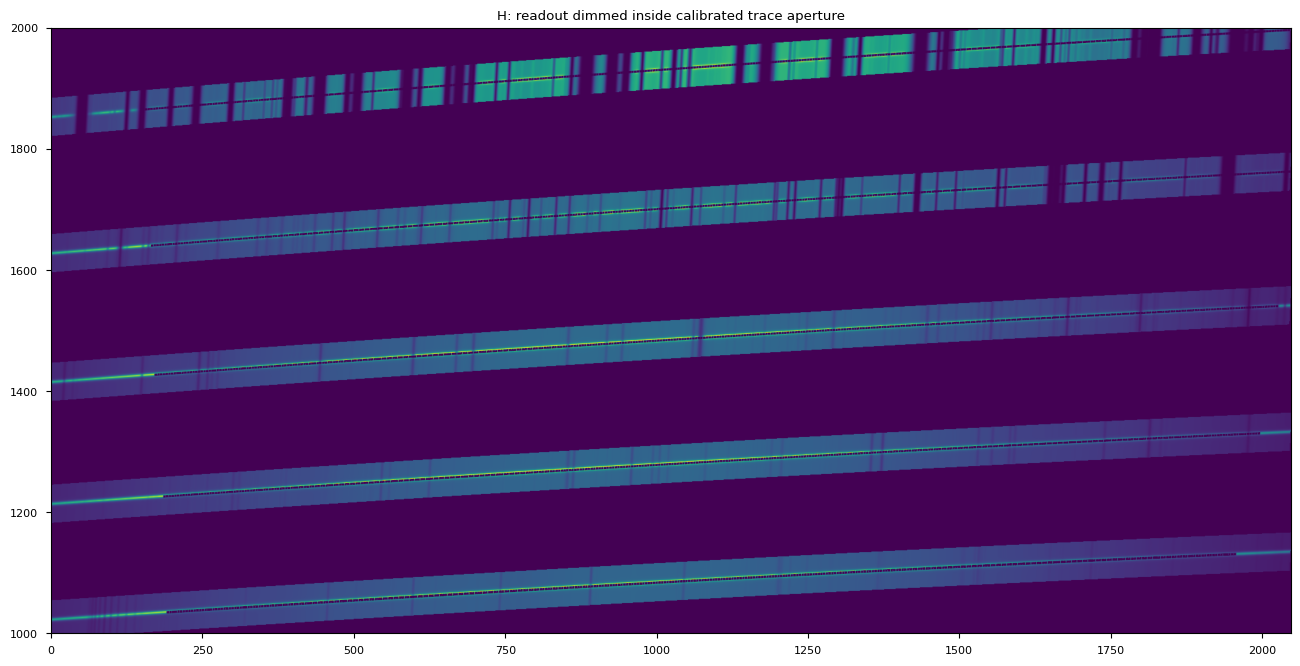

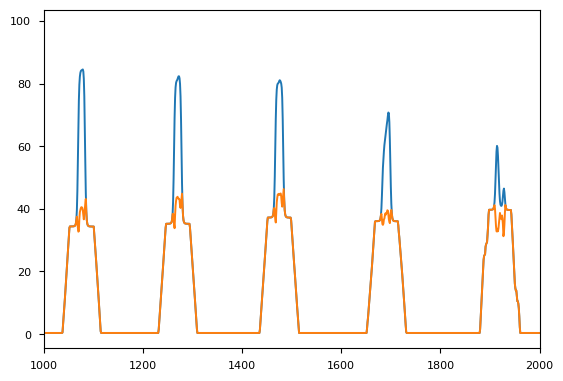

In [104]:
ch = "H"
i = readout_titles.index(ch)

image = readout_image(readouts["source_no_sky_lines"][i])
mask = zero_point_channel_weight_maps[ch]

plt.figure(figsize=(16, 16))
plt.imshow(image-  image * mask, origin="lower", vmin=np.nanpercentile(image, 1), vmax=np.nanpercentile(image, 99))
plt.title(f"{ch}: readout dimmed inside calibrated trace aperture")
plt.ylim(1000,2000)
plt.show()
plt.plot((image)[:,750:1000].mean(1))
plt.plot((image-  image * mask)[:,750:1000].mean(1))
plt.xlim(1000,2000)
plt.show()

## Smallest-Slit AO Comparison

This comparison keeps the same one-hour observing pair and the same background-subtraction convention as the main zero-point estimate. The current-slit no-AO case is replotted as the operational baseline. The narrow-slit cases show what changes when the slit is reduced to `0.33"`, first without AO and then with AO.

The AO plot uses six curves on one wavelength axis: current slit/no AO/native resolving power, current slit/no AO binned to `R=1000`, `0.33"` no AO/native resolving power, `0.33"` AO/native resolving power, `0.33"` AO binned to the current-slit resolving power, and `0.33"` AO binned to `R=1000`. Curves are display-smoothed to keep atmospheric absorption structure from dominating the visual impression, but best-per-order markers are selected from the unsmoothed samples.


In [ ]:
def make_science_case_cmd(*, slit_arcsec=0.33):
    case_cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
    case_cmd["!OBS.airmass"] = cmd_value("!OBS.airmass")
    case_cmd["!OBS.seeing"] = cmd_value("!OBS.seeing")
    case_cmd["!OBS.brightness"] = cmd_value("!OBS.brightness")
    case_cmd["!OBS.pupil_angle"] = cmd_value("!OBS.pupil_angle")
    set_channel_exposure(case_cmd, dit=1800, ndit=2)
    case_cmd["!INST.vis_curr_slit"] = slit_arcsec
    case_cmd["!INST.nir_curr_slit"] = slit_arcsec
    case_cmd["!SIM.spectral.spectral_resolution"] = cmd_value("!SIM.spectral.spectral_resolution")
    case_cmd["!INST.include_diffuse_emmisivity"] = cmd_value("!INST.include_diffuse_emmisivity")
    warning_prevent_sync_alt_ra_dec(case_cmd)
    return case_cmd


def psf_fwhm_arcsec(values):
    quantity = u.Quantity(values)
    if quantity.unit == u.dimensionless_unscaled:
        return quantity.value * u.arcsec
    return quantity.to(u.arcsec)


def set_train_ao_state(train, enabled):
    psf = get_effect(train, "seeing_psf", active_only=False)
    psf.meta["enable_ao"] = bool(enabled)
    if enabled:
        if bool(psf.meta.get("is_absolute", True)):
            psf.fwhm = lambda wavelengths, ao_scale=psf.ao_scale: psf_fwhm_arcsec(ao_scale(wavelengths))
        else:
            natural_fwhm = psf.get_fwhm_interp()
            psf.fwhm = lambda wavelengths, natural_fwhm=natural_fwhm, ao_scale=psf.ao_scale: (natural_fwhm(wavelengths) * ao_scale(wavelengths)).to(u.arcsec)
    else:
        natural_fwhm = psf.get_fwhm_interp()
        psf.fwhm = lambda wavelengths, natural_fwhm=natural_fwhm: psf_fwhm_arcsec(natural_fwhm(wavelengths))
    return psf


def observe_train_readout(train, source=None, *, disabled_background=None, disabled_effects=READOUT_RANDOM_NOISE_EFFECTS):
    return observe_readout(
        source,
        disabled_background,
        train=train,
        disabled_effects=disabled_effects,
    )


narrow_slit_arcsec = 0.33
narrow_background_cmd = make_science_case_cmd(slit_arcsec=narrow_slit_arcsec)
narrow_background_train = sim.OpticalTrain(narrow_background_cmd)
narrow_detector_budget = detector_background_budget_table(narrow_background_train)
narrow_background_hdul = observe_train_readout(narrow_background_train, None, disabled_background=["sky_lines"])


def run_zero_point_science_case(label, *, slit_arcsec, ao_enabled, background_hdul, detector_table, modes):
    case_cmd = make_science_case_cmd(slit_arcsec=slit_arcsec)
    train = sim.OpticalTrain(case_cmd)
    set_train_ao_state(train, ao_enabled)
    trace_res = trace_resolution_diagnostic_table(train)
    trace_summary = trace_resolution_summary_table(trace_res)
    source_hdul = observe_train_readout(
        train,
        source_to_observe,
        disabled_background=["sky_lines"],
    )
    _signals, _background, case_snr_images = snr_images_from_readouts(source_hdul, background_hdul, detector_table, readout_titles)
    by_order = trace_peak_resel_snr_by_order(zs, trace_res, case_snr_images, readout_titles)
    summary, display_rows = trace_peak_resel_snr_summary(by_order, readout_titles)
    psf_by_channel = {str(row["channel"]): float(row["seeing_fwhm_median_arcsec"]) for row in trace_summary}
    summary["case"] = label
    summary["psf_fwhm_arcsec"] = [psf_by_channel.get(str(channel), np.nan) for channel in summary["channel"]]
    for row in display_rows:
        row["case"] = label
        row["psf_fwhm_arcsec"] = psf_by_channel.get(str(row["channel"]), np.nan)
    zp_samples, trace_apertures = trace_zero_point_samples_table(
        train,
        source_hdul,
        background_hdul,
        detector_table,
        trace_res,
        readout_titles,
        input_abmag=zero_point_input_abmag,
        case_label=label,
        modes=modes,
        reference_trace_samples=trace_resolution,
        return_apertures=True,
    )
    zp_complete = zp_samples[zp_samples["native_count"] == zp_samples["bin_factor"]]
    return {
        "label": label,
        "train": train,
        "trace_summary": trace_summary,
        "snr": summary,
        "snr_display": display_rows,
        "snr_by_order": by_order,
        "zero_point_samples_raw": zp_samples,
        "zero_point_samples_complete": zp_complete,
        "trace_apertures": trace_apertures,
        "trace_aperture_table": trace_aperture_calibration_table(trace_apertures),
        "zero_point_order_best": best_zero_point_order_table(zp_complete),
    }


narrow_no_ao_label = f'{narrow_slit_arcsec:.2f}" slit, no AO'
narrow_ao_label = f'{narrow_slit_arcsec:.2f}" slit, AO'
ao_cases = [
    run_zero_point_science_case(
        narrow_no_ao_label,
        slit_arcsec=narrow_slit_arcsec,
        ao_enabled=False,
        background_hdul=narrow_background_hdul,
        detector_table=narrow_detector_budget,
        modes=("native",),
    ),
    run_zero_point_science_case(
        narrow_ao_label,
        slit_arcsec=narrow_slit_arcsec,
        ao_enabled=True,
        background_hdul=narrow_background_hdul,
        detector_table=narrow_detector_budget,
        modes=("native", "current_slit_R", "R1000"),
    ),
]

ao_snr_rows = [row for case in ao_cases for row in case["snr_display"]]
display_frame(ao_snr_rows, columns=["case", "channel", "psf_fwhm_arcsec", "orders", "wave [nm]", "pix S/N", "S/N", "p90 pix S/N", "eff pix"], formats={"psf_fwhm_arcsec": "{:.3f}"})
ao_aperture_summary = []
for case in ao_cases:
    for row in trace_aperture_quality_summary(case["trace_apertures"], readout_titles):
        ao_aperture_summary.append({"case": case["label"], **row})
display_frame(ao_aperture_summary,  formats={"center_scatter_max": "{:.3f}", "width_penalty_max": "{:.3f}"})

current_no_ao_rows = zero_point_samples_complete[
    (np.asarray(zero_point_samples_complete["case"], dtype=str) == zero_point_case_label)
    & np.isin(np.asarray(zero_point_samples_complete["mode"], dtype=str), ["native", "R1000"])
]
ao_zero_point_samples_complete = Table(rows=[
    *[row for row in current_no_ao_rows],
    *[row for case in ao_cases for row in case["zero_point_samples_complete"]],
])
ao_zero_point_samples_smooth = smoothed_zero_point_samples_for_plot(ao_zero_point_samples_complete)
ao_zero_point_order_best = best_zero_point_order_table(ao_zero_point_samples_complete)
ao_zero_point_summary_display = zero_point_summary_display_table(ao_zero_point_order_best, readout_titles)
print(f"AO trace-following zero-point estimate from m_AB={zero_point_input_abmag:.1f}; target S/N={ZERO_POINT_TARGET_SNR:.1f}")
display_frame(
    ao_zero_point_summary_display,
    formats={"R med": "{:.0f}", "med_S/N": "{:.1f}", "med_mAB5": "{:.1f}"},
)

ao_style_order = [
    (zero_point_case_label, "native"),
    (zero_point_case_label, "R1000"),
    (narrow_no_ao_label, "native"),
    (narrow_ao_label, "native"),
    (narrow_ao_label, "current_slit_R"),
    (narrow_ao_label, "R1000"),
]
default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ao_style_map = {
    (zero_point_case_label, "native"): {"color": default_cycle[0], "linestyle": "-", "linewidth": 1.35, "alpha": 0.95},
    (zero_point_case_label, "R1000"): {"color": default_cycle[1], "linestyle": ":", "linewidth": 1.05, "alpha": 0.95},
    (narrow_no_ao_label, "native"): {"color": default_cycle[2], "linestyle": "-", "linewidth": 1.15, "alpha": 0.90},
    (narrow_ao_label, "native"): {"color": default_cycle[3], "linestyle": "-", "linewidth": 1.35, "alpha": 0.95},
    (narrow_ao_label, "current_slit_R"): {"color": default_cycle[4], "linestyle": "--", "linewidth": 1.0, "alpha": 0.95},
    (narrow_ao_label, "R1000"): {"color": default_cycle[5], "linestyle": ":", "linewidth": 1.0, "alpha": 0.95},
}
fig, ax = plot_zero_point_curves(
    ao_zero_point_samples_smooth,
    ao_zero_point_order_best,
    style_order=ao_style_order,
    style_map=ao_style_map,
    titles=readout_titles,
    title="AO and slit zero-point comparison",
)
display(fig)
plt.close(fig)


In [108]:
def trace_aperture_pixel_summary(apertures, titles=None):
    table = trace_aperture_calibration_table(apertures)
    if len(table) == 0:
        return []
    frame = table.to_pandas()
    scale = frame["xi_pixel_arcsec"].astype(float)

    frame["xi_center_pix"] = frame["xi_center_arcsec"].astype(float) / scale
    frame["spatial_width_pix"] = frame["spatial_width_arcsec"].astype(float) / scale
    frame["center_scatter_pix"] = frame["center_scatter_arcsec"].astype(float) / scale
    frame["width_min_pix"] = frame["width_min_arcsec"].astype(float) / scale
    frame["width_max_pix"] = frame["width_max_arcsec"].astype(float) / scale
    frame["slit_edge_limit_pix"] = frame["width_edge_limit_arcsec"].astype(float) / scale

    channels = list(titles) if titles is not None else list(dict.fromkeys(frame["channel"]))
    rows = []
    for channel in channels:
        group = frame[frame["channel"] == channel]
        if len(group) == 0:
            continue
        rows.append({
            "ch": channel,
            "traces": len(group),
            "xi pix scale [as/pix]": compact_range(group["xi_pixel_arcsec"].min(), group["xi_pixel_arcsec"].max(), 4),
            "center [pix]": compact_range(group["xi_center_pix"].min(), group["xi_center_pix"].max(), 1),
            "width [pix]": compact_range(group["spatial_width_pix"].min(), group["spatial_width_pix"].max(), 1),
            "width limits [pix]": f"{compact_range(group['width_min_pix'].min(), group['width_min_pix'].max(), 1)} / {compact_range(group['width_max_pix'].min(), group['width_max_pix'].max(), 1)}",
            "center scatter max [pix]": float(np.nanmax(group["center_scatter_pix"])),
            "warnings": int(sum((group["center_status"].astype(str) + group["width_status"].astype(str)).str.replace("ok", "", regex=False).str.strip().ne(""))),
        })
    return rows


ao_aperture_summary_pix = []
for case in ao_cases:
    for row in trace_aperture_pixel_summary(case["trace_apertures"], readout_titles):
        ao_aperture_summary_pix.append({"case": case["label"], **row})

display_frame(
    ao_aperture_summary_pix,
    formats={"center scatter max [pix]": "{:.2f}"},
)

case,ch,traces,xi pix scale [as/pix],center [pix],width [pix],width limits [pix],center scatter max [pix],warnings
"0.33"" slit, no AO",B,34,0.1571,-1.2,5.1-7.2,4.5-4.8 / 18.1-19.3,0.00,0
"0.33"" slit, no AO",G,30,0.1571,-1.1,4.2-5.7,4.2-4.5 / 16.6-18.1,0.00,0
"0.33"" slit, no AO",R,20,0.1571,-1.5--1.0,3.9-4.8,3.8-4.2 / 15.3-16.6,0.38,1
"0.33"" slit, no AO",YJ,24,0.1571,-1.5--1.0,3.6-7.7,3.6-3.9 / 14.4-15.4,0.36,1
"0.33"" slit, no AO",H,11,0.1571,-1.5--1.0,3.8-4.7,3.4-3.5 / 13.5-14.1,0.37,0
"0.33"" slit, no AO",K,8,0.1571,-1.5--1.0,3.2-6.4,3.2-3.3 / 12.8-13.3,0.37,2
"0.33"" slit, AO",B,34,0.1571,-1.5--1.0,2.7-4.3,2.3-2.7 / 9.3-10.7,0.00,0
"0.33"" slit, AO",G,30,0.1571,-1.0,2.5-3.8,2.0-2.3 / 8.1-9.3,0.71,0
"0.33"" slit, AO",R,20,0.1571,-1.0,2.0-3.3,2.0 / 7.9-8.1,0.35,0
"0.33"" slit, AO",YJ,24,0.1571,-1.0,2.2-4.0,2.0 / 7.9,0.35,1


In [ ]:
def zero_point_pixel_count_summary(samples_table, *, titles=readout_titles, modes=("native", "current_slit_R", "R1000")):
    rows = []
    if len(samples_table) == 0:
        return rows
    case_values = np.asarray(samples_table["case"], dtype=str)
    channel_values = np.asarray(samples_table["channel"], dtype=str)
    mode_values = np.asarray(samples_table["mode"], dtype=str)

    for case in list(dict.fromkeys(case_values)):
        for channel in titles:
            for mode in modes:
                mask = (
                    (case_values == case)
                    & (channel_values == channel)
                    & (mode_values == mode)
                )
                if not np.any(mask):
                    continue

                group = samples_table[mask]
                n_pix = np.asarray(group["n_pix"], dtype=float)
                weighted_pixels = np.asarray(group["weighted_pixels"], dtype=float)
                variance_pixels = np.asarray(group["variance_pixels"], dtype=float)
                raster_nm = np.asarray(group["wave_high_nm"] - group["wave_low_nm"], dtype=float)
                spat_arcsec = np.asarray(group["spatial_width_arcsec"], dtype=float)

                rows.append({
                    "case": case,
                    "ch": channel,
                    "mode": ZERO_POINT_MODE_LABELS.get(mode, mode),
                    "N": len(group),
                    "pix/bin": f"{np.nanmin(n_pix):.0f}-{np.nanmax(n_pix):.0f}",
                    "med_pix/bin": float(np.nanmedian(n_pix)),
                    "weighted pix": float(np.nanmedian(weighted_pixels)),
                    "variance pix": float(np.nanmedian(variance_pixels)),
                    "raster nm": f"{np.nanmin(raster_nm):.4f}-{np.nanmax(raster_nm):.4f}",
                    "spatial arcsec": f"{np.nanmin(spat_arcsec):.3f}-{np.nanmax(spat_arcsec):.3f}",
                })
    return rows


display_frame(
    zero_point_pixel_count_summary(ao_zero_point_samples_complete),
    formats={
        "med_pix/bin": "{:.1f}",
        "weighted pix": "{:.2f}",
        "variance pix": "{:.2f}",
    },
)
